In [4]:
import pandas as pd
import numpy  as np
import tables as tb
from scipy.integrate import trapz
from scipy.optimize import curve_fit

In [5]:
import matplotlib        as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib notebook
%matplotlib inline
### Useful parameters for plots
mpl.rcParams["figure.figsize"]          = 12,10
mpl.rcParams["font.size"]               = 20
mpl.rcParams["figure.max_open_warning"] = 100
mpl.rcParams["font.size"]               = 20
mpl.rcParams["font.weight"]             ='normal'
mpl.rcParams["axes.labelweight"] = "normal"
mpl.rcParams['axes.facecolor'] = 'w'
mpl.rcParams['figure.facecolor'] = 'w';


[ 2  0 -3 ... -8  0  8]
[ 2  0 -3 ... -8  0  8]
/ (RootGroup) 'Test file'
/RD (Group) ''
/RD/pmtrwf (EArray(1000, 7, 5000)) ''
/Run (Group) ''
/Run/events (Table(1000,)) 'event info table'
/Run/runInfo (Table(1000,)) 'run info table'
len is : 5000


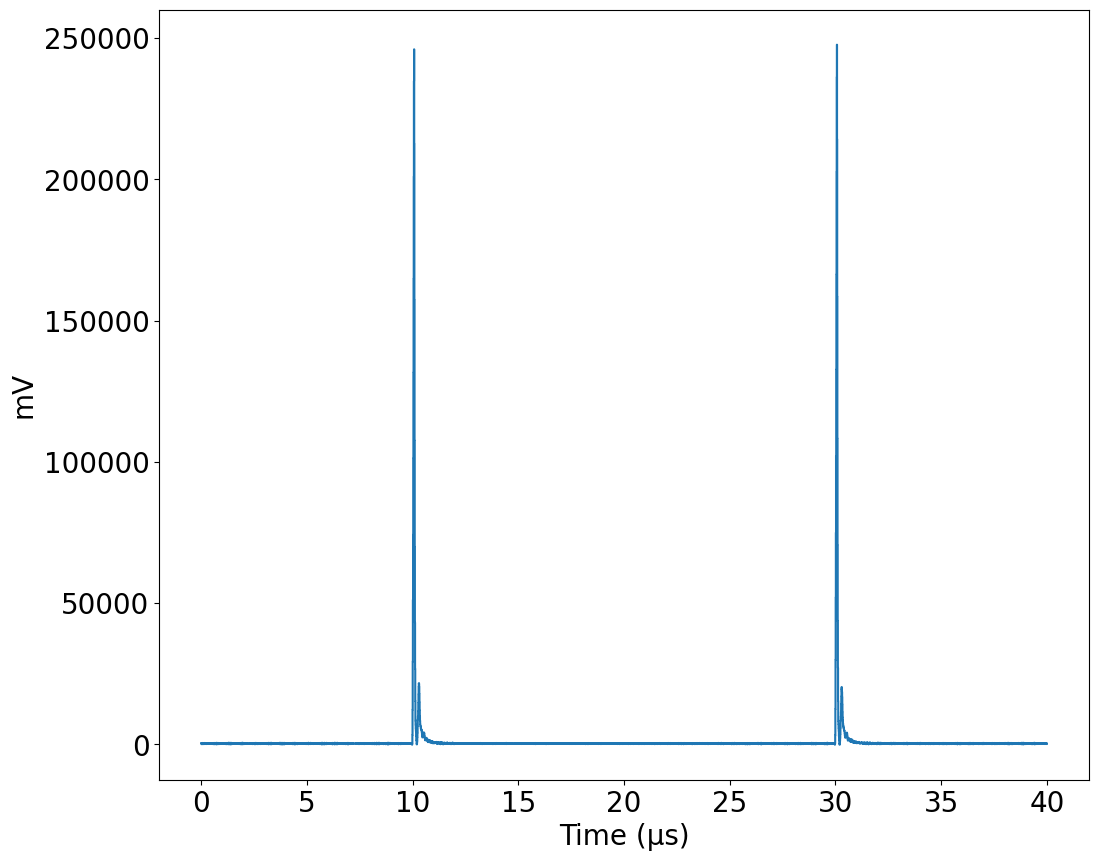

In [371]:
#to read 1 wf
wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R2987/raw/Run_2987_file_0_raw.h5'

with tb.open_file(wf_file, 'r') as h5in:
    wvfs       =  h5in.root.RD.pmtrwf[0, 0] # Gets all pmt waveforms for the second event in the file
    print(-wvfs)
    wvfs       =  h5in.root.RD.pmtrwf[:, 0, :] # Gets all pmt waveforms for 1 PMT
    pmt_rwf    = -wvfs[0]
    print(pmt_rwf)
    
    !ptdump $wf_file
    #!ptdump -vd $wf_file:/RD/pmtrwf
    pmt_rwf    = -wvfs.sum(axis=0)       # Sums and inverts the signal of all PMTs
    print('len is :', len(pmt_rwf))
    t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
    plt.xlabel('Time (µs)')
    plt.ylabel('mV')

In [380]:

with tb.open_file(wf_file, 'r') as h5in:
    wvfs =  h5in.root.RD.pmtrwf[:, 0, :]
    print(wvfs)
    print(wvfs.shape)
    
    pmt_rwf    = -wvfs.sum(axis=0)
    print('   ')
    print(pmt_rwf)
    print('len(pmt_rwf) is :', len(pmt_rwf))
    
    
    
    #!ptdump $wf_file
    #!ptdump -vd $wf_file:/RD/pmtrwf

[[-2  0  3 ...  8  0 -8]
 [-3  4  2 ...  2  0 -4]
 [-1  4  3 ... -5 -6  2]
 ...
 [-8  0  8 ...  6  4 -5]
 [-7  1  6 ...  0 -5 -2]
 [ 3 -2 -3 ...  6  2 -6]]
(1000, 5000)
   
[479 370  98 ... 289 144 315]
len(pmt_rwf) is : 5000


In [7]:
#create the folder of the date if not created in order to have all the next plots and data saved in an organized way

import os

date_folder = '27-01-2026' #put the date of the calibration in the format dd-mm-yyyy

os.makedirs('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/'+str(date_folder), exist_ok=True)
print('/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/'+str(date_folder))


/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026


5000
1248.74774954991 1266.890878175635


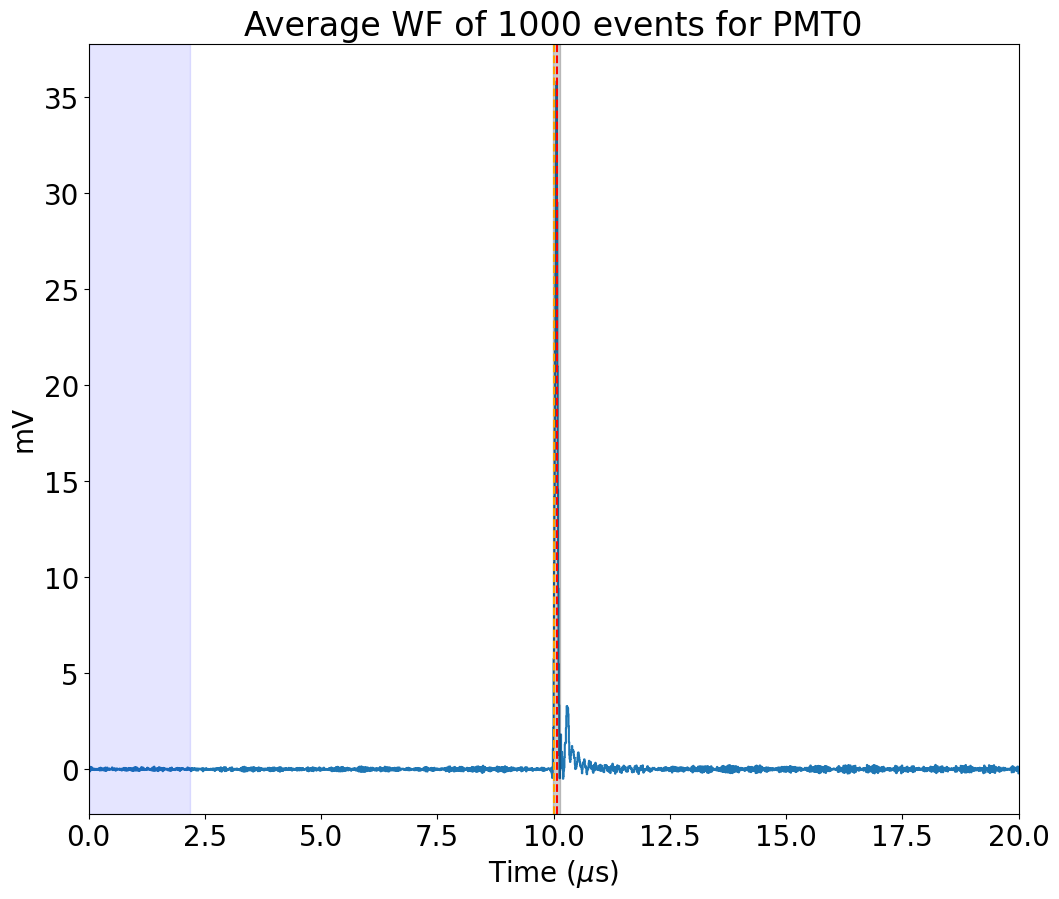

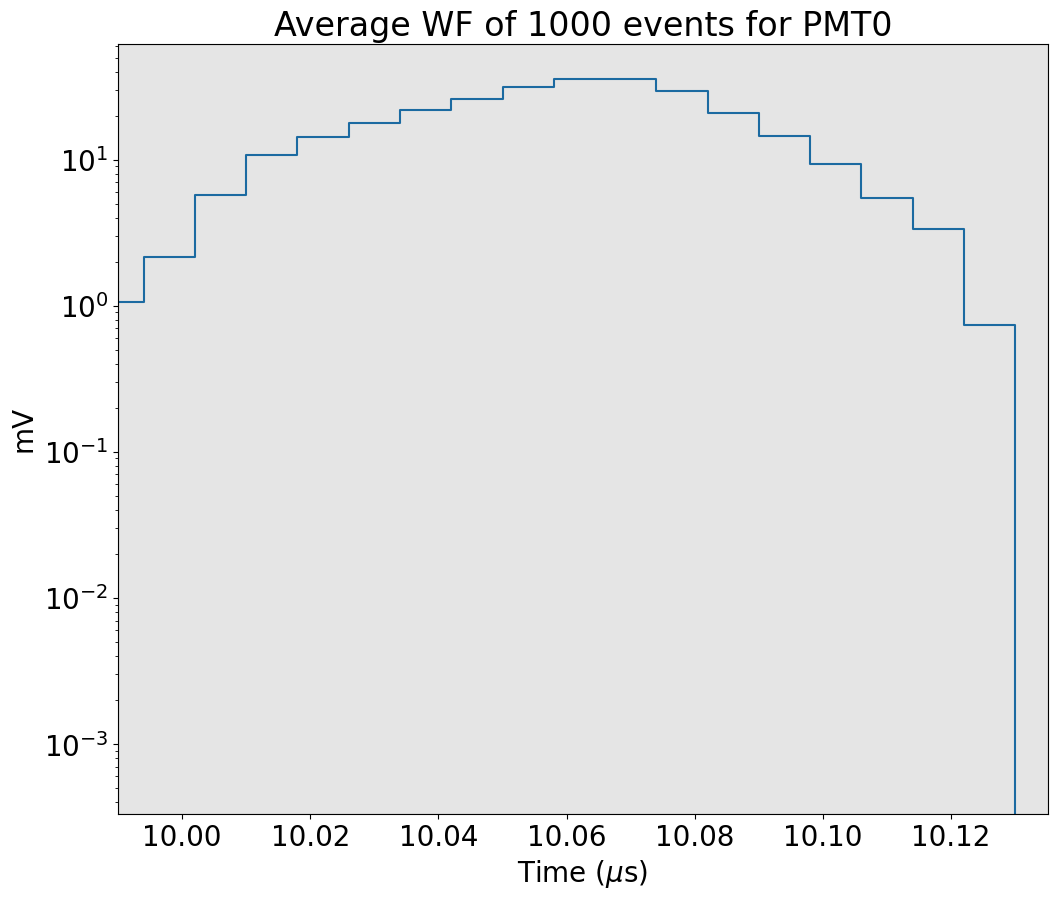

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 0
40 -1


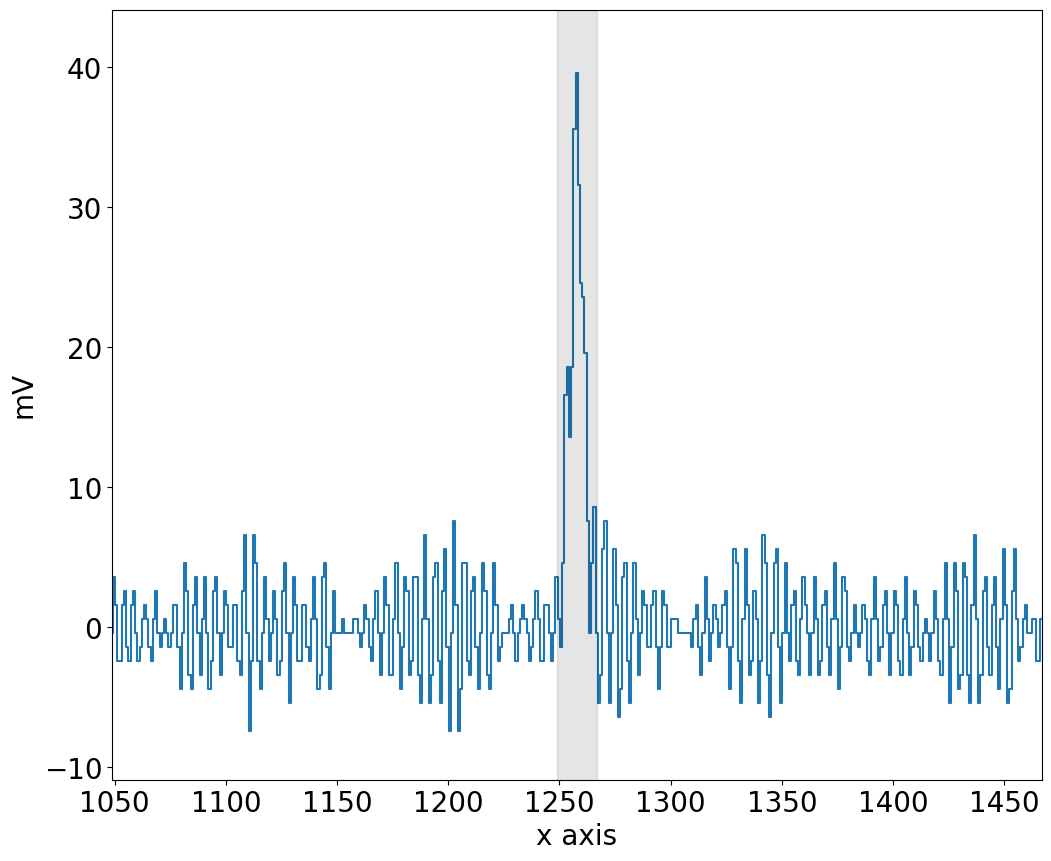

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 1
52 0


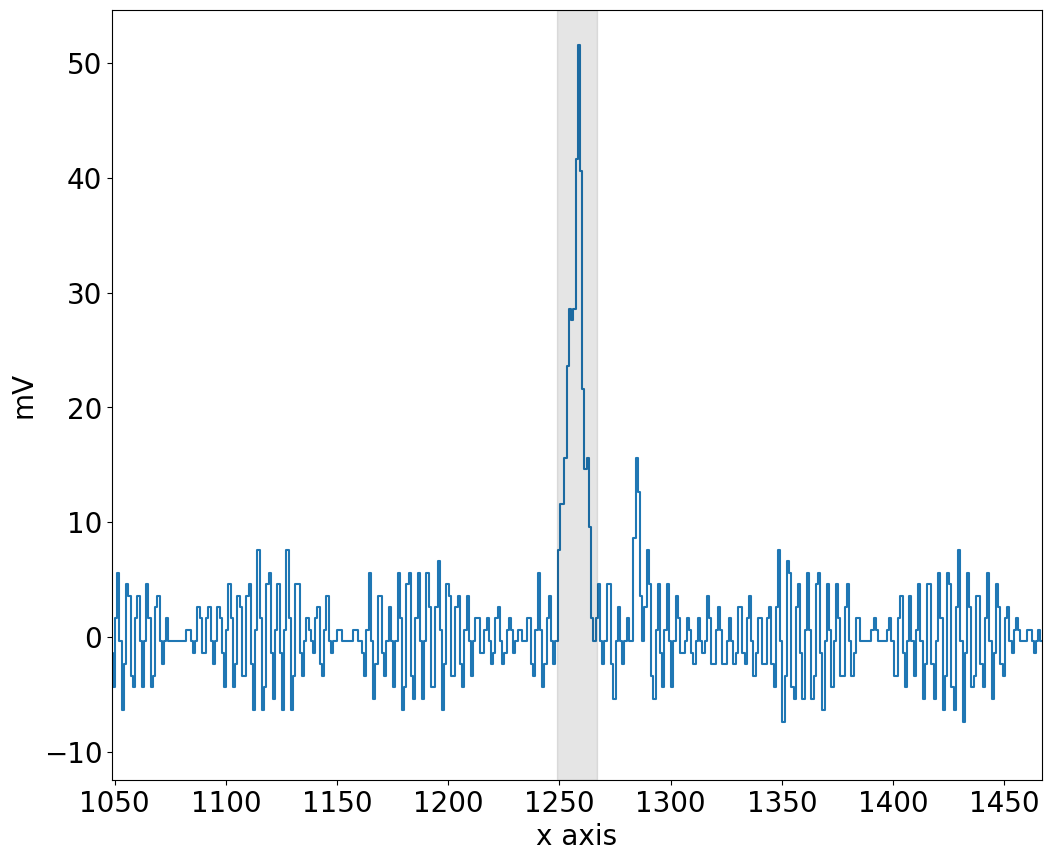

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 2
34 0


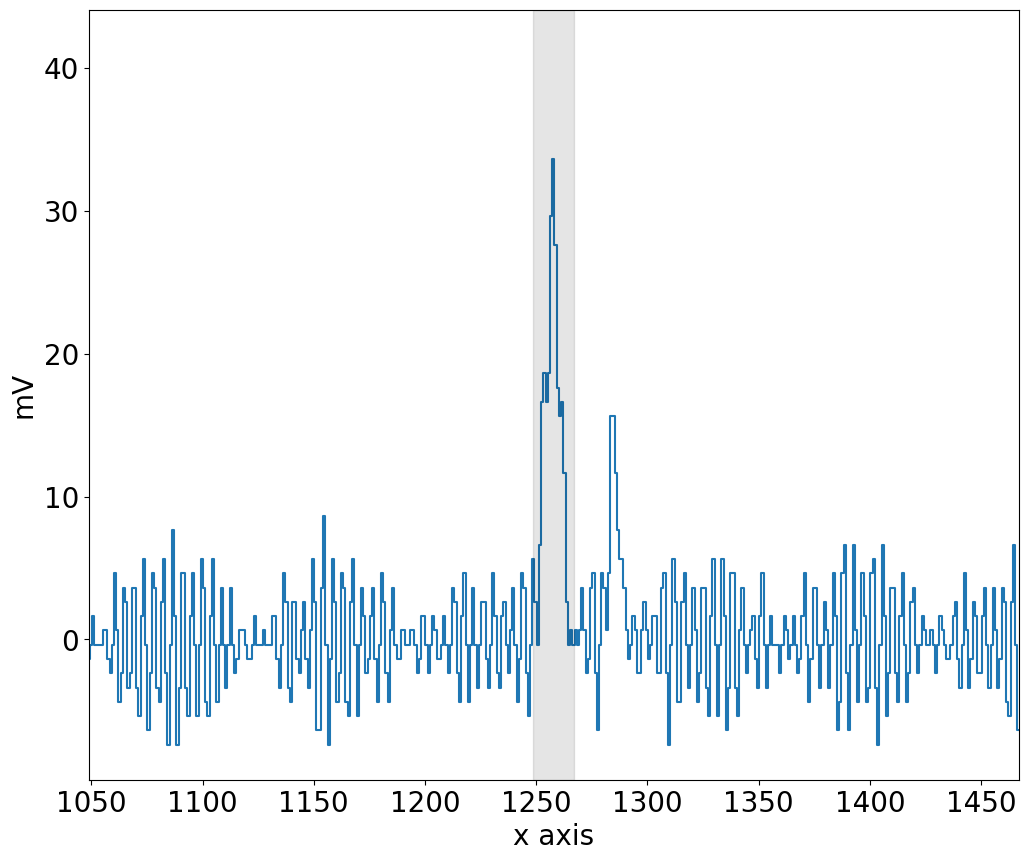

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 3
41 -3


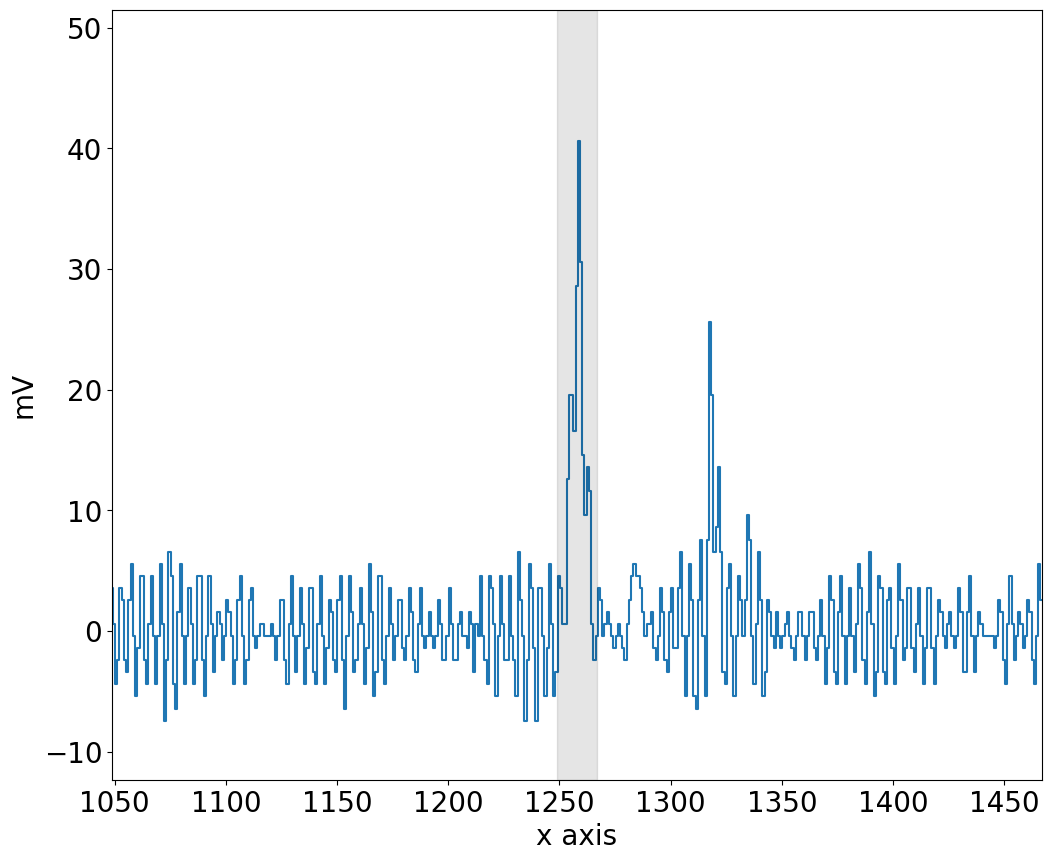

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 4
53 -3


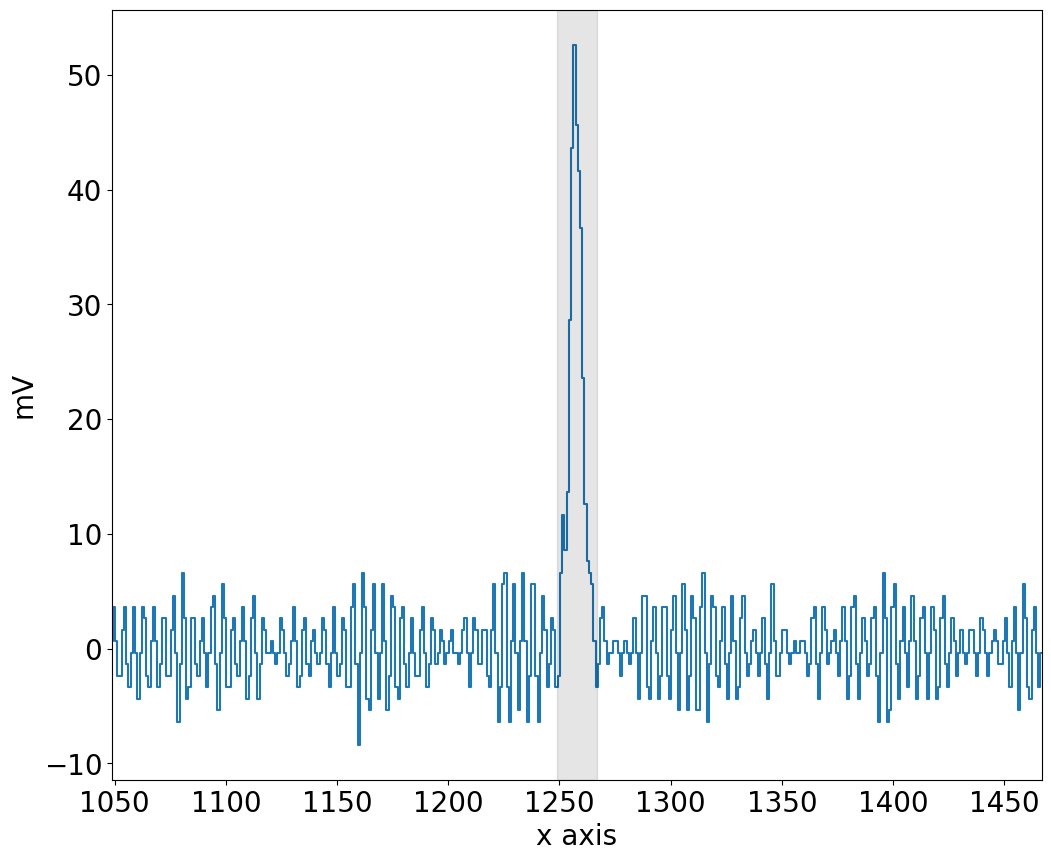

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 5
51 -3


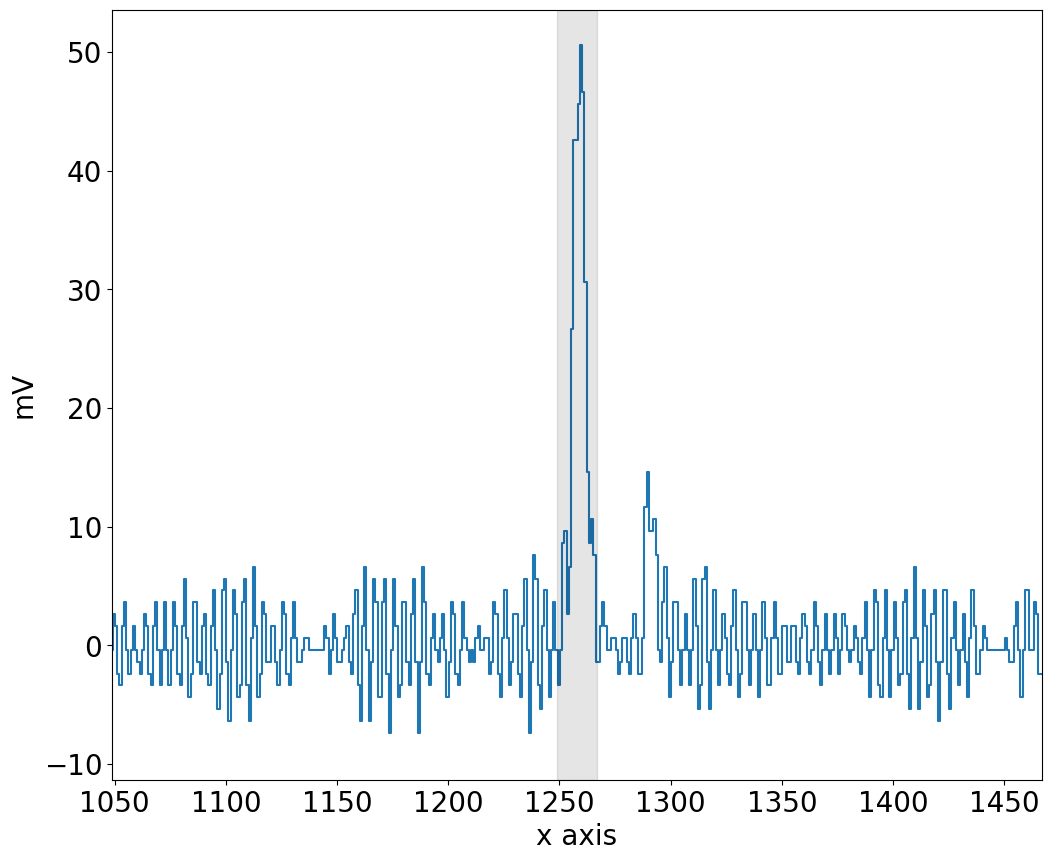

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 6
33 1


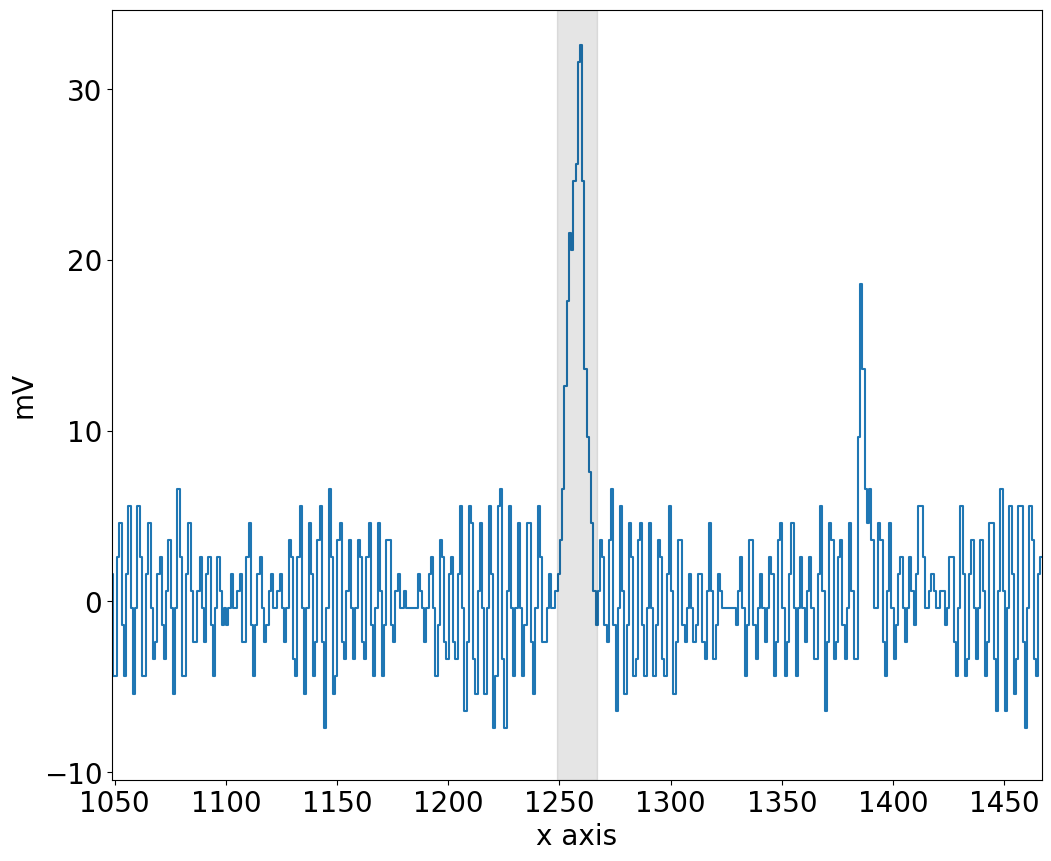

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 7
42 2


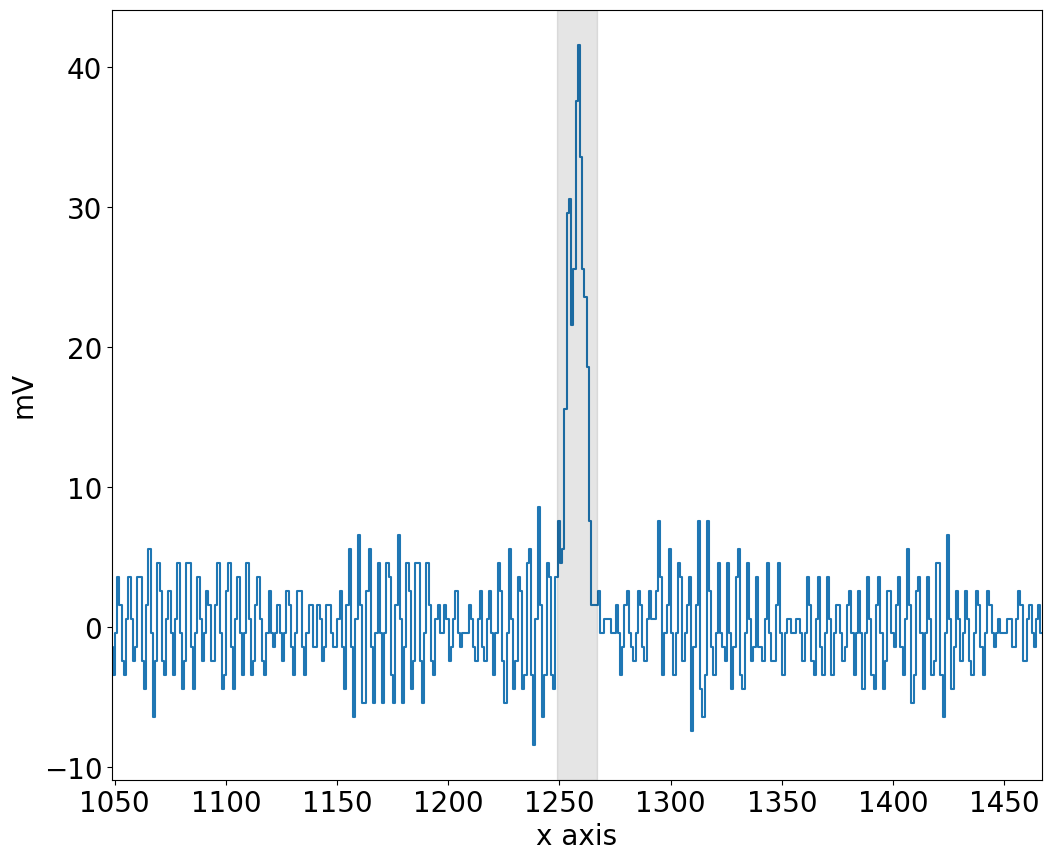

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 8
42 -2


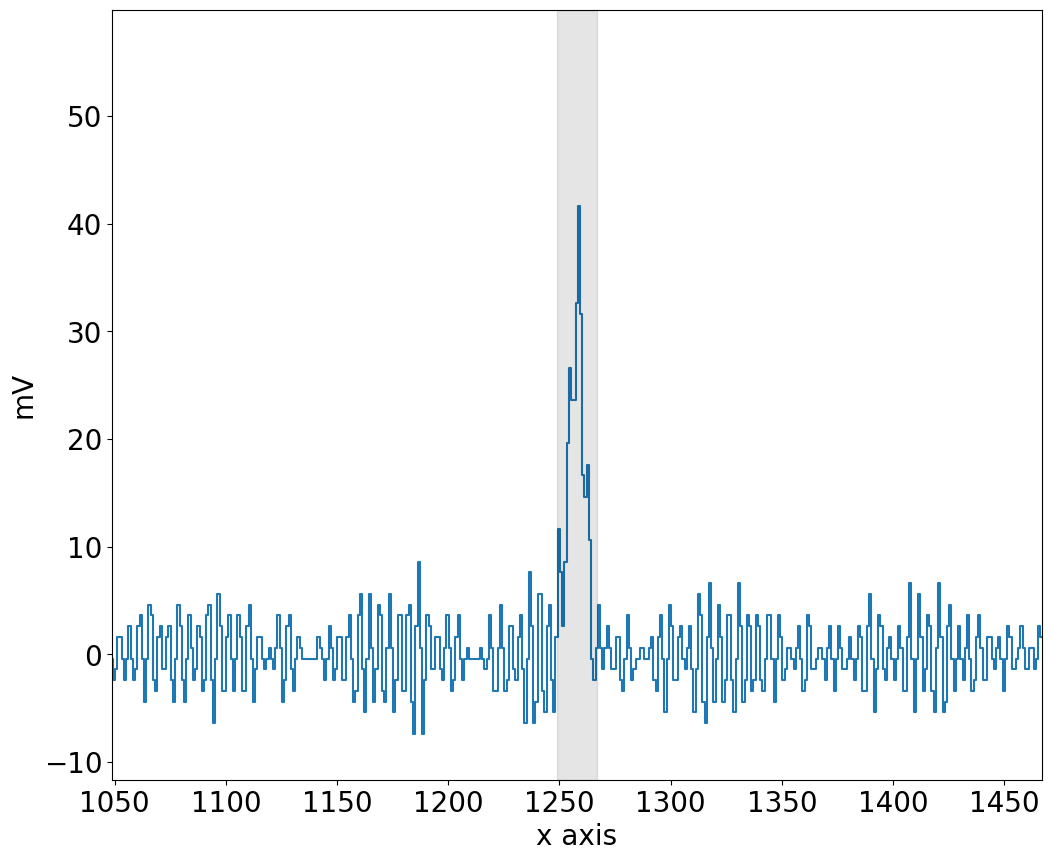

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 9
58 -3


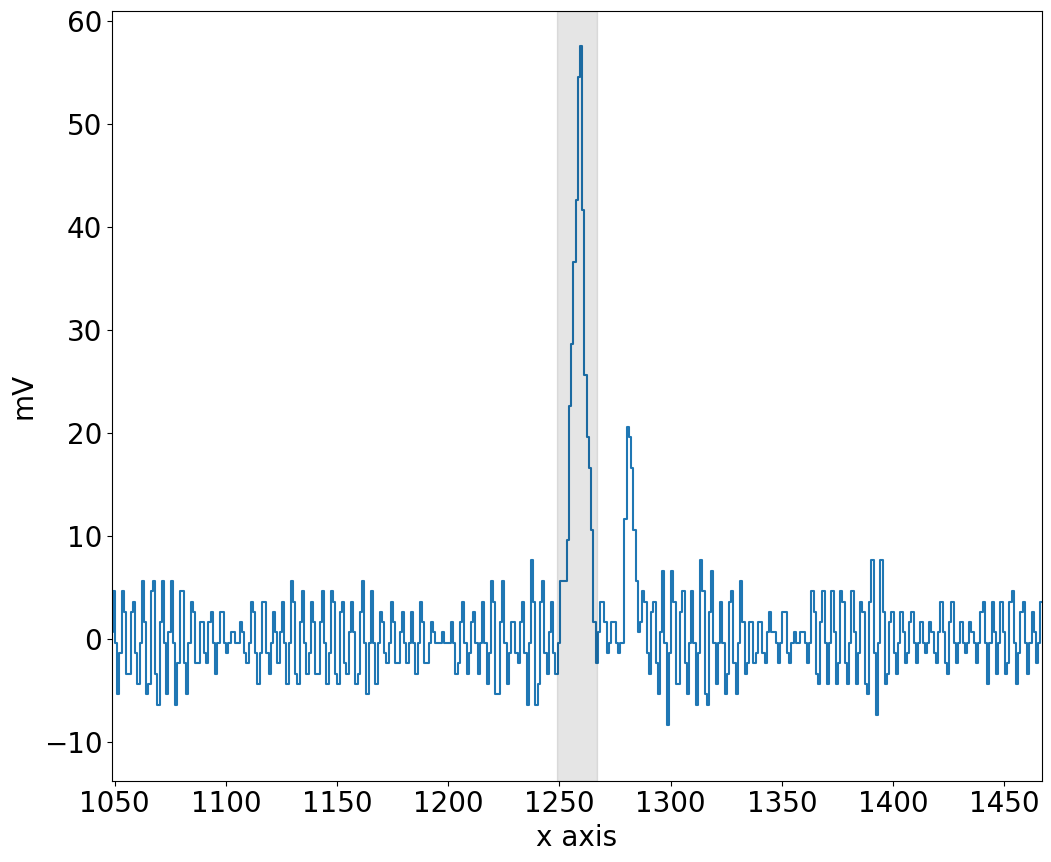

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 10
50 -1


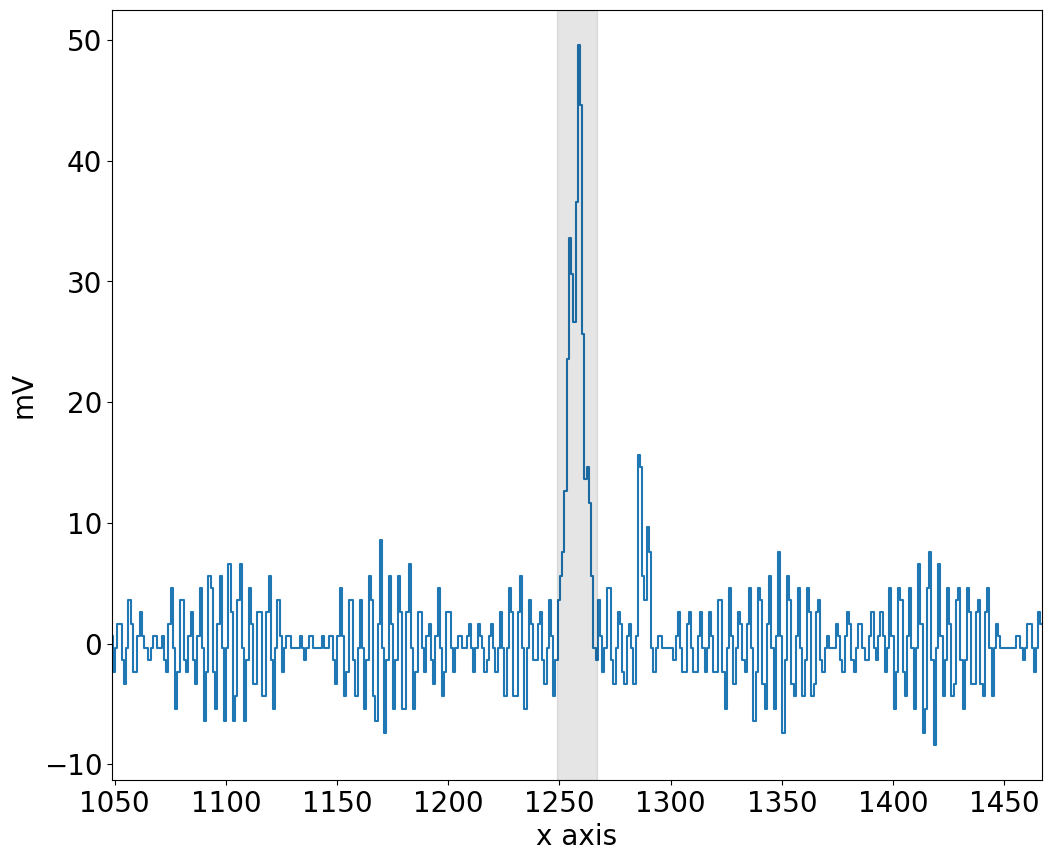

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 11
29 -3


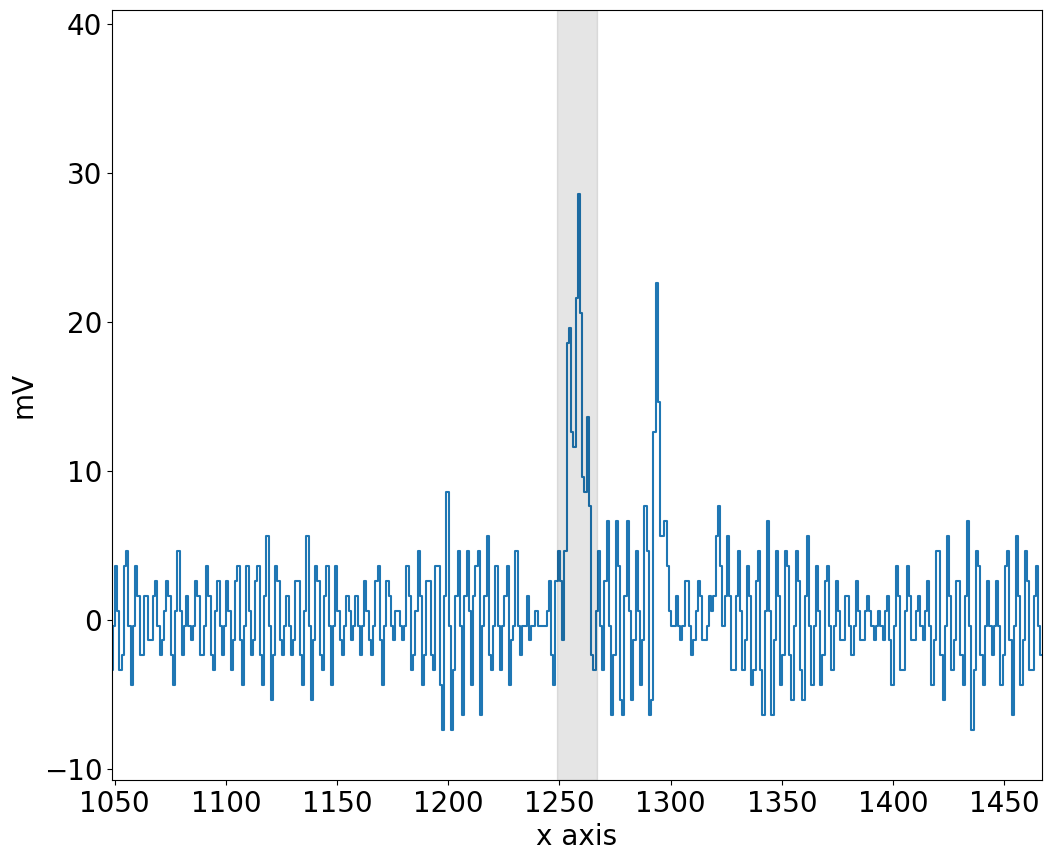

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 12
50 1


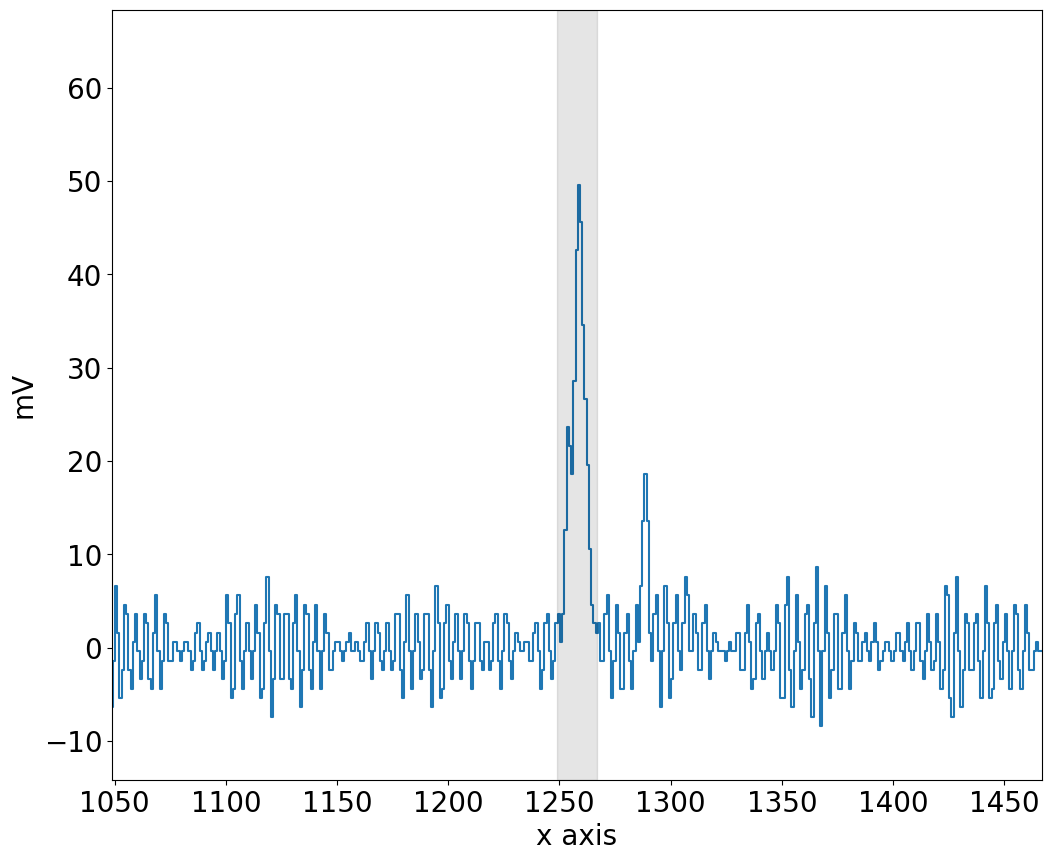

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 13
36 -3


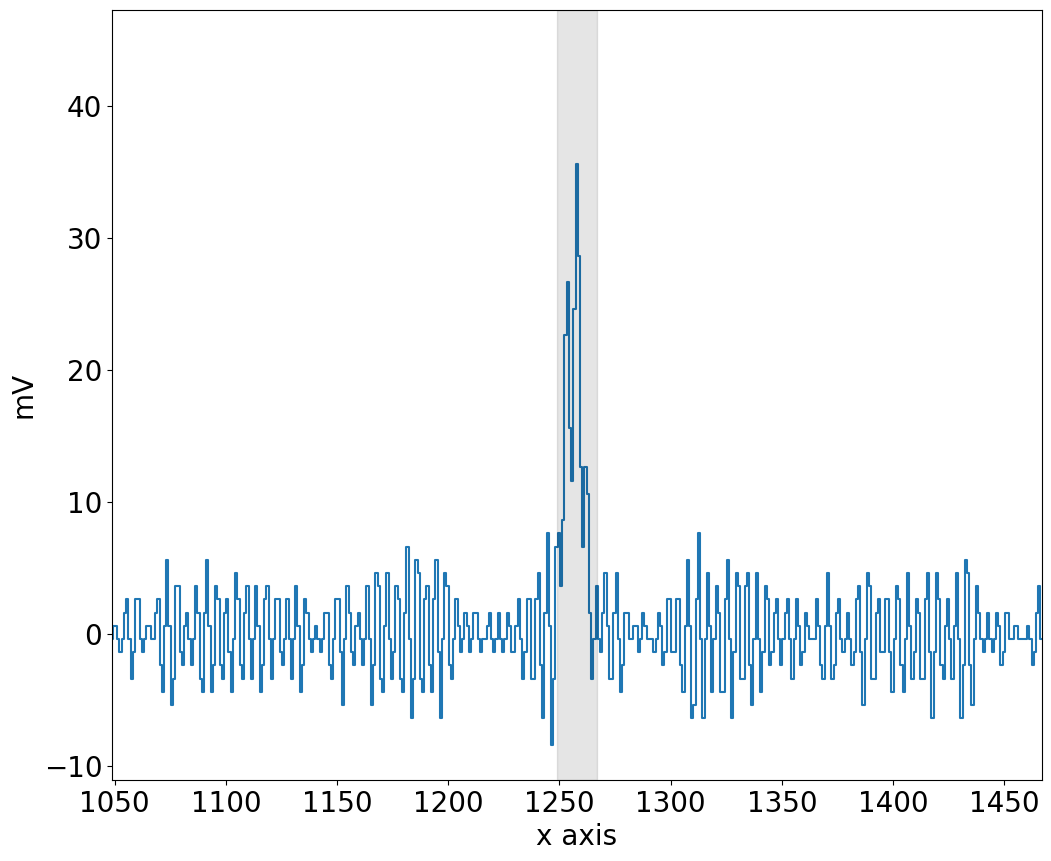

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 14
37 0


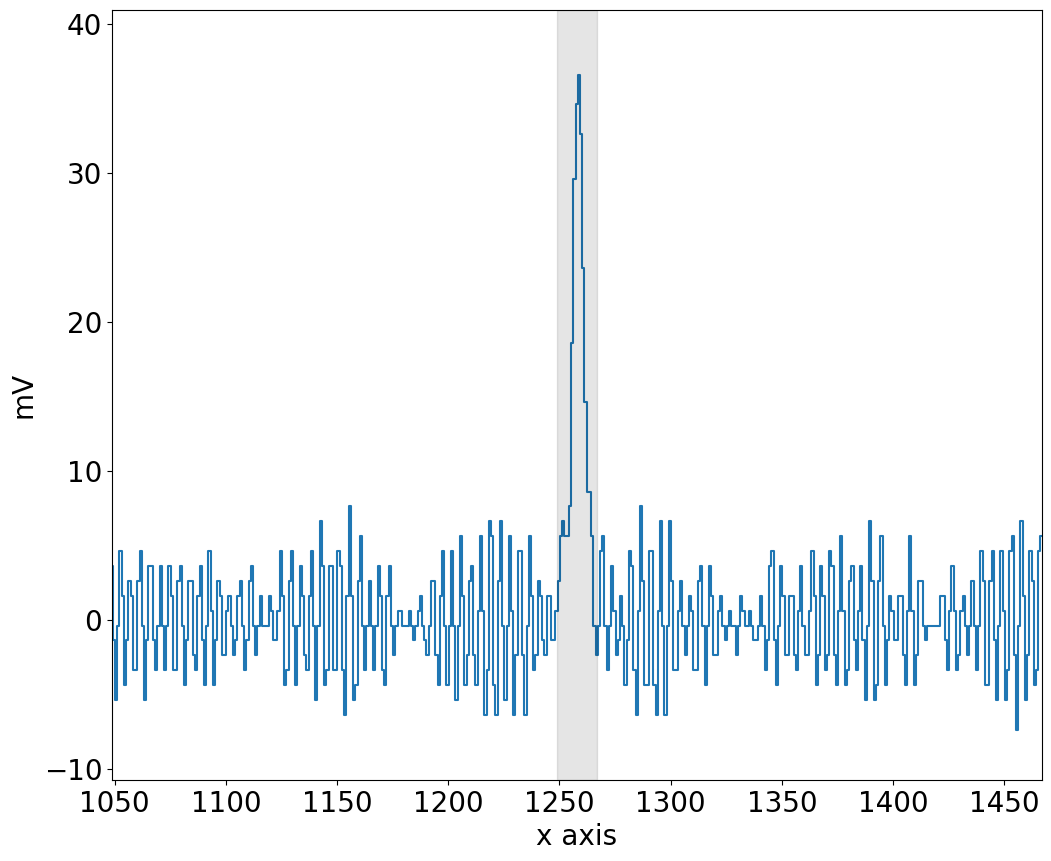

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 15
40 -1


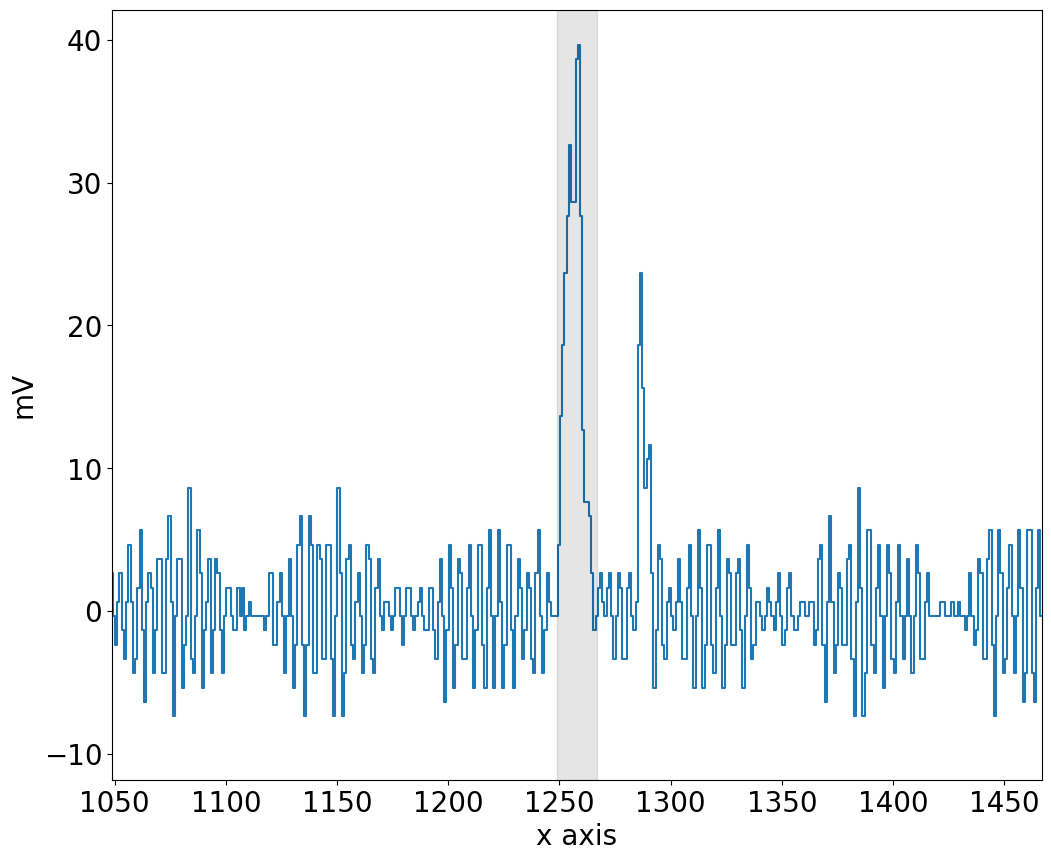

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 16
37 -1


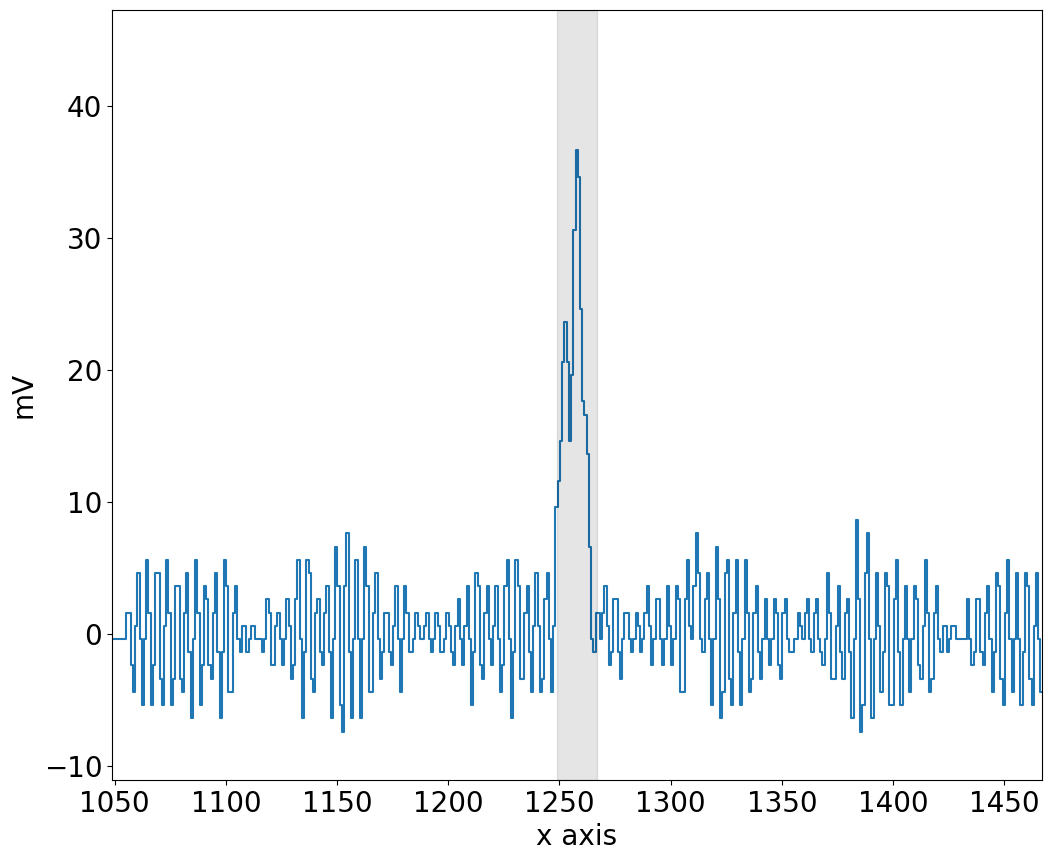

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 17
37 0


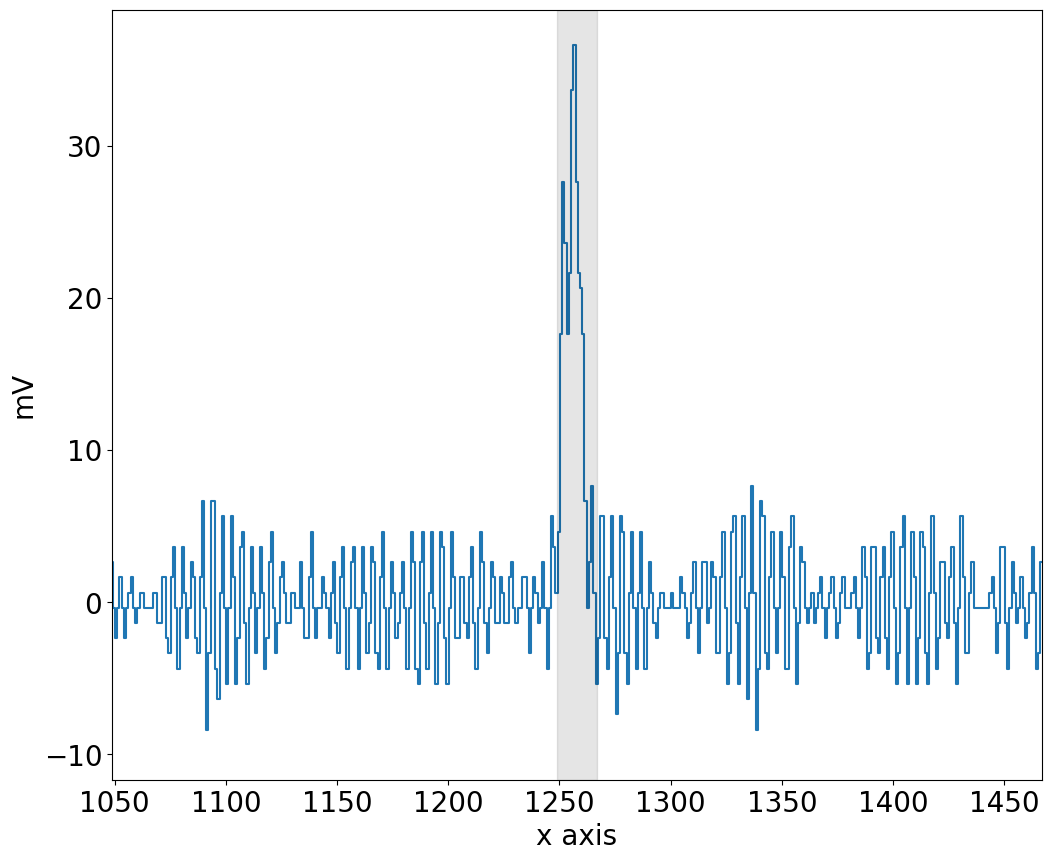

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 18
30 -5


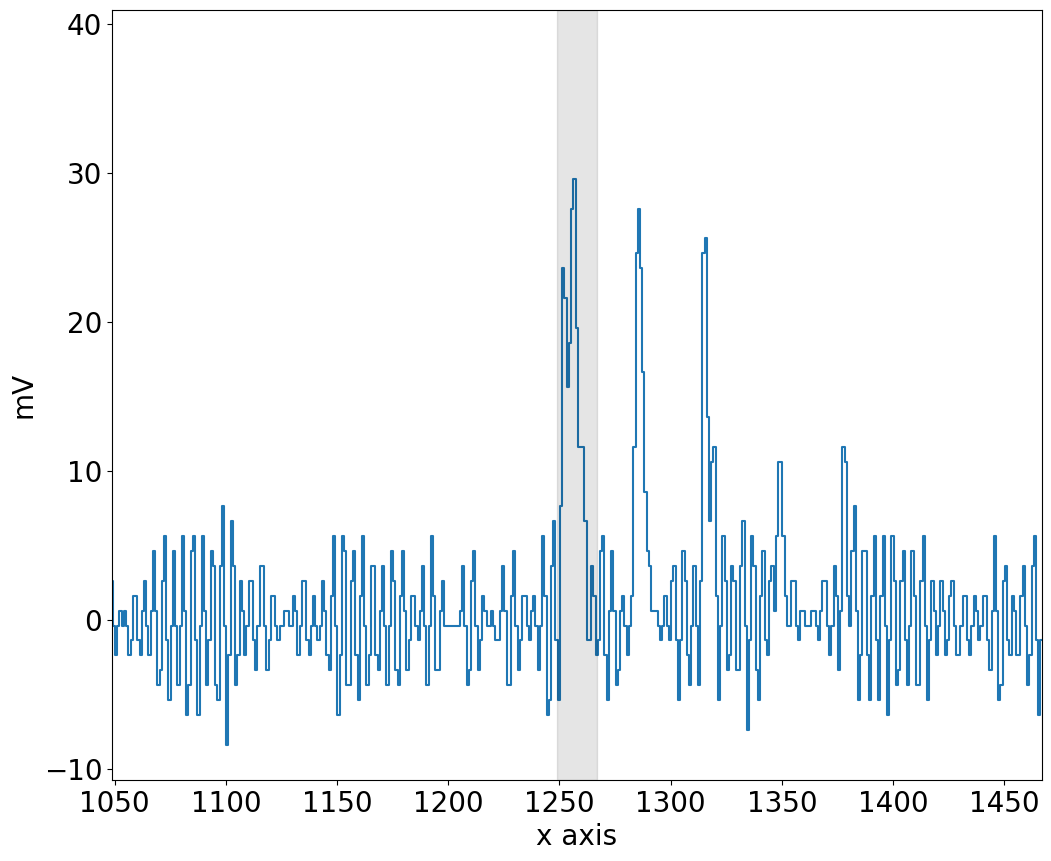

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 19
42 0


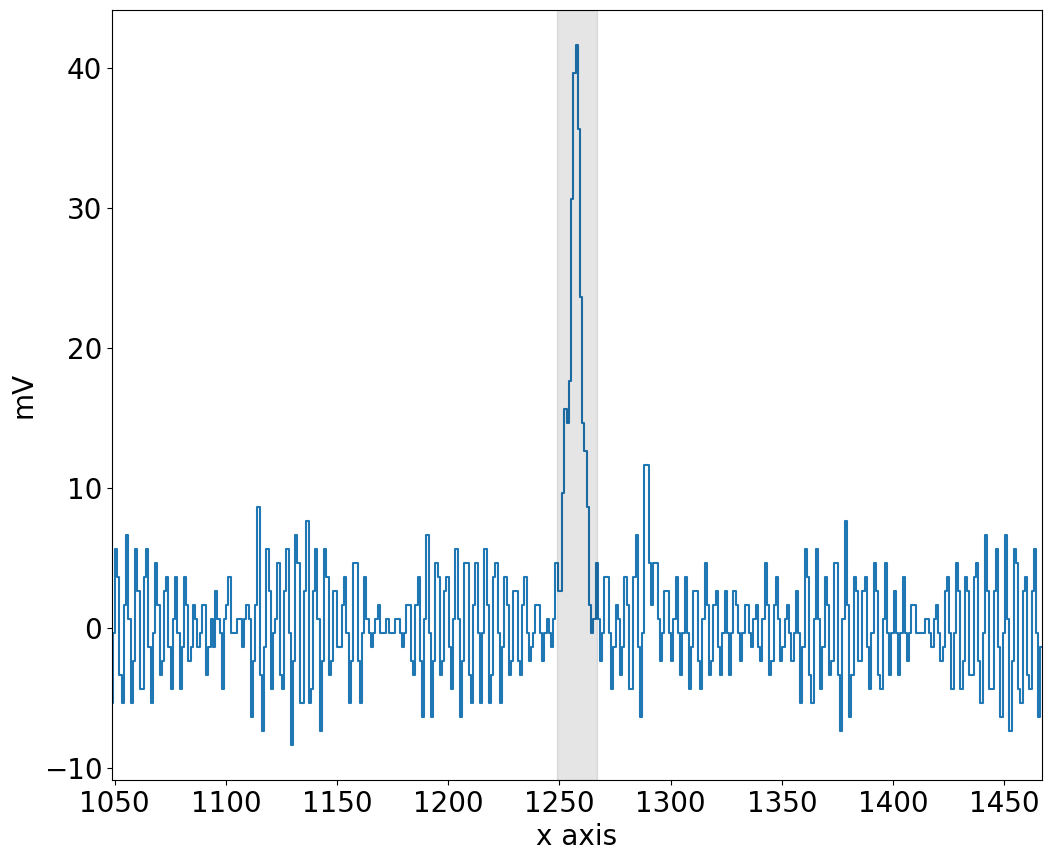

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 20
37 -3


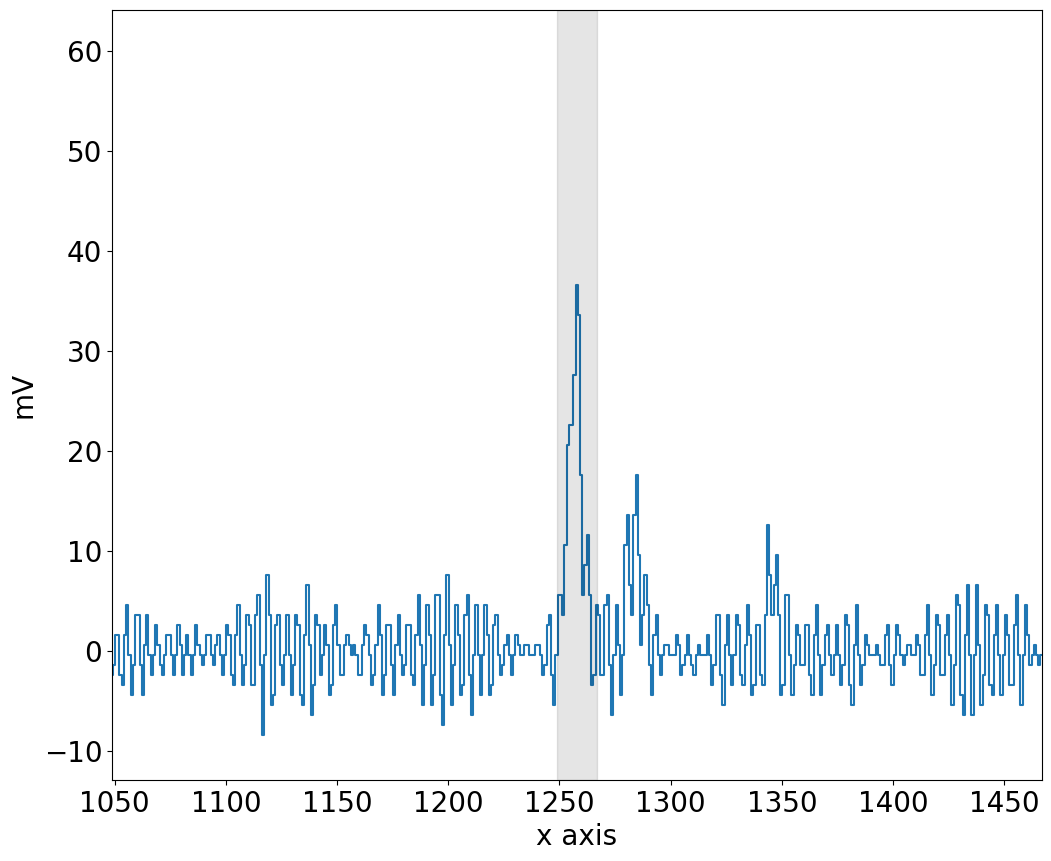

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 21
45 -3


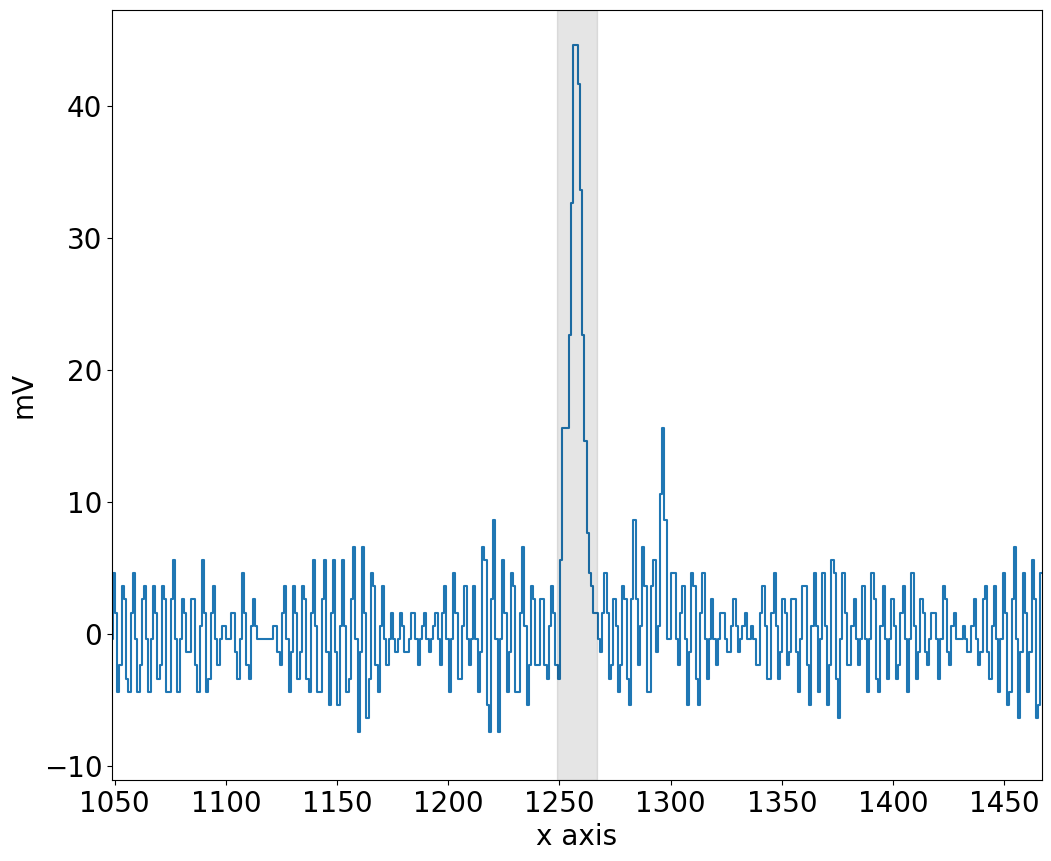

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 22
48 -3


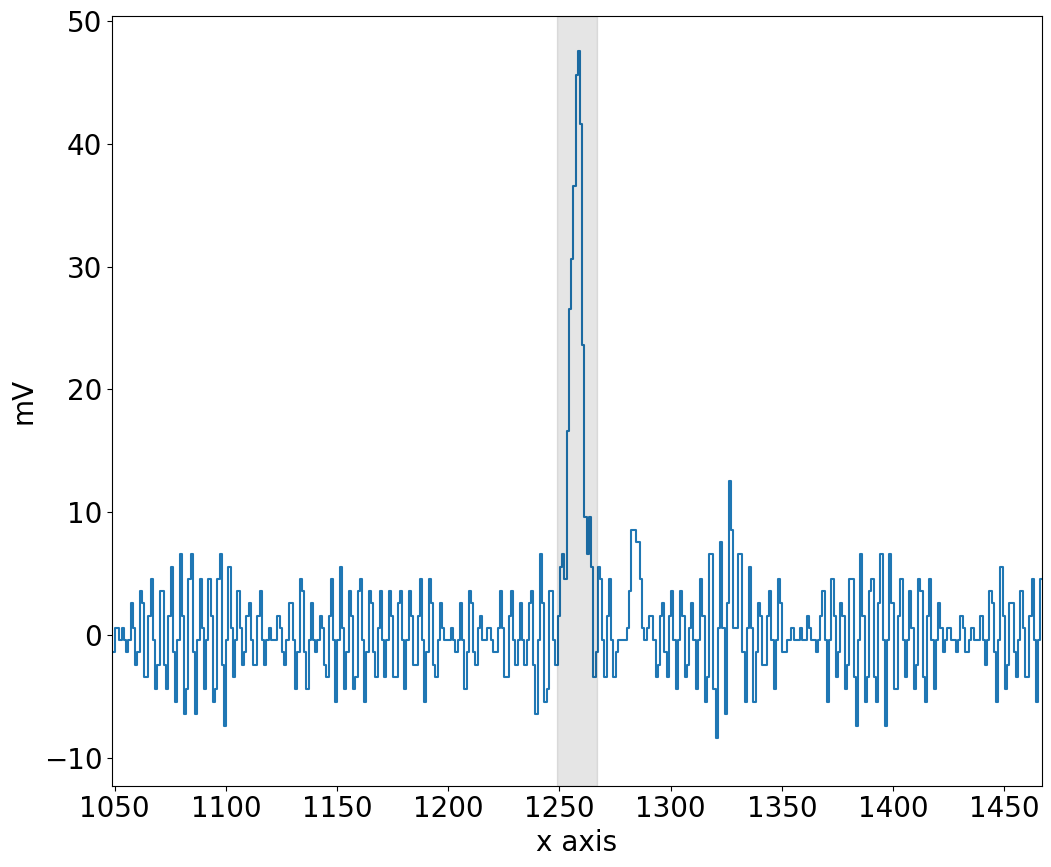

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 23
41 -4


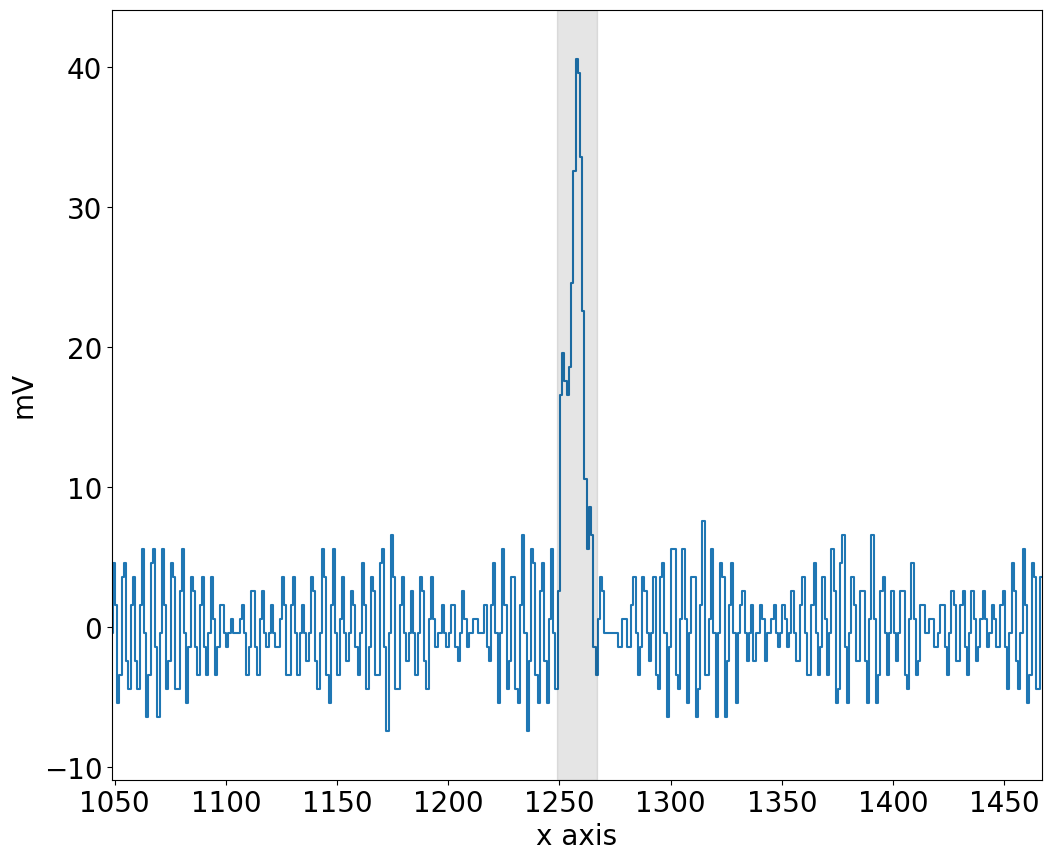

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 24
35 0


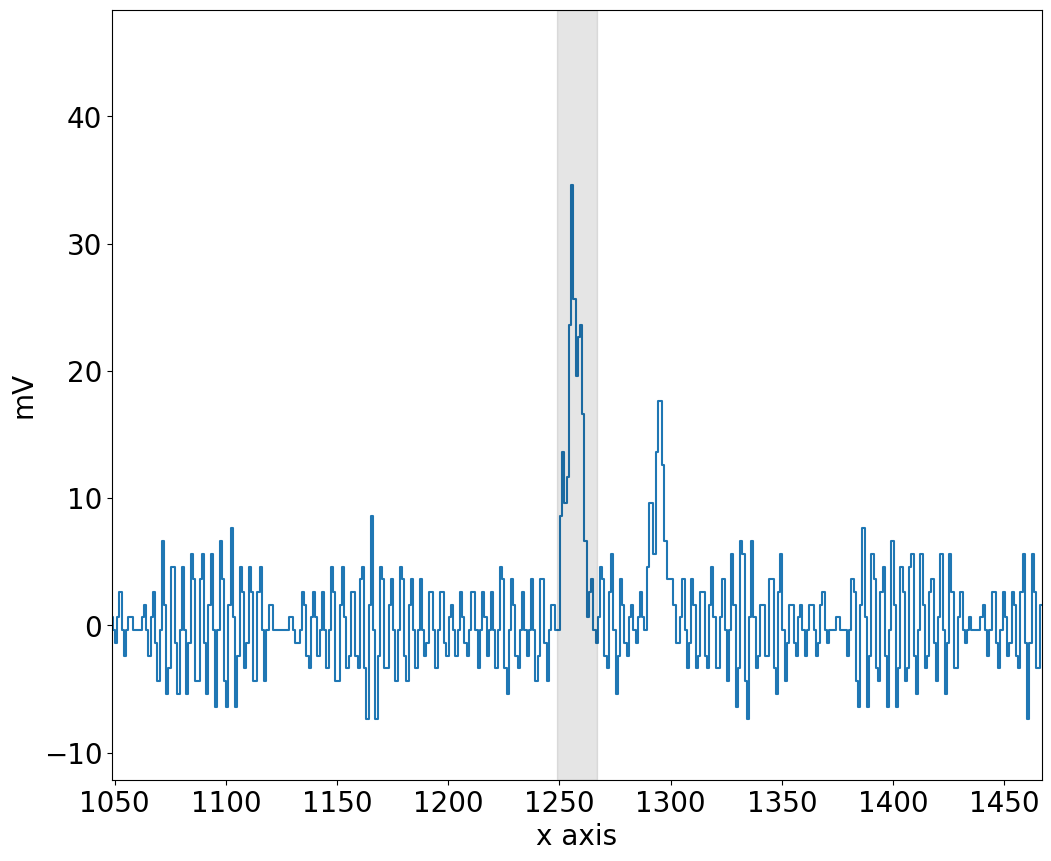

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 25
32 -5


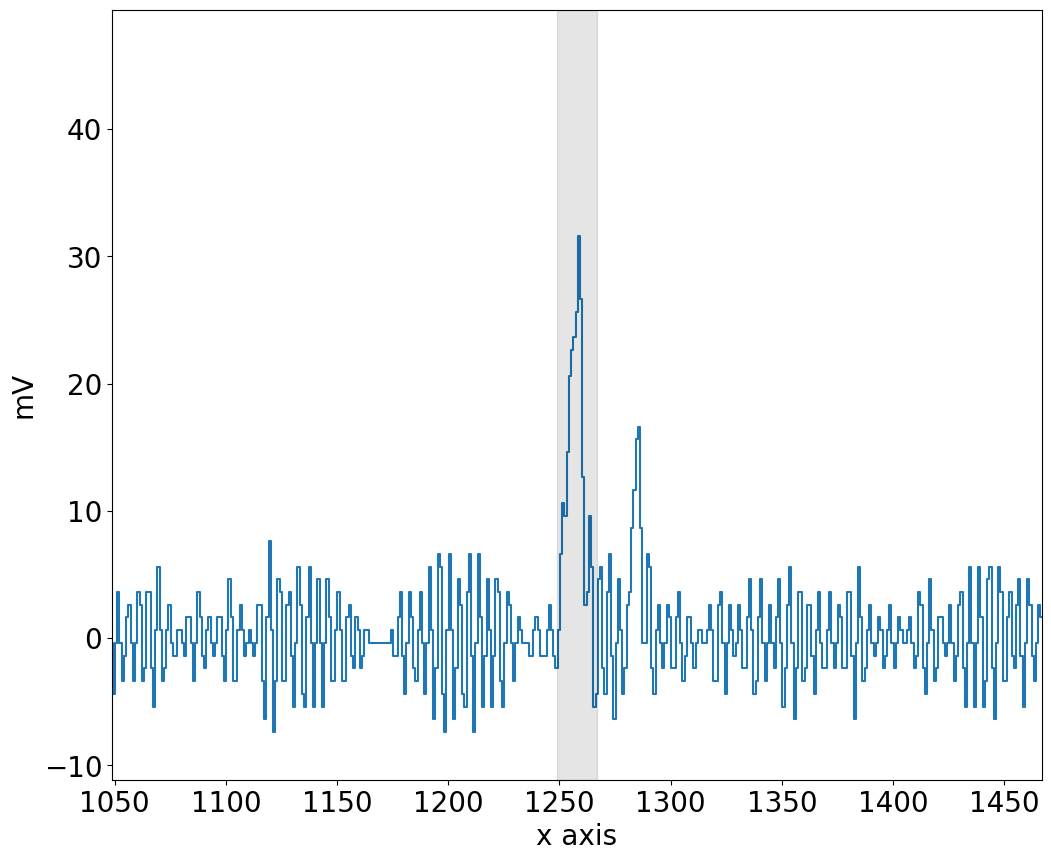

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 26
53 1


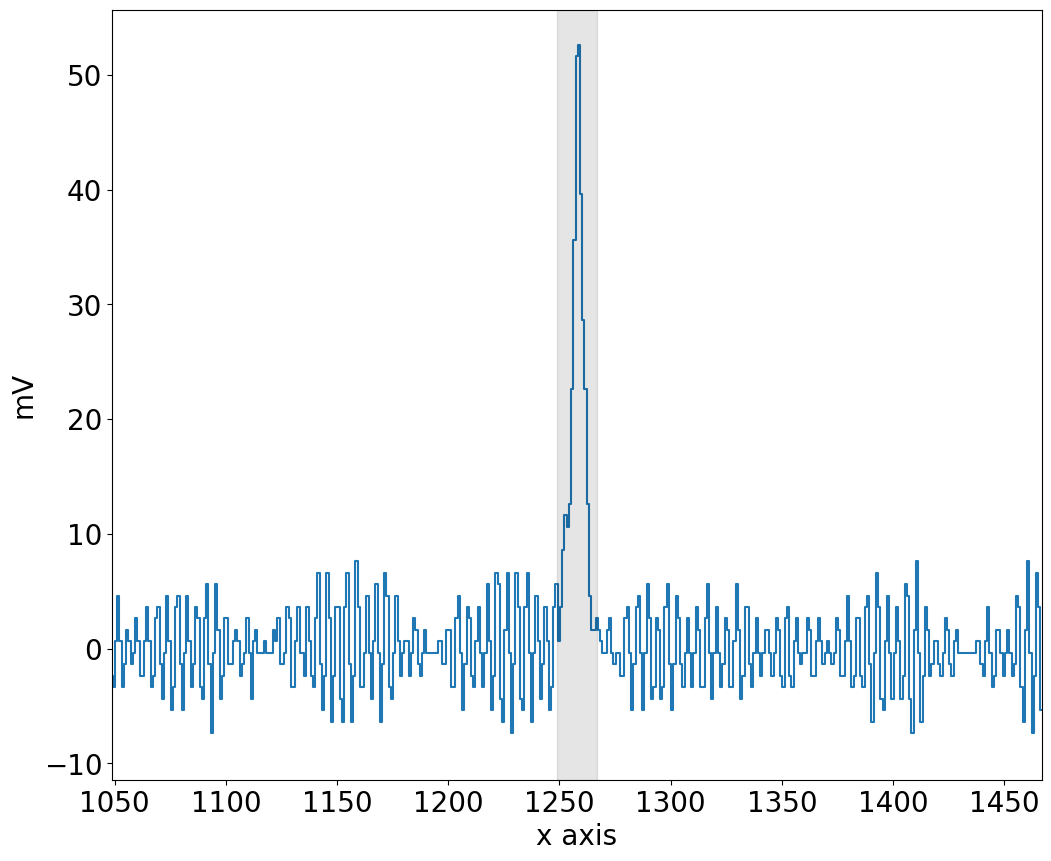

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 27
24 -5


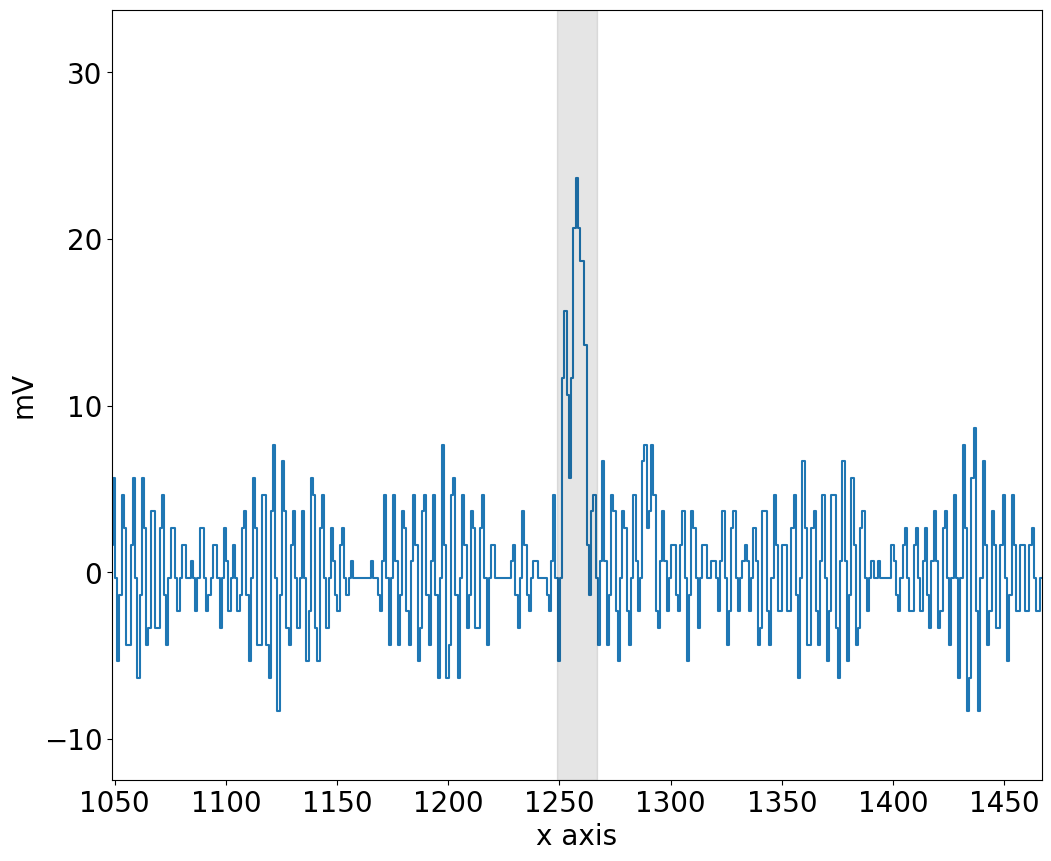

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 28
38 -6


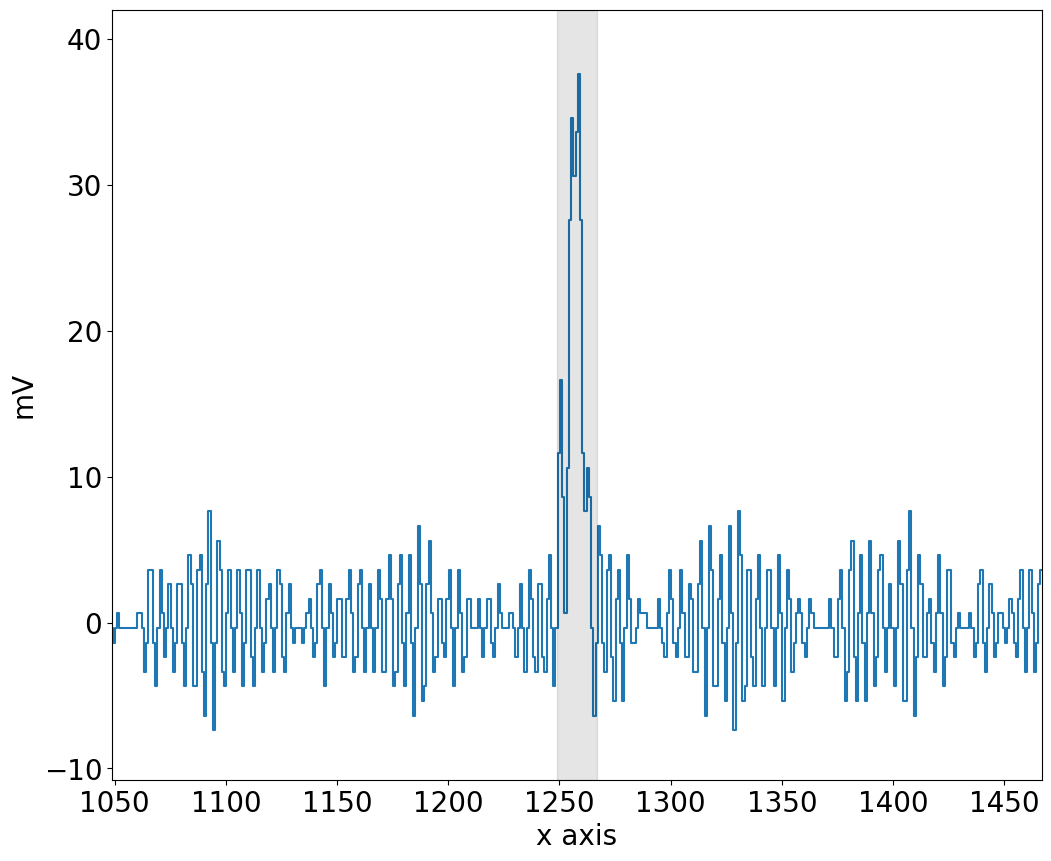

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 29
38 -3


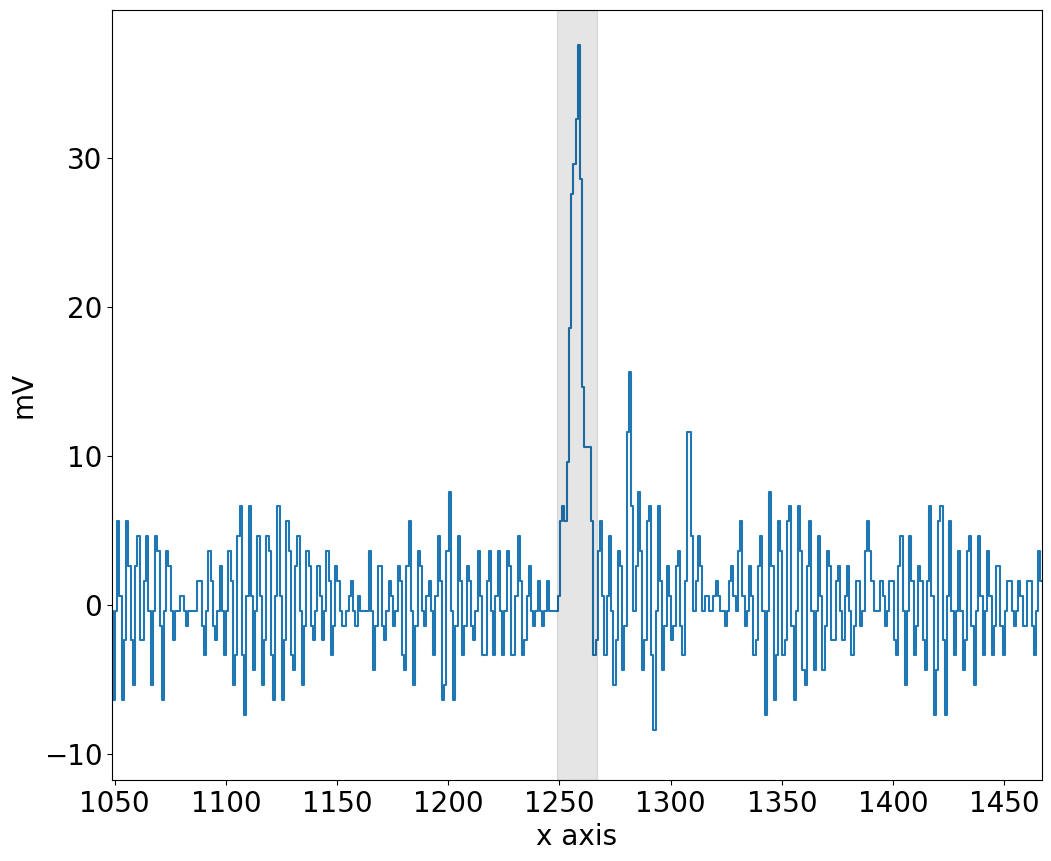

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 30
49 0


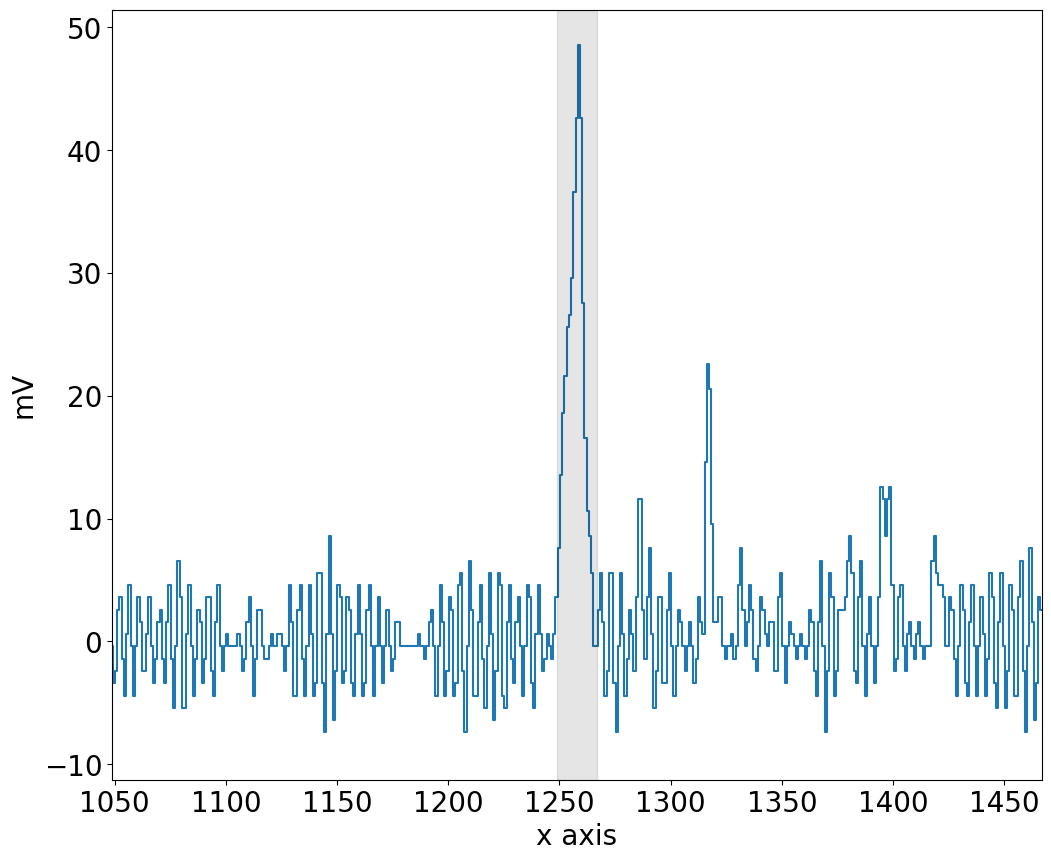

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 31
26 -3


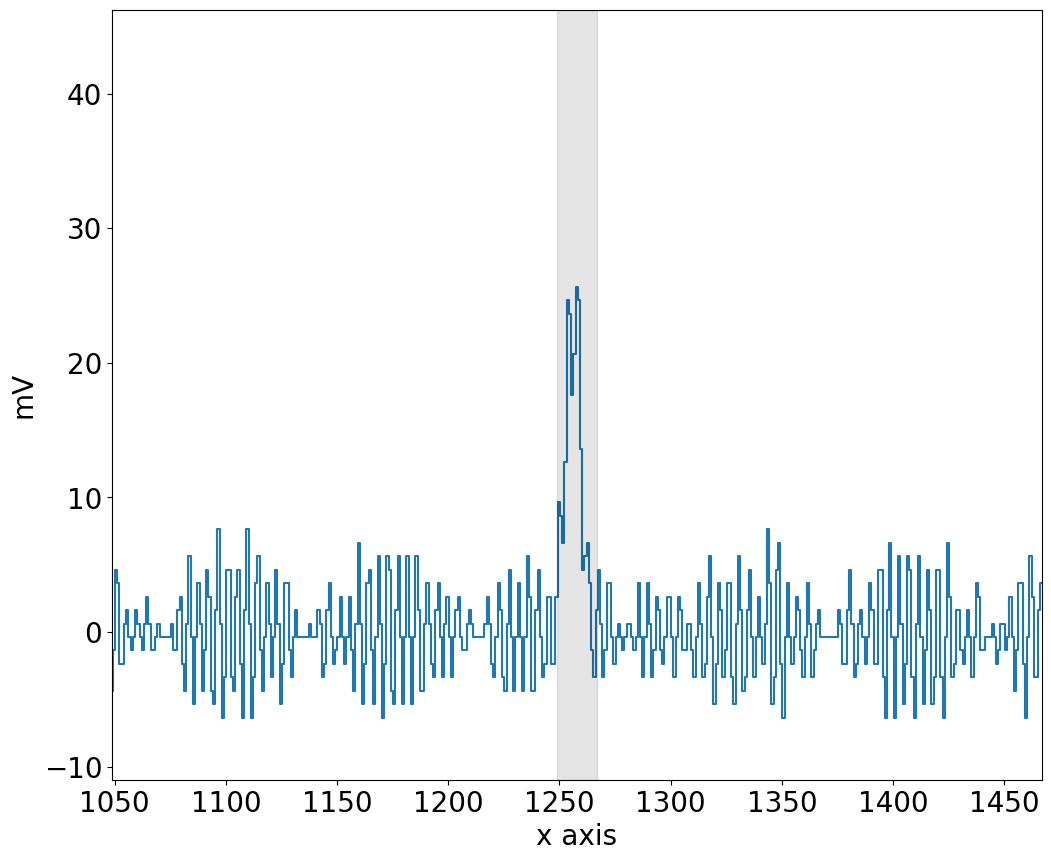

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 32
45 -2


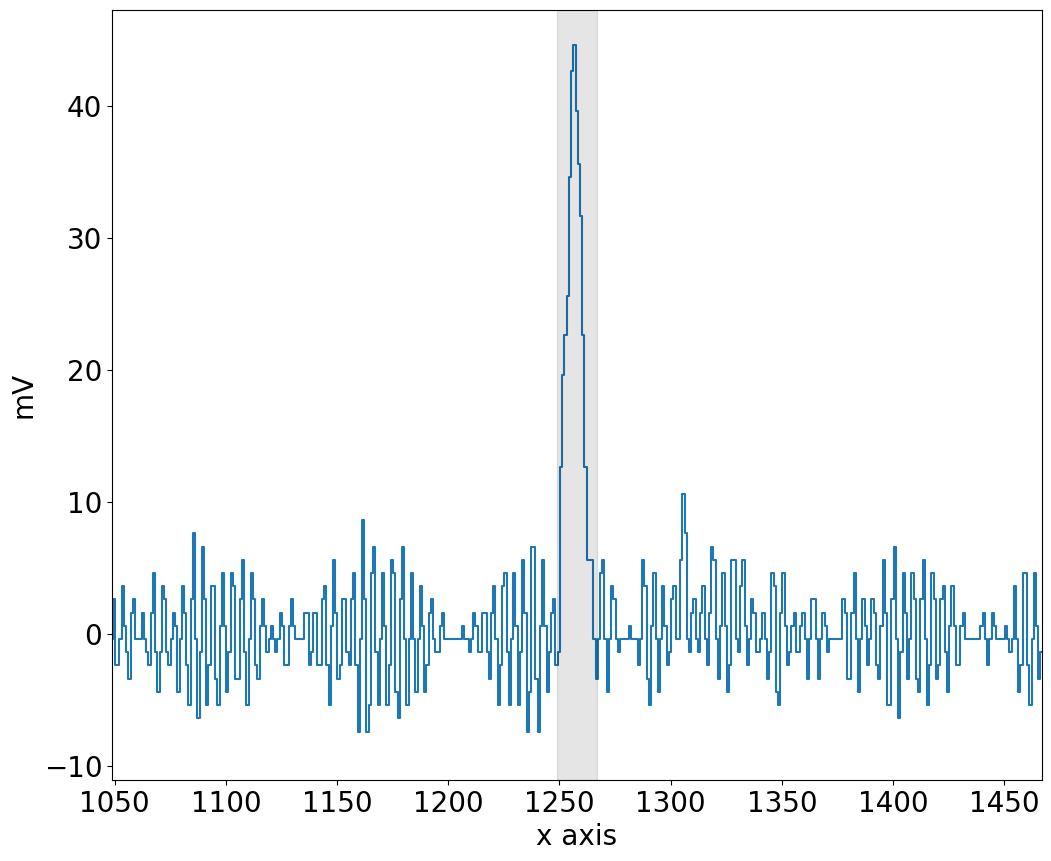

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 33
48 -2


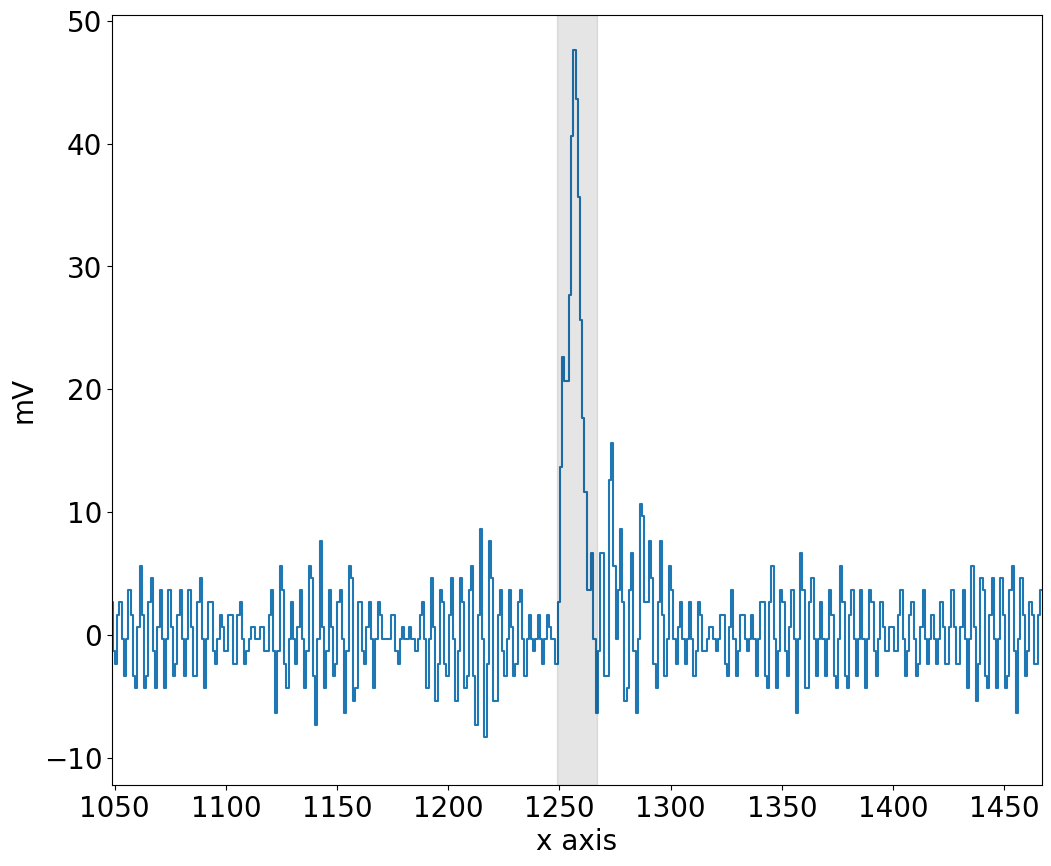

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 34
48 -5


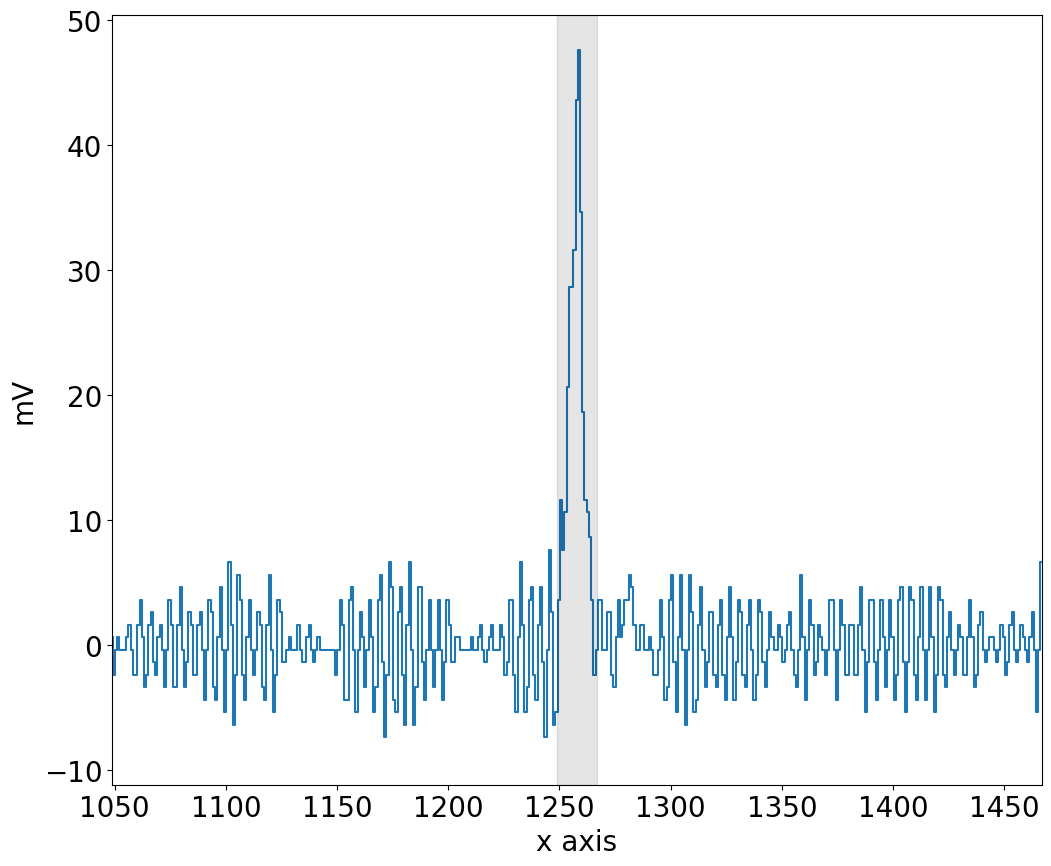

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 35
38 0


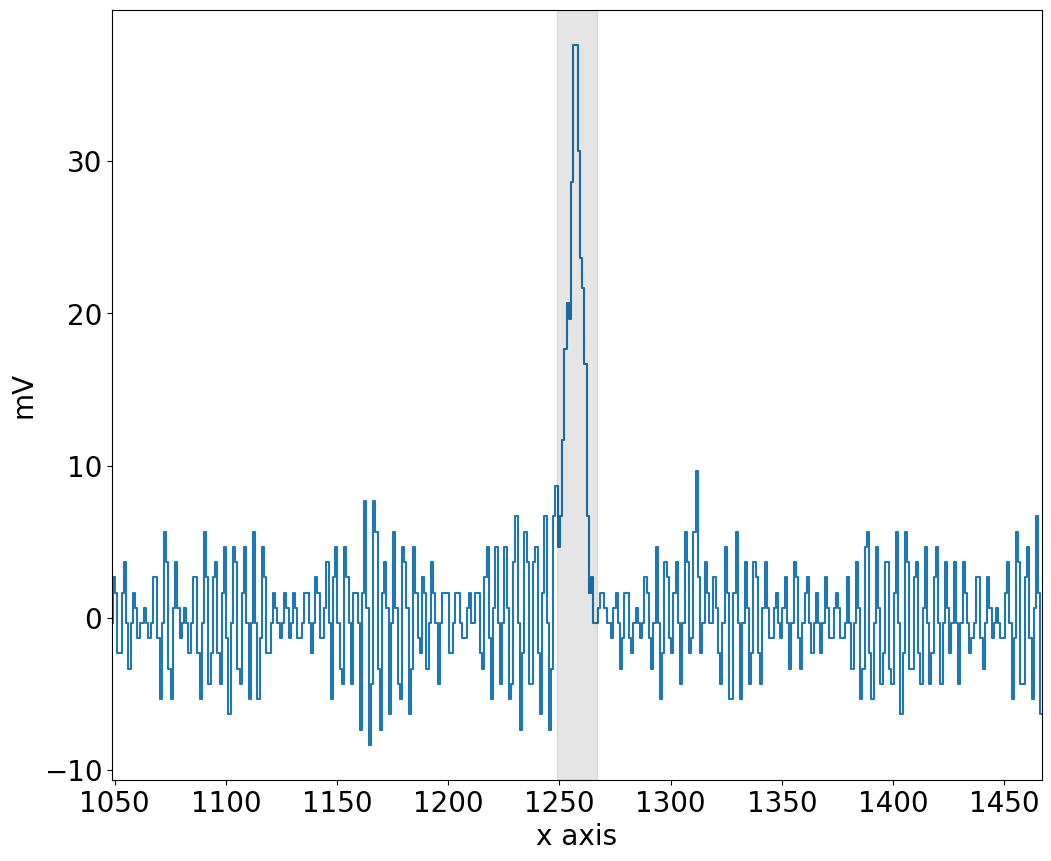

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 36
41 1


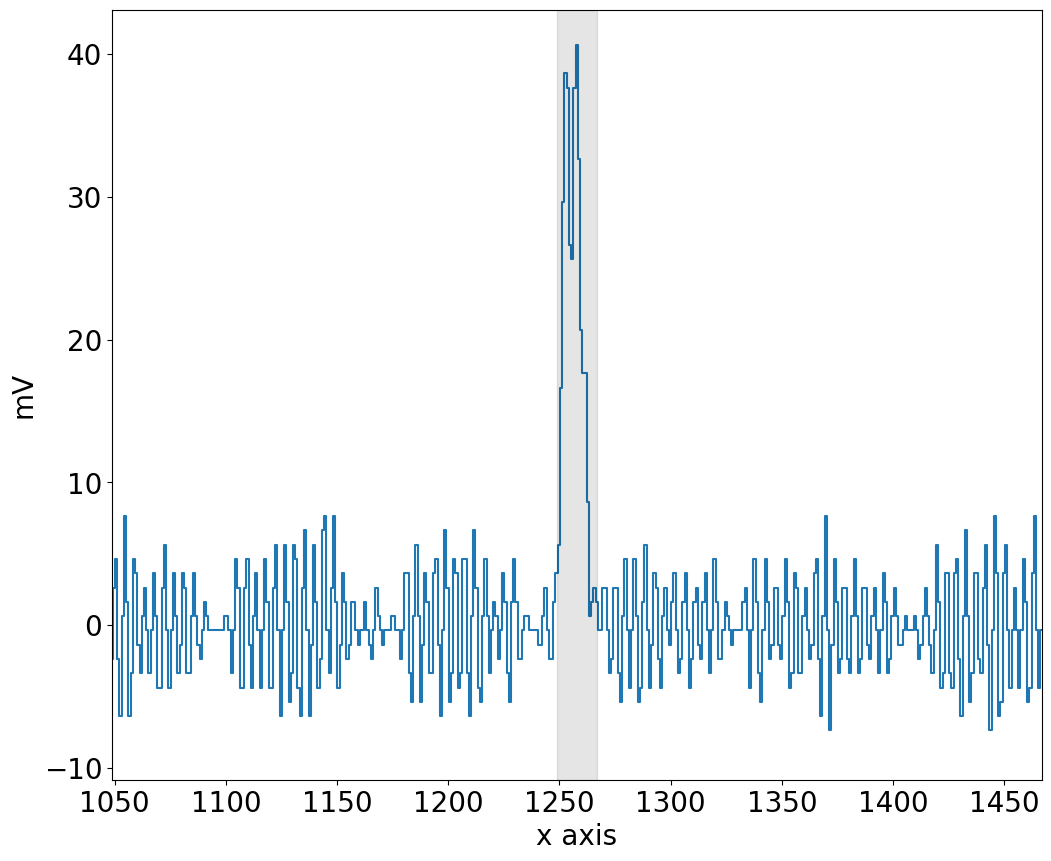

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 37
42 -6


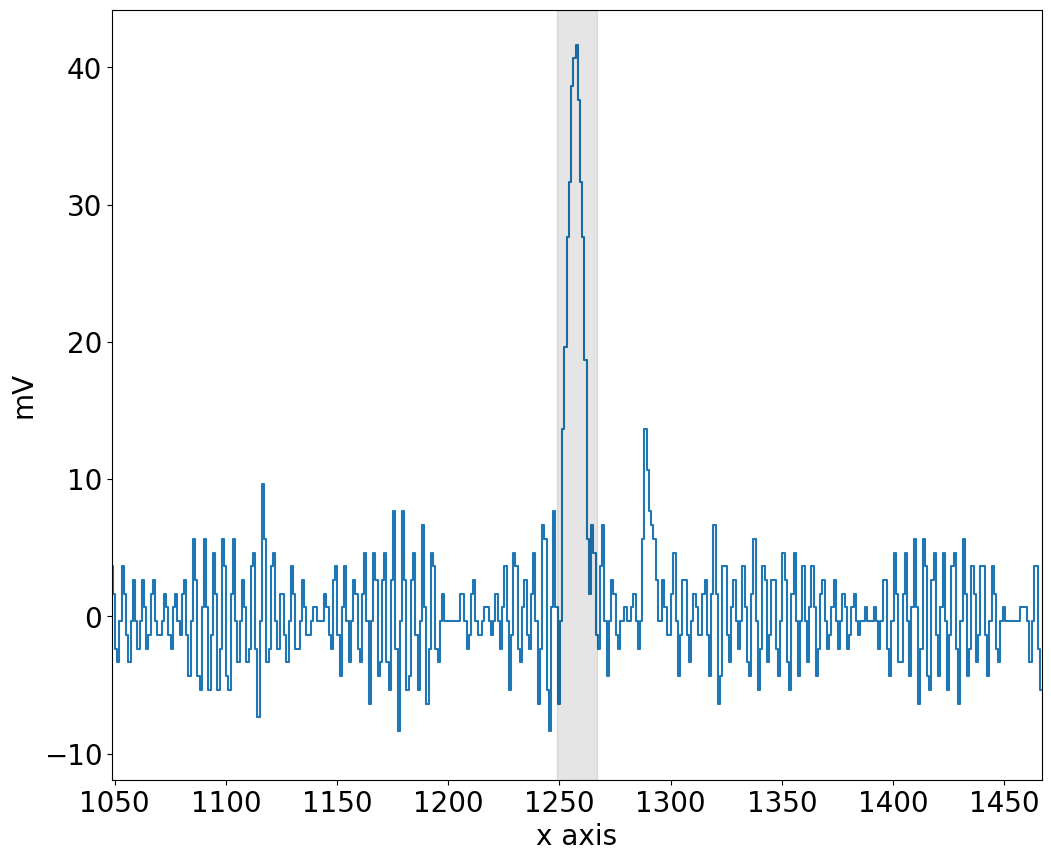

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 38
67 0


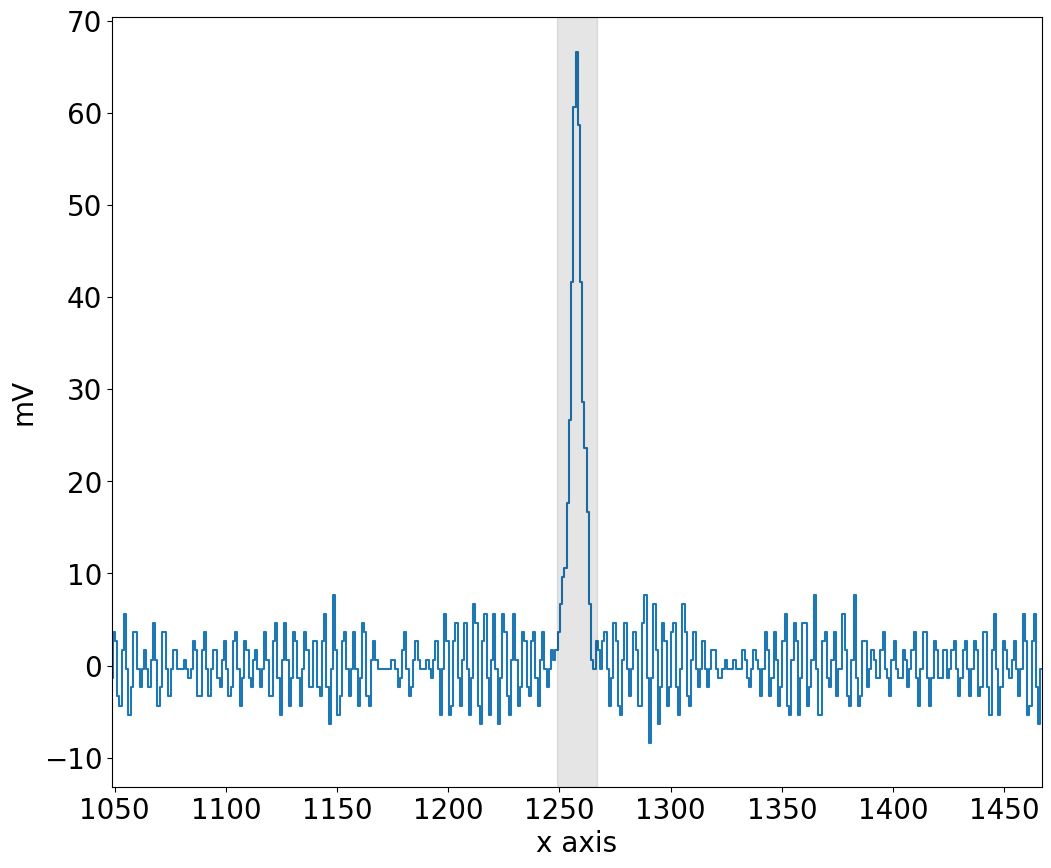

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 39
40 0


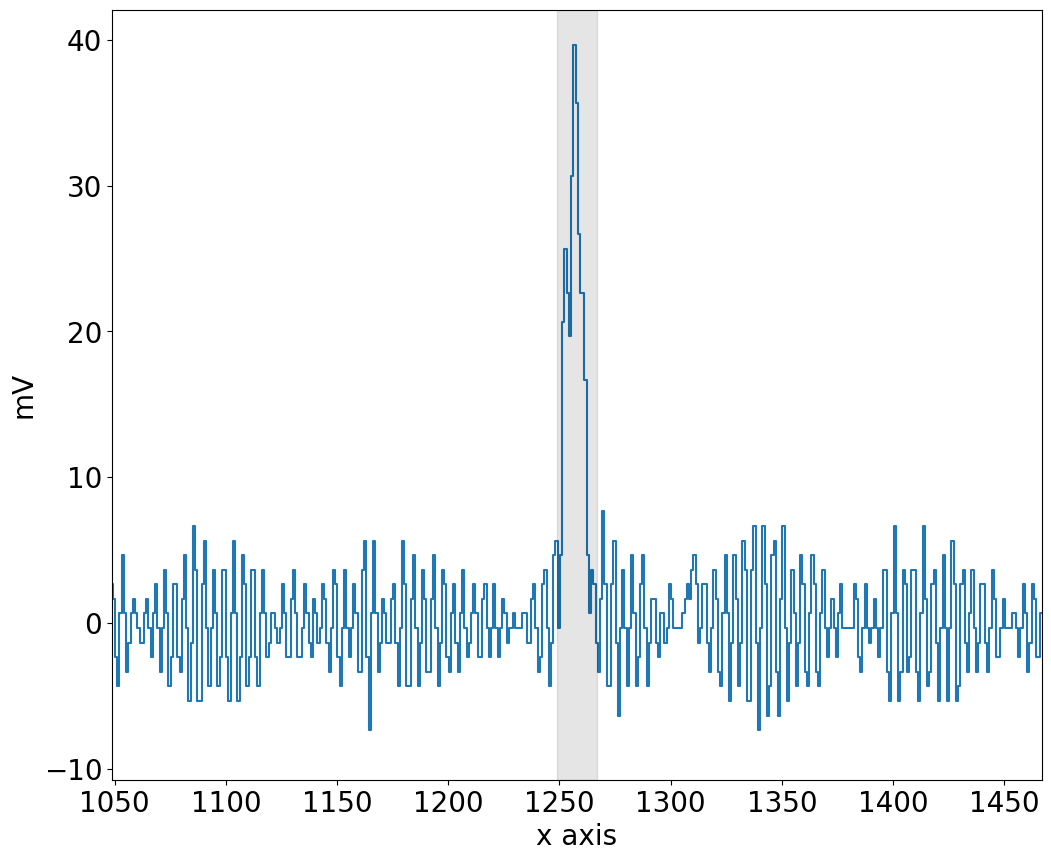

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 40
38 -5


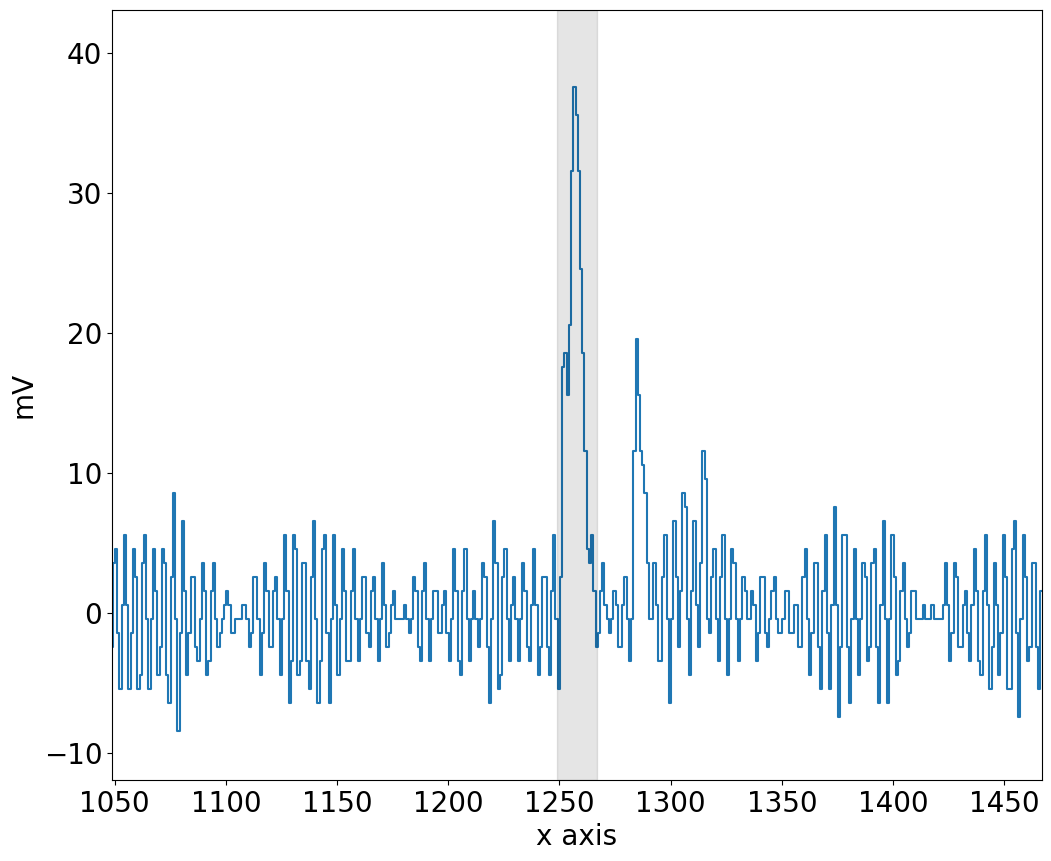

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 41
45 0


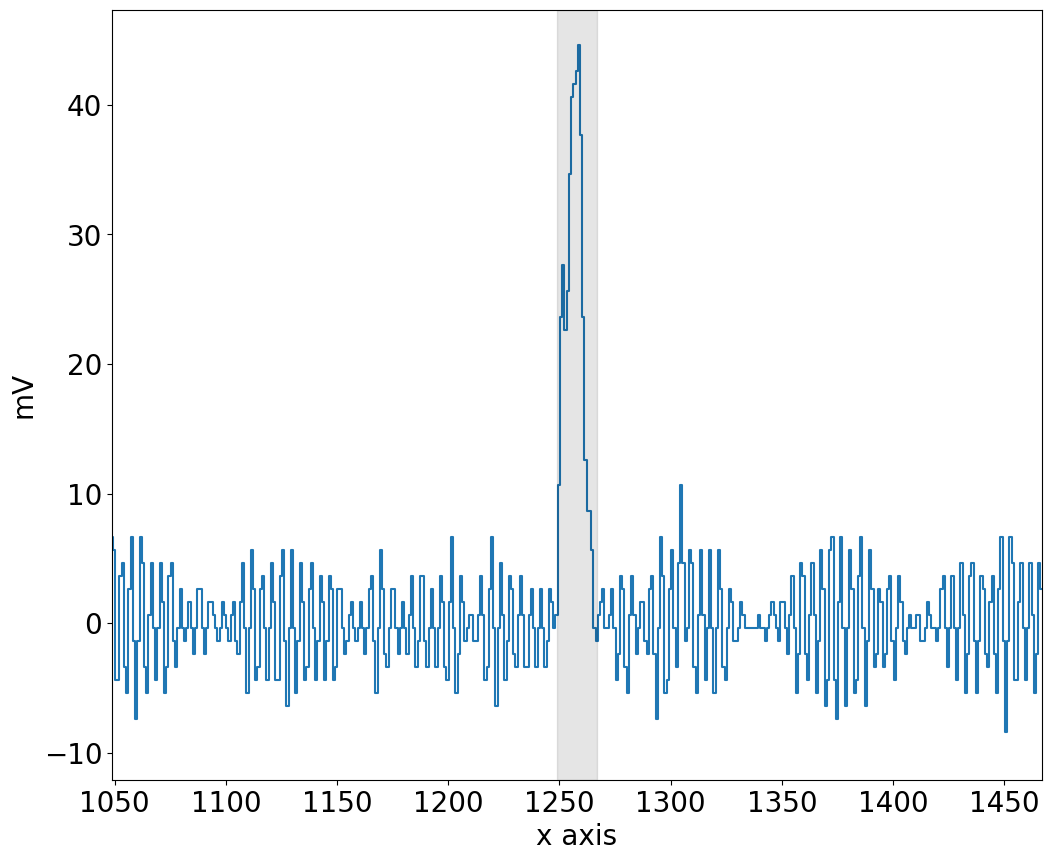

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 42
26 0


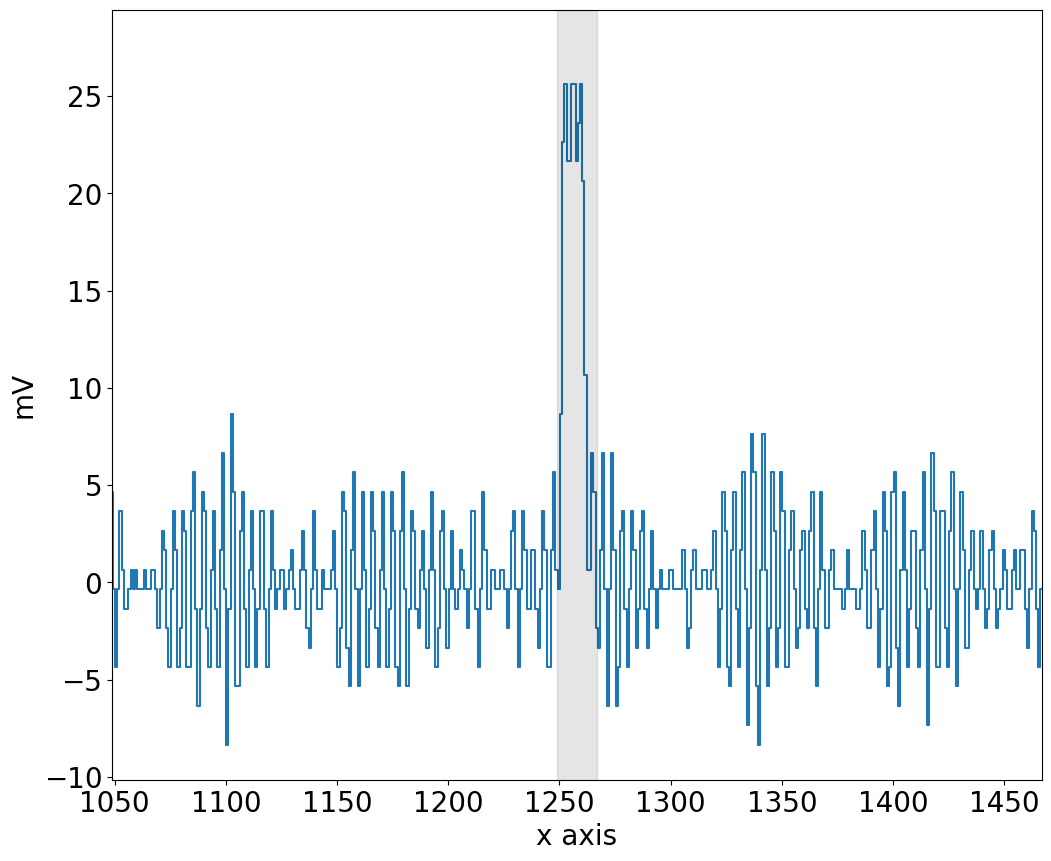

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 43
44 -1


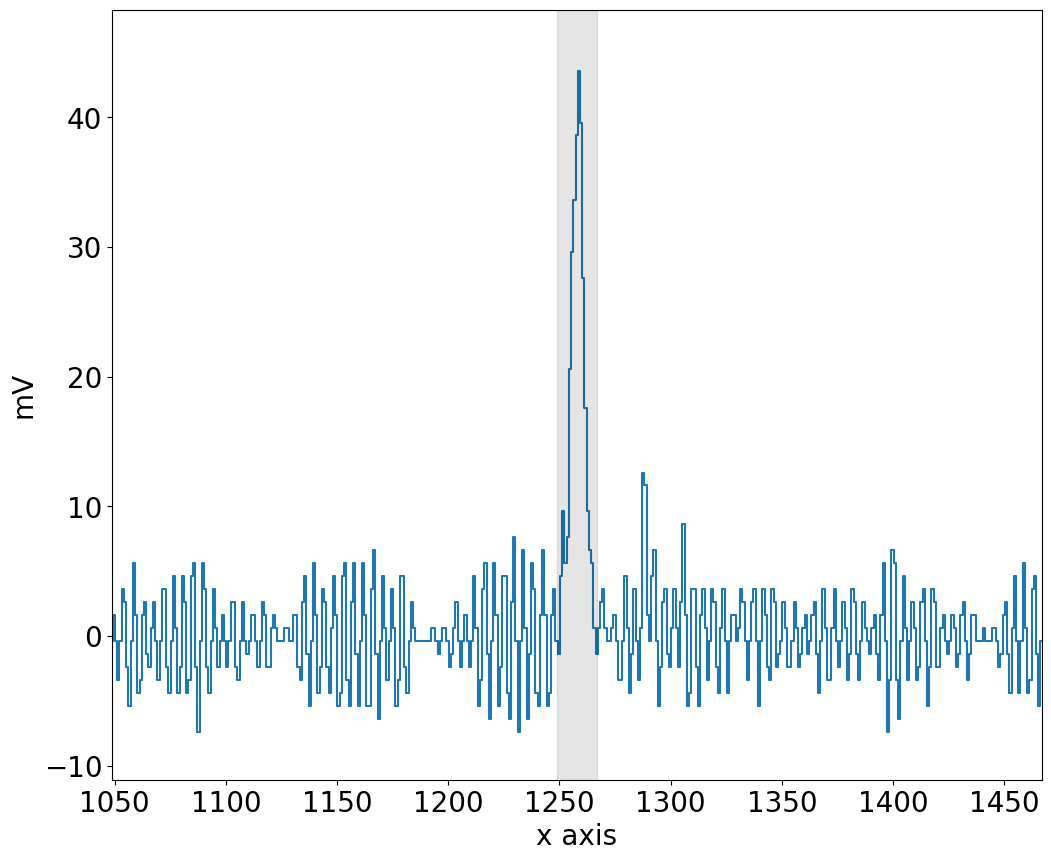

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 44
39 -3


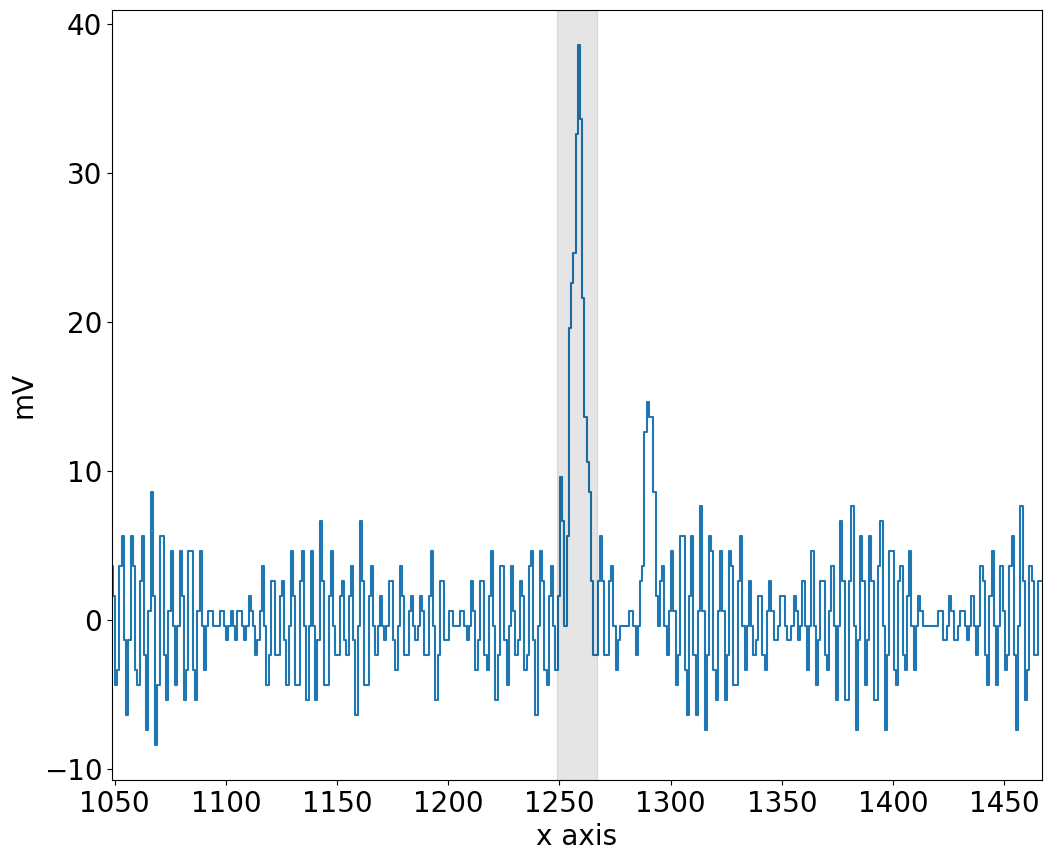

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 45
28 -1


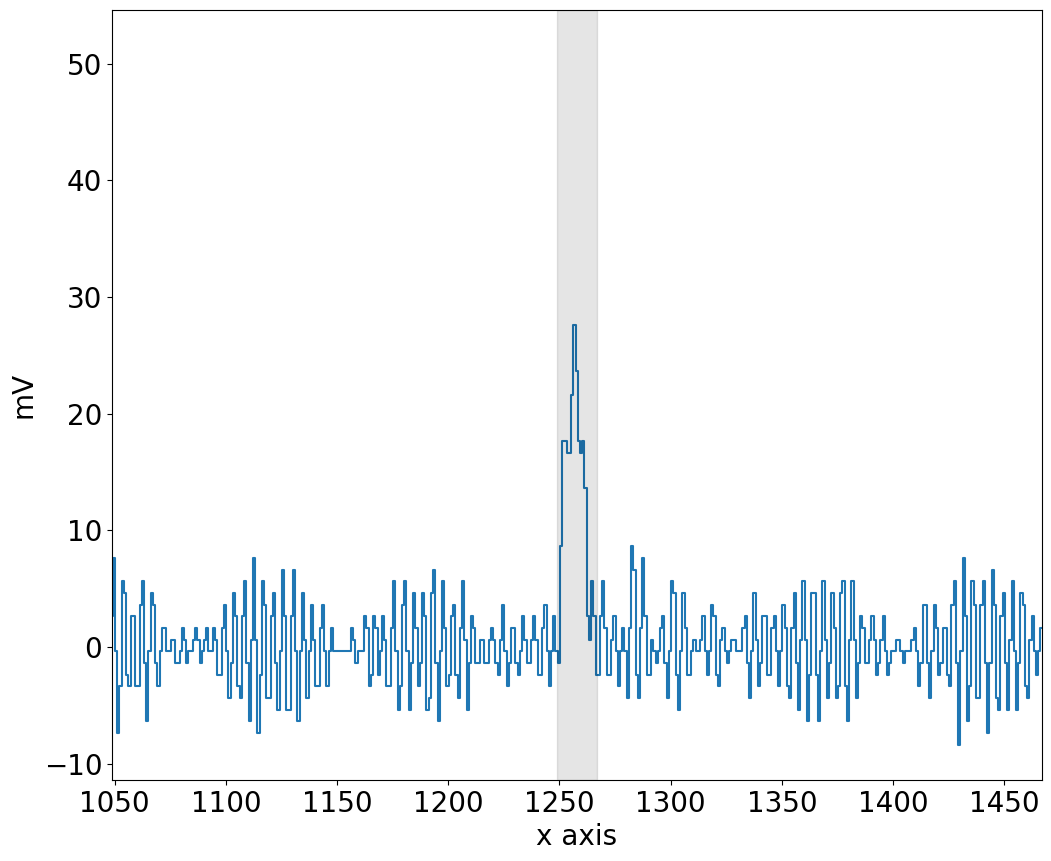

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 46
43 -4


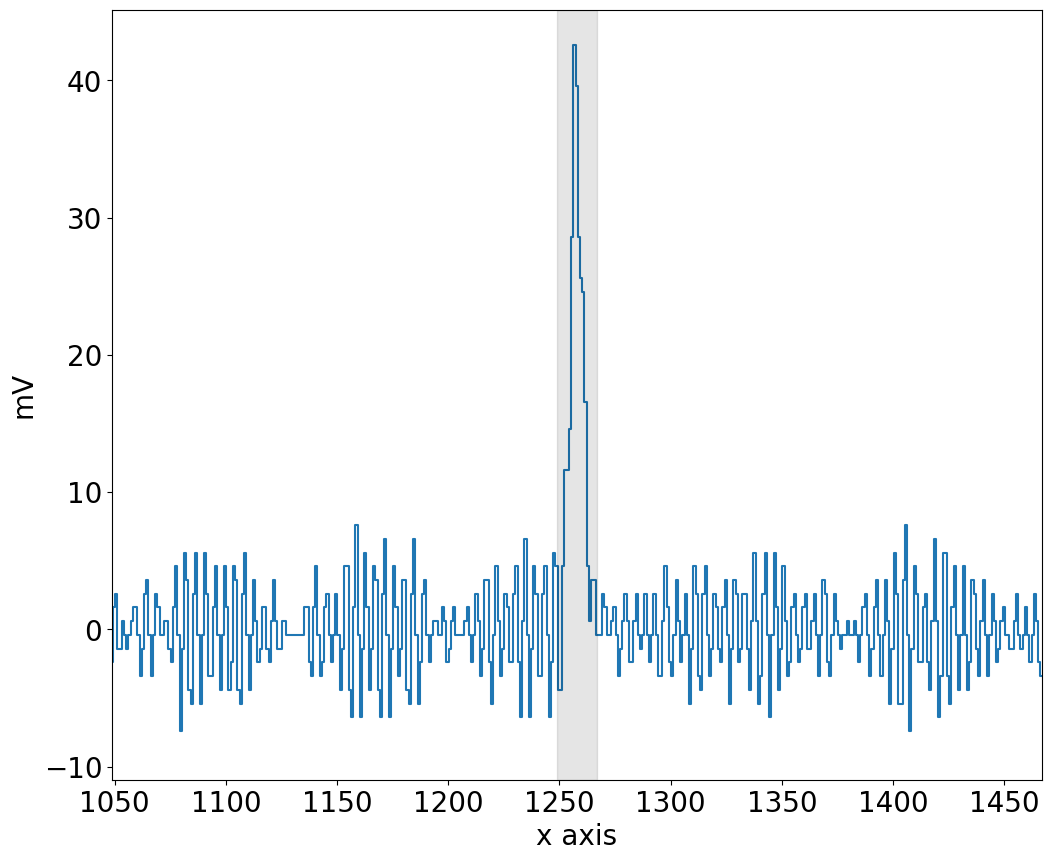

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 47
47 2


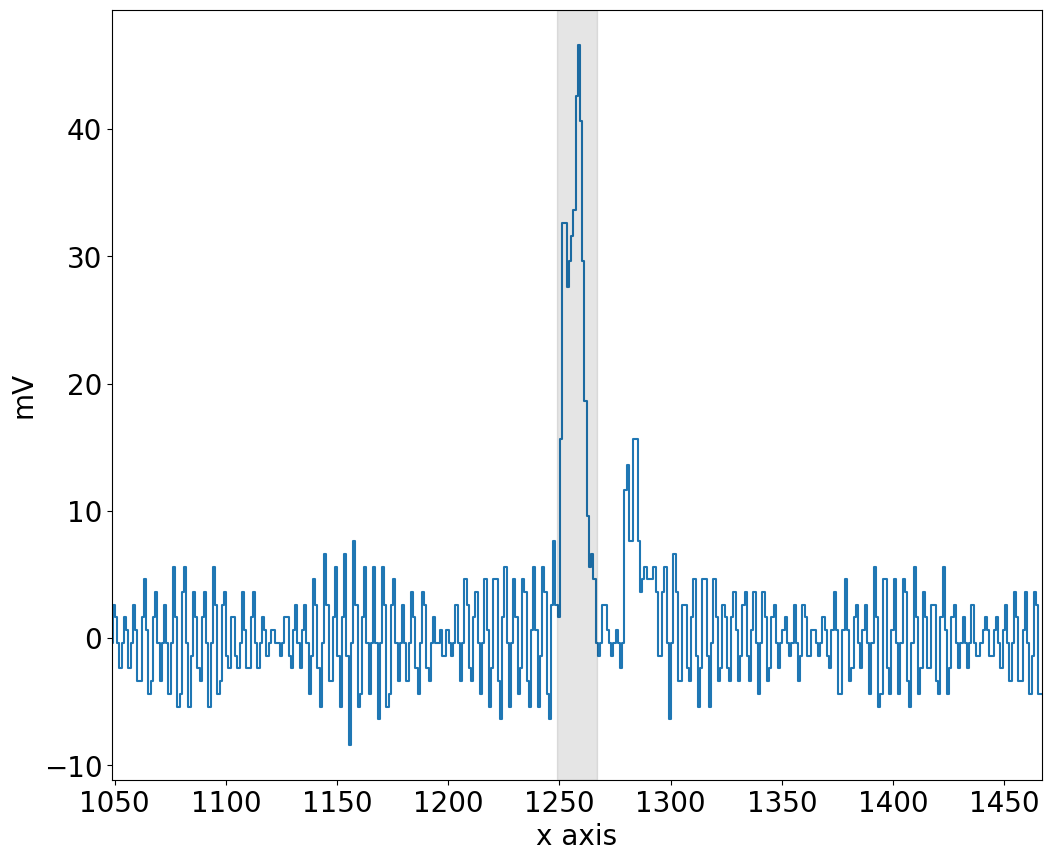

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 48
58 -5


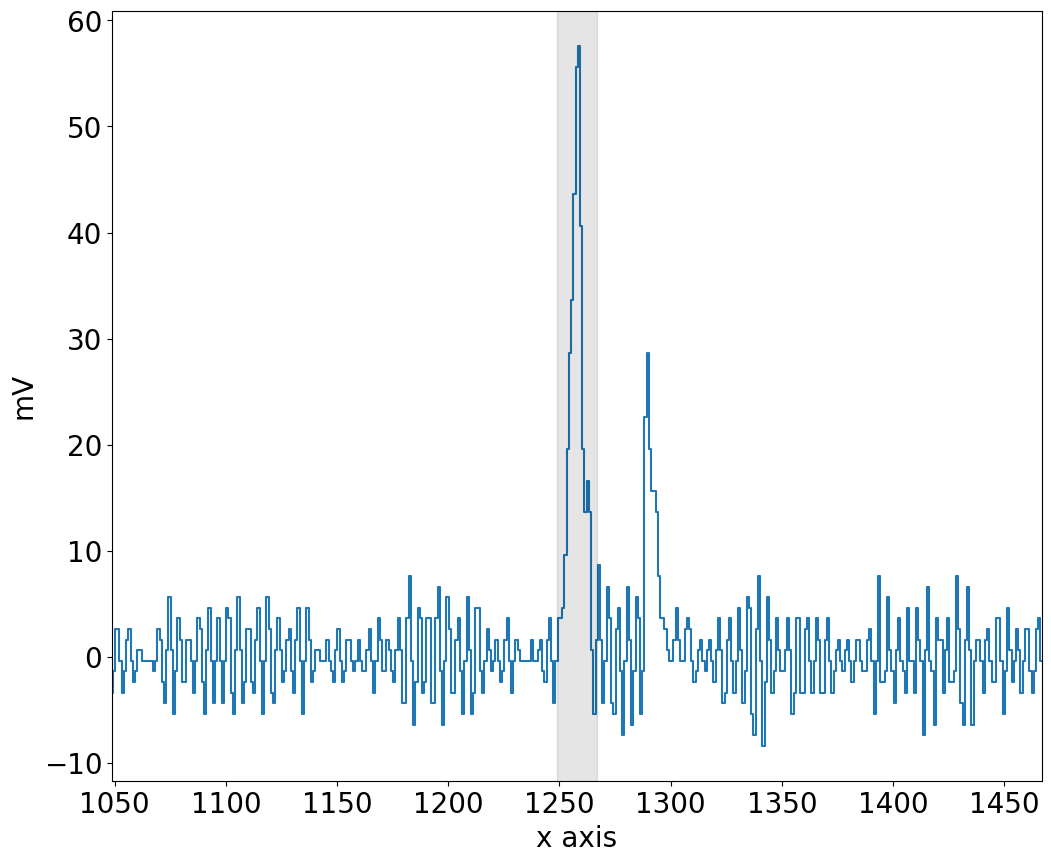

[[-1  5  1 ... -3  3  3]
 [-2 -4  0 ...  4 -3 -5]
 [ 2  5  0 ... -2 -1  1]
 ...
 [ 9  2  0 ...  0 -5 -3]
 [ 2  3 -1 ... -4  4  3]
 [-2 -2  0 ... -3  0  2]]
len pmt_rwf is : 5000
0 49
37 -1


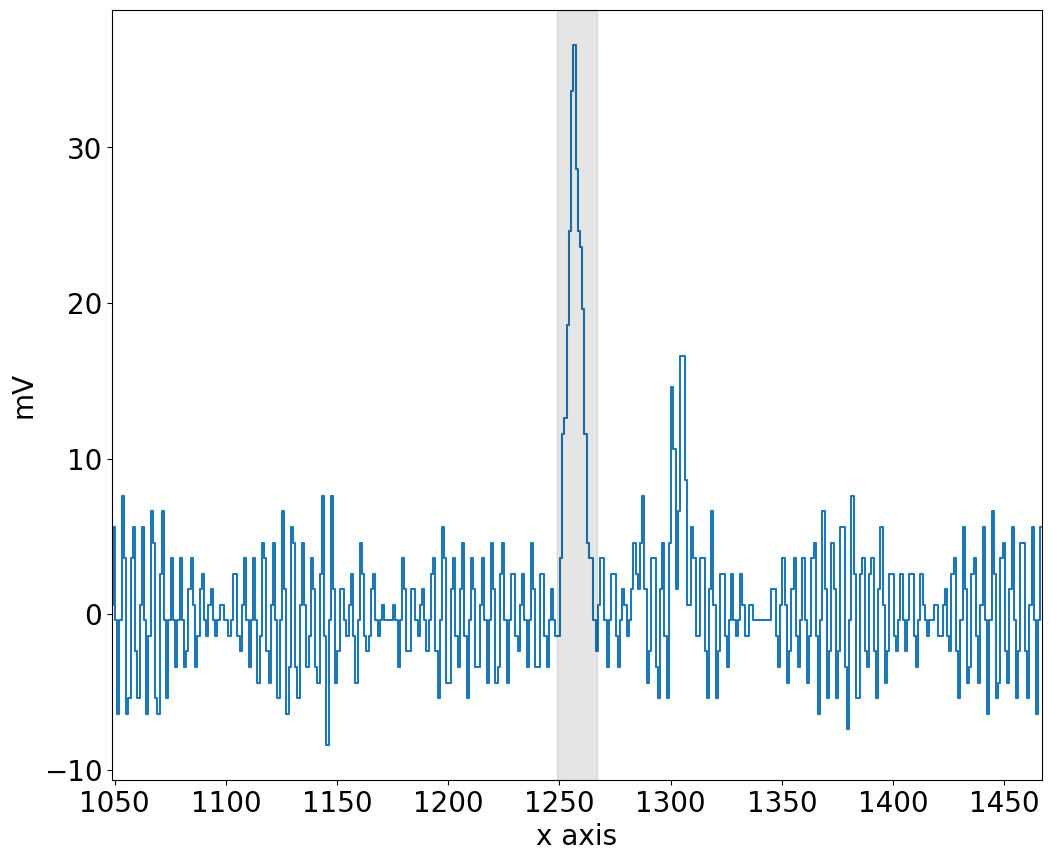

In [2031]:
#to see the rWF and to select intervals
#this interval will be used to integrate later
#It is better to determine the integration window with a run with an intensive voltage to see well the position of the peak

### 1.2kV in pmts
inf = 3 #integration window
sup = 20 #integration window

### 1.1kV in pmts
#inf = 3 #integration window
#sup = 5 #integration window

inf = inf* 5000/40
sup = sup * 5000/40

x_inf = 0 # x scale of the plot
x_sup = 20 # x scale of the plot

x_inf = x_inf* 5000/40 # x scale of the plot
x_sup = x_sup * 5000/40# x scale of the plot

delta_pre = 100 # time before the integration window for baseline sub selection
delta_post = 0

size_int_window = 1 #size of the integration window in microseconds

nbr_fpr = 1  
nbr_wf = 1000

pmt = 0

### 1st run 1.2kV
#run = 2922

### 1st run 1.1kV in pmts
#run = 2942

### 1st run 1.25kV in pmts
run = 2964

###scan of pmt v
#run = 2987


for i in range(0, nbr_fpr): 
    wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run)+'/raw/Run_'+str(run)+'_file_'+str(i)+'_raw.h5'
    
    with tb.open_file(wf_file, 'r') as h5in:
        
        wvfs       =  h5in.root.RD.pmtrwf[:, pmt, :] # Gets all pmt waveforms for 1 PMT
        pmt_rwf    = -wvfs.sum(axis=0)/ (nbr_wf) # We divide the sum of the wf to get the average
        t = np.linspace(0, len(pmt_rwf), len(pmt_rwf))
        print(len(t))
        mask_pre = (t >= (inf - delta_pre)) #definition of a mask for baseline sub 
        mask = (t >= inf) & (t <= sup) # definition of a mask for intergation window
       
        bl_pre = pmt_rwf[~mask_pre]
       
        w_mean = [np.mean(bl_pre)]
        wf_baseS = pmt_rwf - np.mean(w_mean)

        
        plt.plot(t * 40/5000, wf_baseS, drawstyle='steps', lw=1.5, zorder=0)
        center_peak = t[mask][wf_baseS[mask].argmax()]
        trigger_peak = t[mask][wf_baseS[mask] >= 5]
        plt.axvline(center_peak* 40/5000, color='red', linestyle='--')
        plt.axvline(trigger_peak.min()* 40/5000, color='orange', linestyle='--')
        inf1 = trigger_peak.min()* (40-0.08)/5000
        sup1 = trigger_peak.min()* (40+0.5)/5000
        plt.axvspan(inf1,sup1, alpha=0.1, color='k')

        print(inf1* 5000/40, sup1* 5000/40 )
        inf = inf1* 5000/40
        sup = sup1* 5000/40
        #plt.axvline(inf1, color='red', linestyle='--')
        #plt.axvline(sup1, color='orange', linestyle='--')
        
        #plt.plot(t,  pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
        plt.axvspan(inf* 40/5000,sup* 40/5000, alpha=0.1, color='k')
        #plt.axvspan(inf1,sup1, alpha=0.1, color='k')
        plt.axvspan(np.min(t[~mask_pre])* 40/5000,np.max(t[~mask_pre]* 40/5000), alpha=0.1, color='b')
        #plt.axvspan(np.min(t[~mask_post]),np.max(t[~mask_post]), alpha=0.1, color='b')
        plt.xlim(x_inf* 40/5000,x_sup* 40/5000)
        plt.title("Average WF of 1000 events for PMT"+str(pmt))
        plt.xlabel('Time ($\mu$s)')
        plt.ylabel('mV')
        #plt.yscale('log')
        plt.show()
        
        #plot in log view and with a zoom on the integration window to have a more precise selection
        x_log_inf = inf
        x_log_sup = sup
        plt.plot(t[mask]* 40/5000, wf_baseS[mask] , drawstyle='steps', lw=1.5, zorder=0)
        plt.axvspan(inf* 40/5000,sup* 40/5000, alpha=0.1, color='k')
        plt.xlim(x_log_inf* 40/5000,x_log_sup* 40/5000)
        plt.title("Average WF of 1000 events for PMT"+str(pmt))
        plt.xlabel('Time ($\mu$s)')
        plt.ylabel('mV')
        plt.yscale('log')
        plt.show()
        
        
        for j in range(0,50): 
                wvfs       =  h5in.root.RD.pmtrwf[:, 0, :] # Gets all pmt waveforms for 1 PMT
                print(wvfs)
                pmt_rwf = -wvfs[j]
                print('len pmt_rwf is :', len(pmt_rwf))
                #print(np.max(pmt_rwf[mask]), np.min(pmt_rwf[mask]))
                mask_pre = (t >= (inf - delta_pre))
                mask_post = (t <= sup)
                mask = (t >= inf) & (t <= sup) 
                bl_pre = pmt_rwf[~mask_pre]
                bl_post = pmt_rwf[~mask_post]
                w_mean = [np.mean(bl_pre), np.mean(bl_post)]
                wf_baseS = pmt_rwf - np.mean(w_mean)
                
                print(i, j)
                print(np.max(pmt_rwf[mask]), np.min(pmt_rwf[mask]))
                plt.plot(t, wf_baseS, drawstyle='steps', lw=1.5, zorder=0)
                #plt.plot(t[mask], wf_baseS[mask], drawstyle='steps', lw=1.5, zorder=0)
                plt.axvspan(inf,sup, alpha=0.1, color='k')
                plt.xlim(x_log_inf-200,x_log_sup+200)
                #plt.ylim(0.001, 1000000)
                plt.xlabel('x axis')
                #plt.xlim(10.2,15)
                plt.ylabel('mV')
                #plt.yscale('log')
                plt.show()
                



In [2032]:
#to find the baseline and to store integral in a precise interval for calibration (WORK WELL!!!)

nbr_wf = 1000 #should always be 1000
nbr_fpr = 15 #number of files per runs


#run_nb = np.arange(2922, 2942, 1) #1.2kV in PMTs
#run_nb = np.arange(2942, 2964, 1) #1.1kV in PMTS
run_nb = np.arange(2964, 2988, 1) #1.25kV in PMTS
#run_nb = np.arange(2987, 2999, 1) 
pmts = [0,1,2,3,4,5,6]

for run in run_nb:
    for pmt in pmts:
        integral_store = []
        print(f'Run is : {run}\n number of files is : {nbr_fpr}\n number of WF per file is : {nbr_wf}\n Integration interval is : [{inf}, {sup}]\n delta pre is : {delta_pre}\n PMT seen is : PMT{pmt}\n delta post is : {delta_post}')

        for i in range(0, nbr_fpr):
            wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R'+str(run)+'/raw/Run_'+str(run)+'_file_'+str(i)+'_raw.h5'

            with tb.open_file(wf_file, 'r') as h5in:
                print(f'File number : {i}')
                ### Here we load a WF in order to create the variable t only 1 time in the good dimension and define some mask for integration window and baseline calculation
                wvfs       =  h5in.root.RD.pmtrwf[:, pmt, :] #Get all WF for 1 PMT
                #print(wvfs)
                pmt_rwf = -wvfs[0] #load of the first WF
                #print(pmt_rwf)
                #input()
                t = np.linspace(0, len(pmt_rwf), len(pmt_rwf)) #definition of x axis with the number of points contained in 1 WF
                dt = t[1] - t[0]

                #mask for baseline interval
                #mask_pre = (t >= inf)
                mask_pre = (t >= (inf - delta_pre)) #mask for baseline calculation, we take all values > start of integration window - delta to isolate start of the curve when ~mask is applied
                #mask_post = (t <= sup)
                #mask_post = (t <= sup + delta_post)
                #msk for integration interval
                mask = (t >= inf) & (t <= sup) #definition of the integration window
                for j in range(0,nbr_wf):
                    #print(wvfs)
                    pmt_rwf = -wvfs[j] #load each wf contained in 1 file one by one
                    #print(pmt_rwf)
                    #input()
                    #print(f'WF number : {j}')

                    #t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))
                    #input()
                    #baseline sub
                    bl_pre = pmt_rwf[~mask_pre] #selection of the baseline
                    #bl_post = pmt_rwf[~mask_post]
                    #w_mean = [np.mean(bl_pre), np.mean(bl_post)]
                    w_mean = [np.mean(bl_pre)] #mean value of the baseline window
                    wf_baseS = pmt_rwf - np.mean(w_mean) #we subtract the wf by the mean of the baseline in order to remove it

                    #integral of the WF with baseline sub between the interval
                    integral = np.sum(wf_baseS[mask]) #we do the sum of the points in the integration window for 1 wf

                    #if (np.min(wf_baseS[mask]) >= -1.5):
                    integral_store.append(integral) #we store all the integrals in an array
                print(f'Number of int saved : {len(integral_store)}')

        data_file = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/R"+str(run)+"_PMT"+str(pmt)+"_"+str(int(inf))+"_"+str(int(sup))+".txt"
        np.savetxt(data_file, integral_store, fmt="%.8f")


Run is : 2964
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT0
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2964
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre 

Run is : 2965
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT3
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2965
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre 

Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2966
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT6
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2967
 number of files

Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2968
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT2
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int s

Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2969
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT5
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved

...

Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2981
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT0
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved

Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2982
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT3
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved

Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2983
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT6
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved

Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2985
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT2
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved

Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved : 4000
File number : 4
Number of int saved : 5000
File number : 5
Number of int saved : 6000
File number : 6
Number of int saved : 7000
File number : 7
Number of int saved : 8000
File number : 8
Number of int saved : 9000
File number : 9
Number of int saved : 10000
File number : 10
Number of int saved : 11000
File number : 11
Number of int saved : 12000
File number : 12
Number of int saved : 13000
File number : 13
Number of int saved : 14000
File number : 14
Number of int saved : 15000
Run is : 2986
 number of files is : 15
 number of WF per file is : 1000
 Integration interval is : [1248.74774954991, 1266.890878175635]
 delta pre is : 100
 PMT seen is : PMT5
 delta post is : 0
File number : 0
Number of int saved : 1000
File number : 1
Number of int saved : 2000
File number : 2
Number of int saved : 3000
File number : 3
Number of int saved

2987 6 1248.74774954991 1266.890878175635
LED_V is : 23
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT0_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2972_PMT0_1248_1266.txt

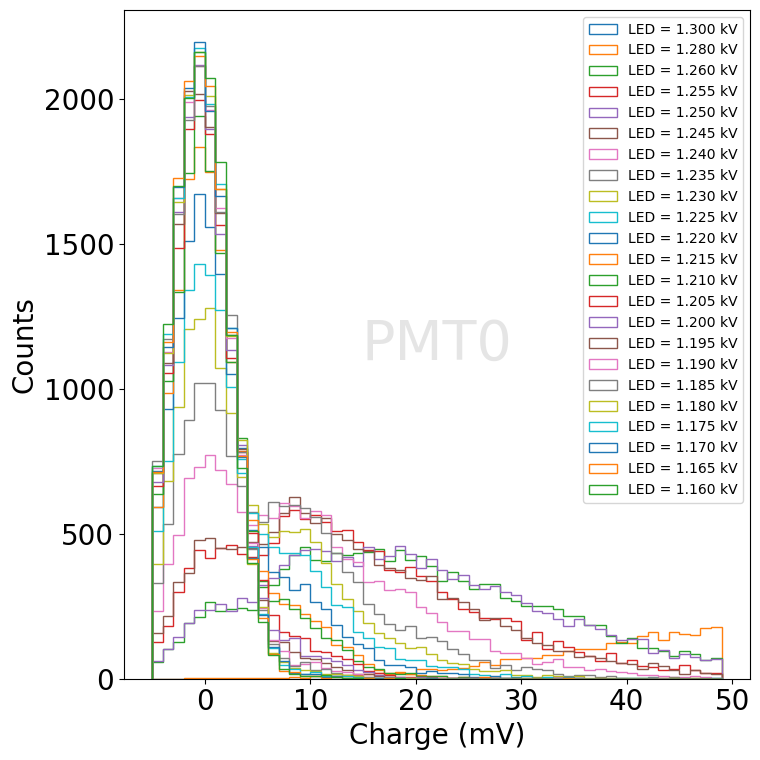

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT0_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT1_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

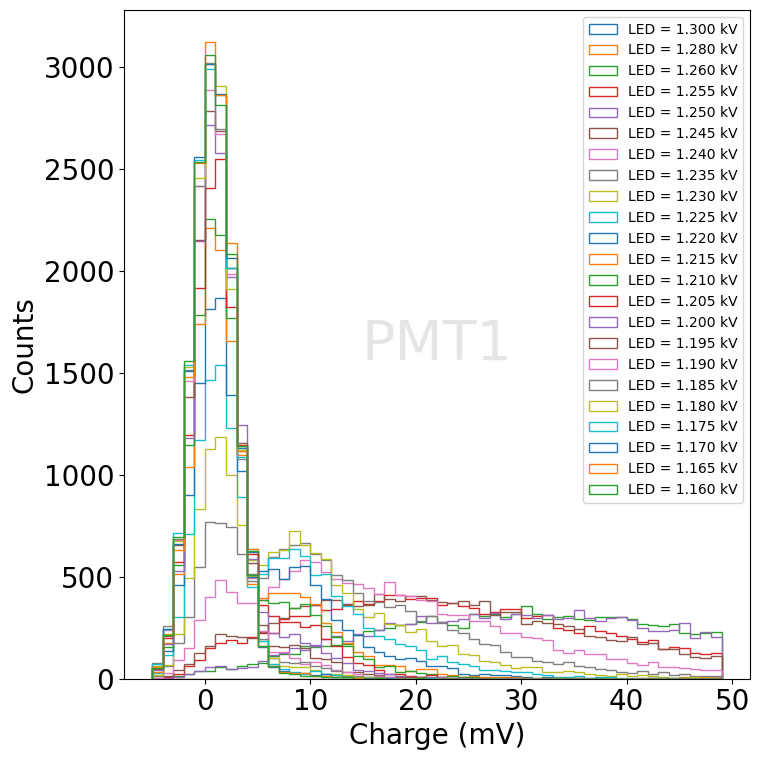

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT1_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT2_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

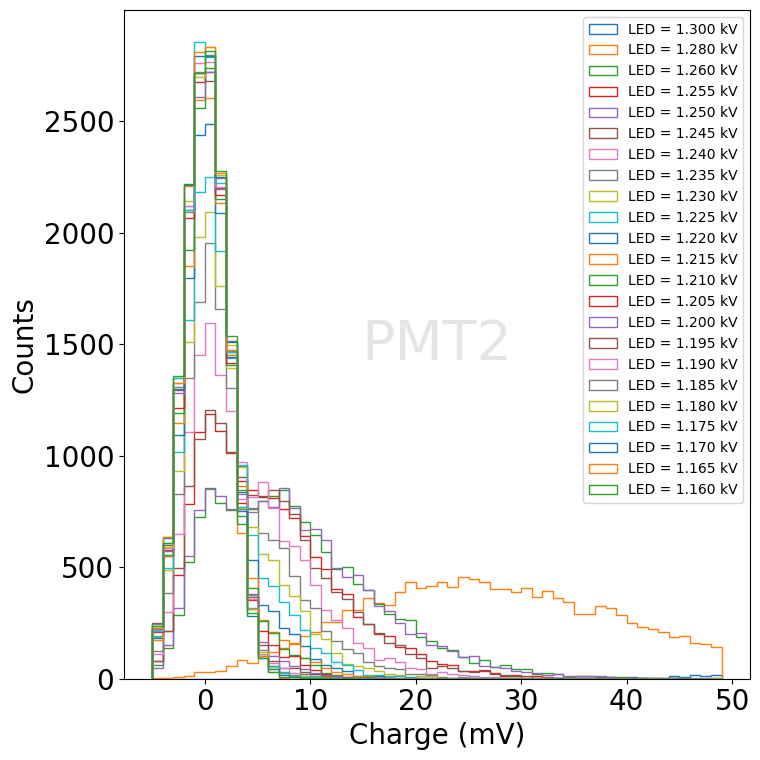

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT2_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT3_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

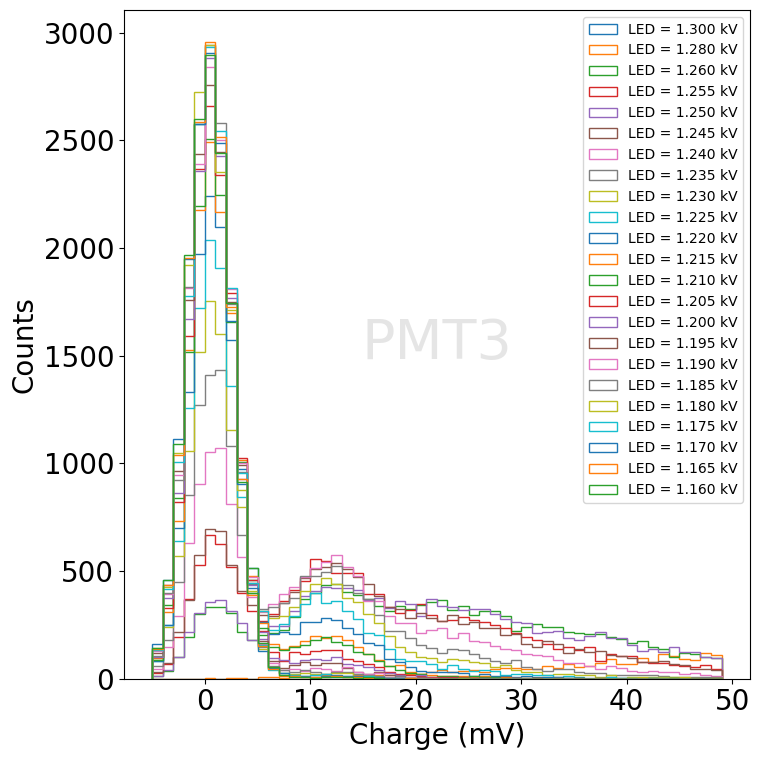

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT3_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT4_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

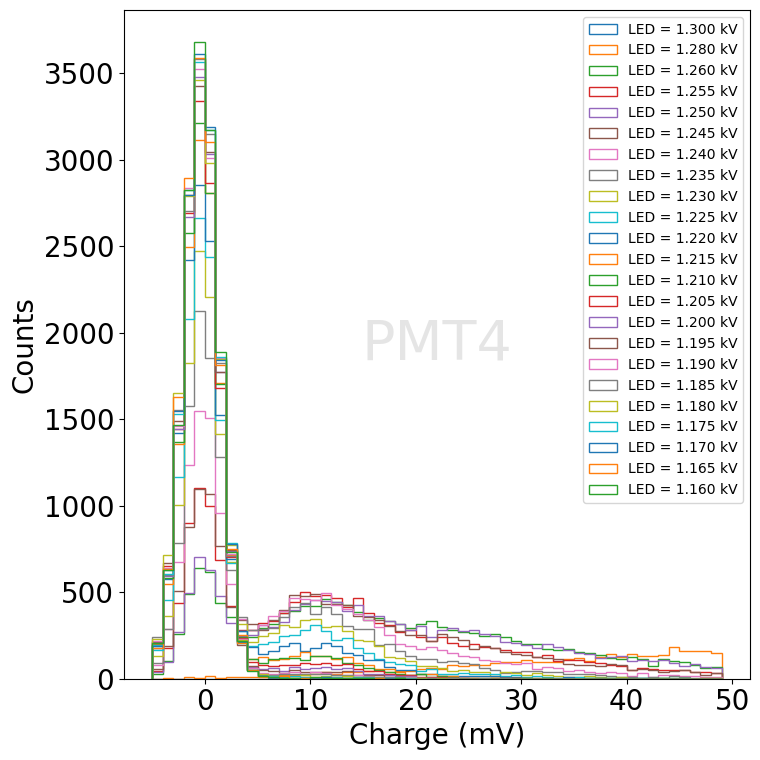

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT4_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT5_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

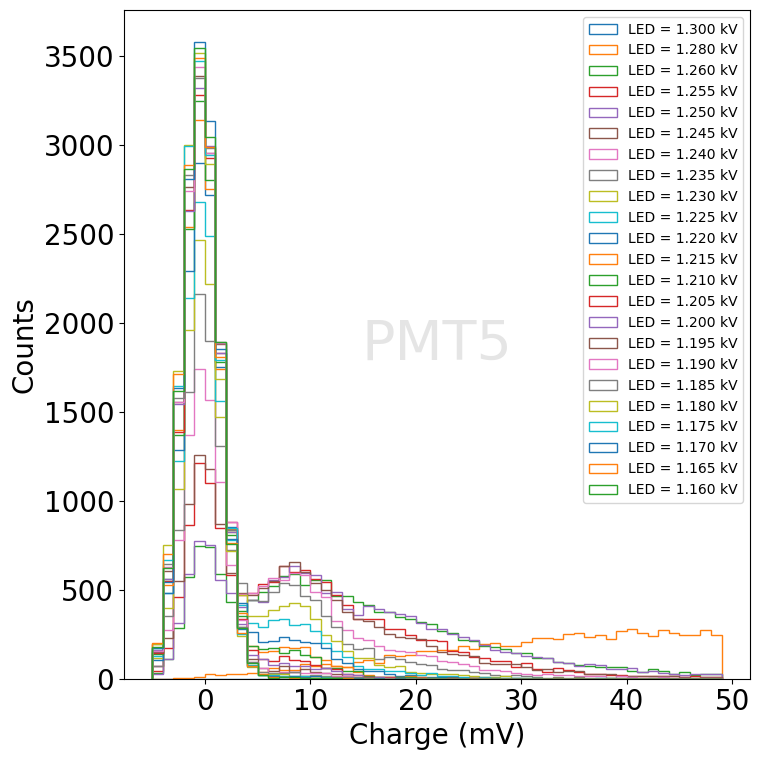

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT5_1248_1266.png
2964 2986
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2965_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2966_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2967_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2968_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2969_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2970_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2971_PMT6_1248_1266.txt
/Users/ldonneger/Desktop/PhD_Thesis2/Ga

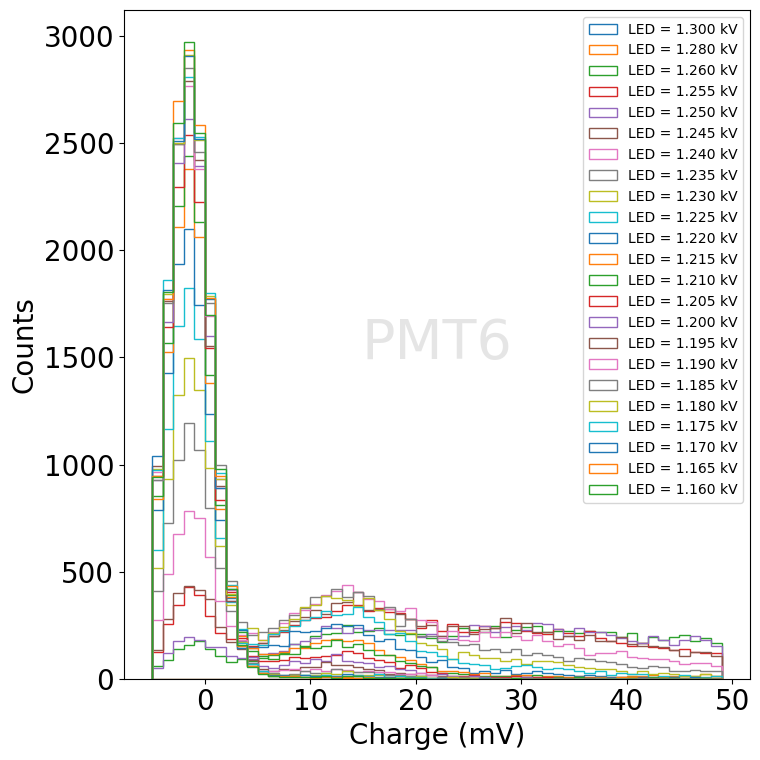

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964-R2986_PMT6_1248_1266.png
2964 2986


In [2033]:
#plot for calibration

data_path = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/"

print(run, pmt, inf, sup)
bins_ = np.arange(-5, 50, 1)
pmts = [0,1,2,3,4,5,6]

### 1.1kV in pmts
#inf = 1249
#sup = 1258
#1249_1258
#run_nb = np.arange(2942, 2964, 1)
#LED_V = [1.32, 1.30, 1.29, 1.285, 1.28, 1.275, 1.27, 1.265, 1.26, 1.255, 1.25, 1.245, 1.24, 1.235, 1.230, 1.225, 1.22, 1.215, 1.210, 1.205, 1.200, 1.195]

### 1.2kV in pmts
#504-507
#run_nb = np.arange(2922, 2942, 1)
#LED_V = [1.30, 1.29, 1.28, 1.27, 1.25, 1.23, 1.22, 1.21, 1.205, 1.20, 1.195, 1.190, 1.185, 1.180, 1.175, 1.170, 1.215, 1.225, 1.235, 1.240]

#1.25kV in pmts
run_nb = np.arange(2964, 2987, 1)
LED_V = [1.30, 1.28, 1.26, 1.255, 1.25, 1.245, 1.24, 1.235, 1.23, 1.225, 1.22, 1.215, 1.21, 1.205, 1.20, 1.195, 1.190, 1.185, 1.180, 1.175, 1.170, 1.165, 1.160]

###scan of pmtv
#run_nb = np.arange(2987, 2999, 1)
#LED_V = [1.250, 1.230, 1.220, 1.210, 1.190, 1.170, 1.150, 1.130, 1.110, 1.090, 1.070, 1.2]

print('LED_V is :',  len(LED_V))
#run_nb = [1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098]
#LED_V = [1.211, 1.209, 1.207, 1.205, 1.203, 1.201, 1.199, 1.198, 1.197, 1.196, 1.195, 1.194, 1.193, 1.192, 1.191, 1.190, 1.189,  1.188, 1.187,  1.186, 1.185, 1.184, 1.183, 1.182, 1.181, 1.180]

LED_V = np.array(LED_V)

LED_V_mk = (LED_V <= 1.4)

LED_V = LED_V[LED_V_mk]
run_nb = run_nb[LED_V_mk]

bin_centers = (bins_[1:] + bins_[:-1])/2
for j in range(len(pmts)):
    plt.figure(figsize=(8, 8))
    for i in range(len(run_nb)):
        
        file = "R"+str(run_nb[i])+"_PMT"+str(pmts[j])+"_"+str(int(inf))+"_"+str(int(sup))
        
        data_file = data_path + file + '.txt'
        print(data_file)
        integral_charge = np.loadtxt(data_file) #* mV_to_Phot
        #print(len(integral_charge))
        integral_sum = np.sum(integral_charge) #* mV_to_AP
        #print(nbr_fpr)
        #print(nbr_wf)
        #print(integral_sum)
        #print(f'The ratio of nb of AP over the nb of events is : {integral_sum}')
        #print(integral_charge)
        
        plt.hist(integral_charge, bins=bins_, density=False, histtype = 'step', label=f'LED = {LED_V[i]:.3f} kV')
        plt.xlabel("Charge (mV)")
        
        
        #plt.xlabel("Number of AP")
        #plt.xlabel("Number of Photons")
        plt.ylabel("Counts")
        plt.legend(fontsize=10)
        plt.tight_layout()
        #plt.yscale('log')
    #plt.ylim(0, 8000)
    xmin, xmax = plt.xlim()
    ymin, ymax = plt.ylim()
    plt.text((xmax+xmin)/2, (ymax+ymin)/2, 'PMT'+str(pmts[j]), fontsize=40, color='gray',
            alpha=0.2, ha='center', va='center', zorder=0)  
    plt.savefig(data_path + 'R'+str(np.min(run_nb))+'-R'+str(np.max(run_nb))+'_PMT'+str(pmts[j])+'_'+str(int(inf))+'_'+str(int(sup))+'.png')
    plt.show()
    
    print(data_path + 'R'+str(np.min(run_nb))+'-R'+str(np.max(run_nb))+'_PMT'+str(pmts[j])+'_'+str(int(inf))+'_'+str(int(sup))+'.png')
    print(np.min(run_nb), np.max(run_nb))
    
pmt_changed = 50   


1.16
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/Fit_R2986_PMT6_1248_1266.png
len data is : 69
len fit is : 69
The ratio A1/A0 is : 0.04204901727852792
The ratio A1/A0 is : 0.04204901727852792
Quality (R2) is : 0.9989477667045854
parameters gauss 1 are :
 amp1   : 1159.6 ± 66.8
 mu1    : -1.56 ± 0.08
 sigma1 : 2.01 ± 0.07

parameters gauss 2 are :
 amp2   : 48.8 ± 1421.0
 mu2    : -22.14 ± 392.26
 sigma2 : 14.65 ± 89.24



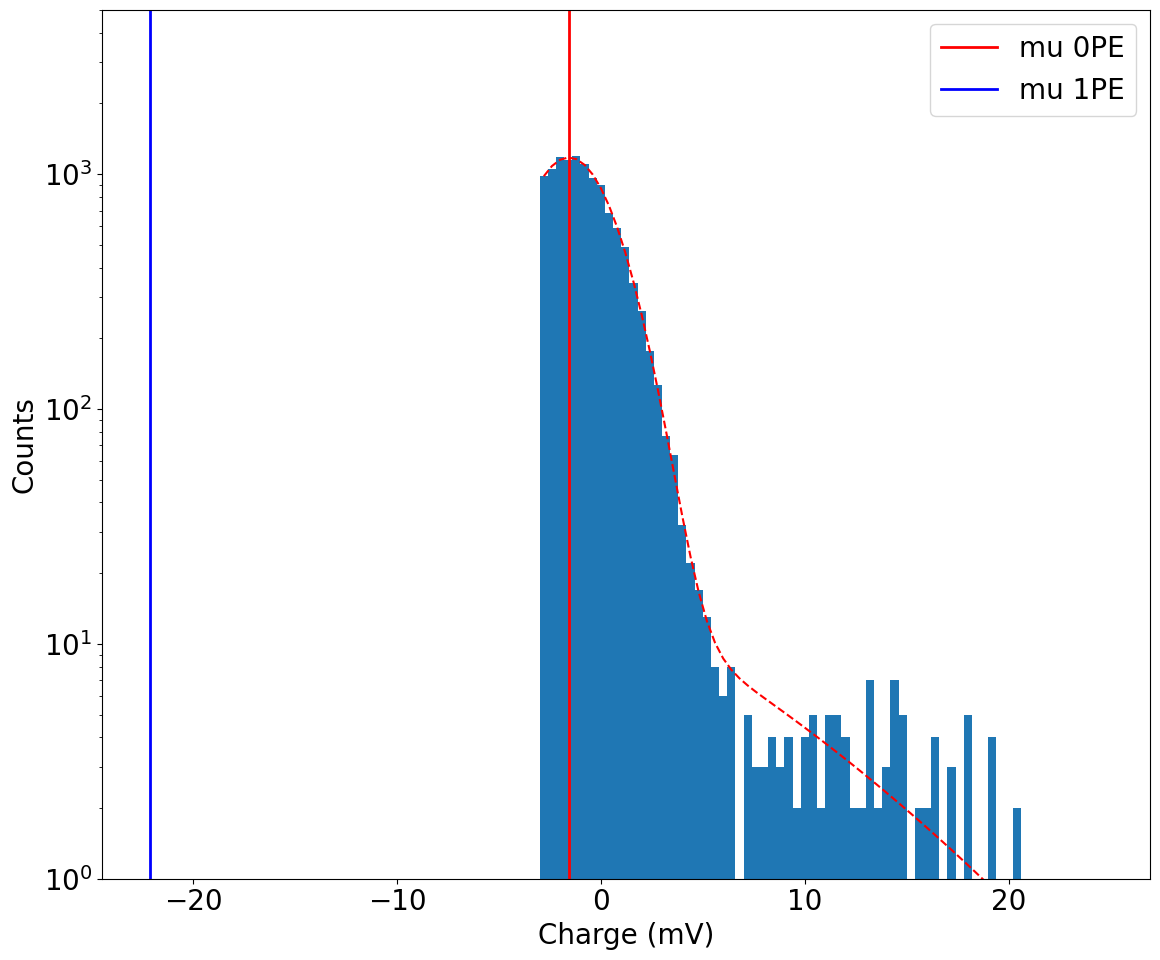

In [2610]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------
# Chargement
# -----------------------
i = 22 #run
j = 6 #pmt
print(LED_V[i])
data_file = data_path + f"R{run_nb[i]}_PMT{pmts[j]}_{int(inf)}_{int(sup)}.txt" 
print(data_path + f"Fit_R{run_nb[i]}_PMT{pmts[j]}_{int(inf)}_{int(sup)}.png")
integral_charge = np.loadtxt(data_file)

bins_ = np.arange(-3, 25, 0.4)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

# -----------------------
# Modèles
# -----------------------
def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2*sigma**2))

def multi_gauss(x, *params):
    y = np.zeros_like(x)
    for k in range(len(params)//3):
        y += gauss(x,
                   params[3*k],
                   params[3*k+1],
                   params[3*k+2])
    return y

# -----------------------
# Histogramme
# -----------------------
y, _, _ = plt.hist(integral_charge, bins=bins_, range=(-5, 60))

# -----------------------
# Choix
# -----------------------
nb_gauss = 2

# guess initial standardisé
p0 = []
for k in range(nb_gauss):
    p0 += [max(y)/(k+1), 12*k, 5]

# -----------------------
# Fit
# -----------------------
popt, pcov = curve_fit(multi_gauss, bin_centers, y, p0=p0, maxfev=5000)
err = np.sqrt(np.diag(pcov))
y_fit = multi_gauss(bin_centers, *popt)
print('len data is :', len(y))
print('len fit is :', len(y_fit))
quality = 1 - np.sum((y - y_fit)**2)/np.sum((y-np.mean(y))**2)

# -----------------------
# Extraction (NOMS CONSERVÉS)
# -----------------------
colors = ["red", "blue", "green", "orange", 'purple']

for k in range(nb_gauss):
    
    locals()[f"amp{k+1}"]      = popt[3*k]
    locals()[f"mu{k+1}"]       = popt[3*k+1]
    locals()[f"sigma{k+1}"]    = popt[3*k+2]

    locals()[f"amp{k+1}_err"]   = err[3*k]
    locals()[f"mu{k+1}_err"]    = err[3*k+1]
    locals()[f"sigma{k+1}_err"] = err[3*k+2]
    
    
    print(f'The ratio A1/A0 is : {popt[3]/popt[0]}')
    #print(f'The ratio A1/A0 is : {popt[3]/popt[0]})

    plt.axvline(locals()[f"mu{k+1}"],
                color=colors[k],
                lw=2,
                label=f"mu {k}PE")

# -----------------------
# Print clean
# -----------------------
print(f'Quality (R2) is : {quality}')
for k in range(nb_gauss):
    print(
        f"parameters gauss {k+1} are :\n"
        f" amp{k+1}   : {locals()[f'amp{k+1}']:.1f} ± {locals()[f'amp{k+1}_err']:.1f}\n"
        f" mu{k+1}    : {locals()[f'mu{k+1}']:.2f} ± {locals()[f'mu{k+1}_err']:.2f}\n"
        f" sigma{k+1} : {locals()[f'sigma{k+1}']:.2f} ± {locals()[f'sigma{k+1}_err']:.2f}\n"
    )

# -----------------------
# Plot final
# -----------------------
plt.plot(bin_centers, y_fit, "r--")

plt.xlabel("Charge (mV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.ylim(1, 5e3)

plt.legend()
plt.tight_layout()

#plt.savefig(data_path + f"Fit_R{run_nb[i]}_PMT{pmts[j]}_{int(inf)}_{int(sup)}.png", dpi=150)
plt.show()

In [2606]:
### If the pmt analysed is changed, the arrays of values are empty, if not, we add values to the array
# Execute only if the fit is good
if (pmt_changed != j):
    
    amp_p0 = []
    err_amp_p0 = []

    amp_p1 = []
    err_amp_p1 = []
    
    amp_p2 = []
    err_amp_p2 = []

    mu_p0 = []
    err_mu_p0 = []

    mu_p1 = []
    err_mu_p1 = []
    
    mu_p2 = []
    err_mu_p2 = []

    sigma_p0 = []
    err_sigma_p0 = []

    sigma_p1 = []
    err_sigma_p1 = []
    
    sigma_p2 = []
    err_sigma_p2 = []

    mu_plot = []
    mu_err_plot = []

    LED_plot = []

else:
    
    amp_p0.append(amp1)
    err_amp_p0.append(amp1_err)

    amp_p1.append(amp2)
    err_amp_p1.append(amp2_err)
    
    mu_p0.append(mu1)
    err_mu_p0.append(mu1_err)

    mu_p1.append(mu2)
    err_mu_p1.append(mu2_err)

    sigma_p0.append(sigma1)
    err_sigma_p0.append(sigma1_err)

    sigma_p1.append(sigma2)
    err_sigma_p1.append(sigma2_err)
   
    #in case we fit the 2pe peak
    if nb_gauss >= 3:
        amp_p2.append(amp3)
        err_amp_p2.append(amp3_err)

        mu_p2.append(mu3)
        err_mu_p2.append(mu3_err)

        sigma_p2.append(sigma3)
        err_sigma_p2.append(sigma3_err)
    else:
        amp_p2.append(np.nan)
        err_amp_p2.append(np.nan)

        mu_p2.append(mu2*2)
        err_mu_p2.append(2*mu2_err)

        sigma_p2.append(np.sqrt(2)*sigma2)
        err_sigma_p2.append(np.sqrt(2)*sigma2_err)

    mu_plot = []
    mu_err_plot = []

    LED_plot.append(LED_V[i])
    
pmt_changed = j
print("last i values tested is : ", i)
print("nb of fitting saved : ", len(LED_plot))
print("value of pmt_changed : ", pmt_changed)

last i values tested is :  19
nb of fitting saved :  16
value of pmt_changed :  6


In [2611]:
#to store the parameters of p0 and p1 fit
#execute only if all the runs have been analysed for 1 PMT

file_param = "R"+str(np.min(run_nb))+"_R"+str(np.max(run_nb))+"_PMT"+str(pmts[j])+"_calib_param_all_fit_1PE."

for nb_fit in range(len(LED_plot)):
    
    with open(data_path + file_param + 'txt' , "a", encoding="utf-8") as f:
        
        f.write(f"{LED_plot[nb_fit]}\t{amp_p0[nb_fit]:.18e}\t{err_amp_p0[nb_fit]:.18e}\t{mu_p0[nb_fit]:.18e}\t{err_mu_p0[nb_fit]:.18e}\t{sigma_p0[nb_fit]:.18e}\t{err_sigma_p0[nb_fit]:.18e}\t{amp_p1[nb_fit]:.18e}\t{err_amp_p1[nb_fit]:.18e}\t{mu_p1[nb_fit]:.18e}\t{err_mu_p1[nb_fit]:.18e}\t{sigma_p1[nb_fit]:.18e}\t{err_sigma_p1[nb_fit]:.18e}\t{amp_p2[nb_fit]:.18e}\t{err_amp_p2[nb_fit]:.18e}\t{mu_p2[nb_fit]:.18e}\t{err_mu_p2[nb_fit]:.18e}\t{sigma_p2[nb_fit]:.18e}\t{err_sigma_p2[nb_fit]:.18e}\n")

print(data_path + file_param + 'txt')   

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_R2986_PMT6_calib_param_all_fit_1PE.txt


[1.3   1.28  1.26  1.255 1.25  1.245 1.24  1.235 1.23  1.225 1.22  1.215
 1.21  1.205 1.2   1.195 1.19  1.185 1.18  1.175 1.17  1.165 1.16 ]
10.5
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2964_R2986_PMT6_calib_param_all_fit_1PE.png


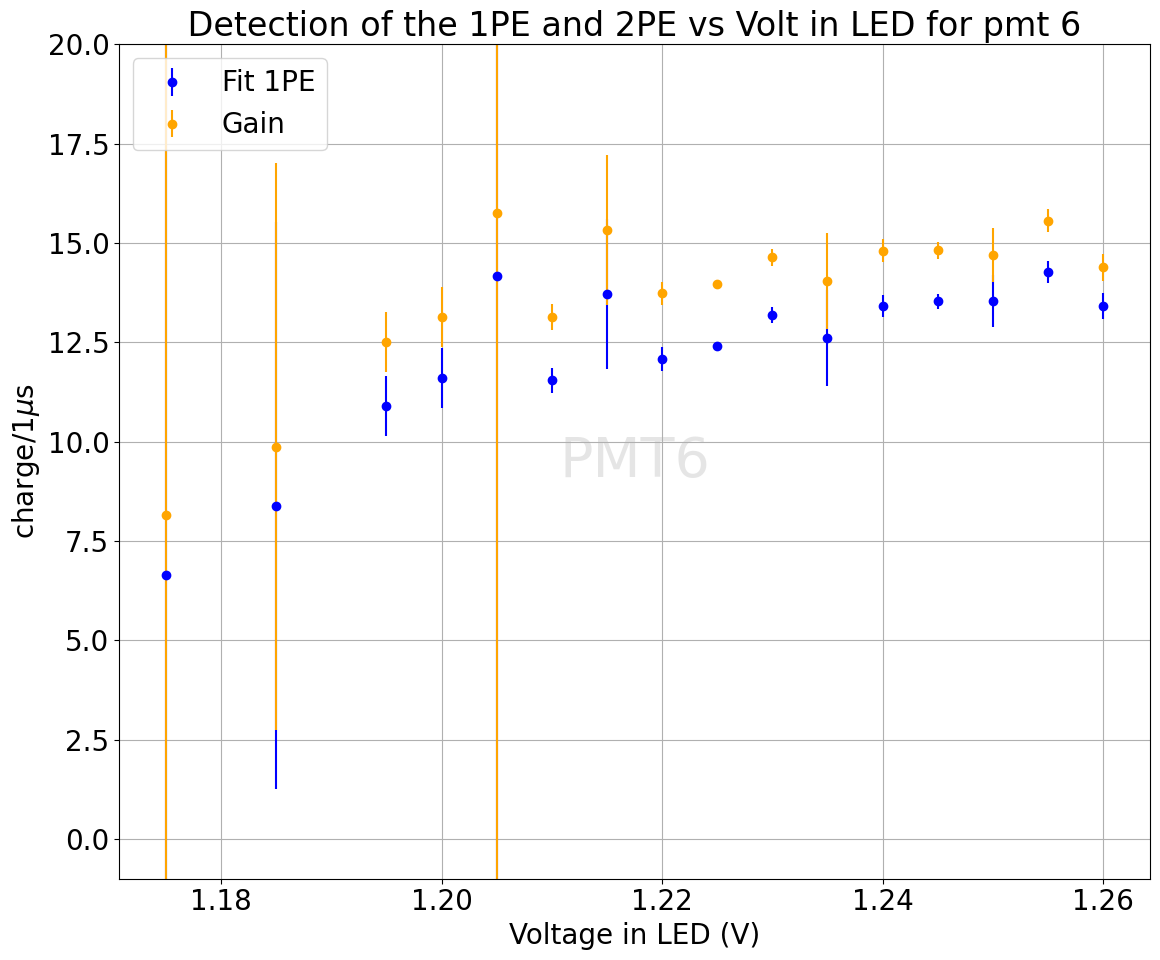

In [2617]:
plt.errorbar(LED_plot, mu_p1, yerr=err_mu_p1, fmt="o", color='blue', label="Fit 1PE") 
mu_p0 = np.array(mu_p0)
mu_p1 = np.array(mu_p1)
err_mu_p0 = np.array(err_mu_p0)
err_mu_p1 = np.array(err_mu_p1)
mu_p2 = np.array(mu_p2)
err_mu_p2 = np.array(err_mu_p2)

#plt.errorbar(LED_plot, mu_p2, yerr=err_mu_p2, fmt="o", color='red', label="2PE (Fit or obtained from 1PE)") 
plt.errorbar(LED_plot, mu_p1 - mu_p0, yerr=np.sqrt(err_mu_p0**2 + err_mu_p1**2), fmt="o", color='orange', label="Gain") 

print(LED_V)
#plt.xlabel('Voltage in LED (V)')
plt.xlabel('Voltage in LED (V)')
plt.ylabel(f'charge/{size_int_window}$\mu$s')

#plt.xlim(np.min(LED_V) - 0.01, np.max(LED_V) + 0.01)
#plt.xlim(, 1.24)
plt.ylim(-1, 20)
plt.title(f' Detection of the 1PE and 2PE vs Volt in LED for pmt '+str(pmts[j])+' ')
plt.legend(loc='upper left')
ymax = plt.ylim()[1]
ymin = plt.ylim()[0]
xmax = plt.xlim()[1]
xmin = plt.xlim()[0]
print((ymax-ymin)/2)
plt.text(xmax - (xmax-xmin)/2, ymax - (ymax-ymin)/2, 'PMT'+str(pmts[j]), fontsize=40, color='gray', alpha=0.2, ha='center', va='center', zorder=0)
plt.tight_layout()
plt.grid(True)
plt.savefig(data_path + file_param + 'png', dpi=300, bbox_inches='tight')
print(data_path + file_param + 'png')
plt.show()

In [2026]:
#read in the stored parameters for each pmts
#usefull to select the param values for calib directly from files
#watch at the plots and select the voltage you want for each pmts as an input here

#f.write(f"fit P0 : {LED_plot[nb_fit]}\t{amp_p0[nb_fit]:.18e}\t{err_amp_p0[nb_fit]:.18e}\t{mu_p0[nb_fit]:.18e}\t{err_mu_p0[nb_fit]:.18e}\t{sigma_p0[nb_fit]:.18e}\t{err_sigma_p0[nb_fit]:.18e}\n")
#f.write(f"fit p1 : {LED_plot[nb_fit]}\t{amp_p1[nb_fit]:.18e}\t{err_amp_p1[nb_fit]:.18e}\t{mu_p1[nb_fit]:.18e}\t{err_mu_p1[nb_fit]:.18e}\t{sigma_p1[nb_fit]:.18e}\t{err_sigma_p1[nb_fit]:.18e}\n")
#inf = 1400
#sup = 1430
pmts = [0, 1, 2, 3, 4, 5, 6]
#run_nb = [2453, 2454, 2455, 2456, 2457, 2458, 2459]
LED_V_sel = [1.215, 1.2, 1.225, 1.2, 1.2, 1.205, 1.21]
stored_values = []
dst_calib_stored = pd.DataFrame({})
for pmt_sel in range(len(pmts)):

    file_param = "R"+str(np.min(run_nb))+"_R"+str(np.max(run_nb))+"_PMT"+str(pmts[pmt_sel])+"_calib_param_all_fit_1PE."
    
    dst_calib = pd.read_csv(data_path + file_param + 'txt', delim_whitespace=True, header=None, names=['LED_V', 'amp_p0', 'err_amp_p0', 'mu_p0', 'err_mu_p0', 'sigma_p0', 'err_sigma_p0', 'amp_p1', 'err_amp_p1', 'mu_p1', 'err_mu_p1', 'sigma_p1', 'err_sigma_p1', 'amp_p2', 'err_amp_p2', 'mu_p2', 'err_mu_p2', 'sigma_p2', 'err_sigma_p2'])
    print(data_path + file_param + 'txt')
    #print(dst_calib)
    stored_values = dst_calib[(dst_calib['LED_V'] == LED_V_sel[pmt_sel])]
    dst_calib_stored = pd.concat([dst_calib_stored , stored_values], ignore_index=True)
    #print(dst_calib_stored)
    
dst_calib_file = pd.DataFrame({})
dst_calib_file = dst_calib_stored[['amp_p0', 'err_amp_p0', 'mu_p0', 'err_mu_p0', 'sigma_p0', 'err_sigma_p0', 'amp_p1', 'err_amp_p1', 'mu_p1', 'err_mu_p1', 'sigma_p1', 'err_sigma_p1', 'amp_p2', 'err_amp_p2', 'mu_p2', 'err_mu_p2', 'sigma_p2', 'err_sigma_p2']]
#print(dst_calib_file)
print(dst_calib_file)
dst_calib_file.to_csv(data_path + 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_2PEfit_1.2kV_in_pmts.txt', index=False, header=False, sep="\t")
print(data_path + 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_2PEfit_1.2kV_in_pmts.txt')
    

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT0_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT1_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT2_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT3_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT4_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT5_calib_param_all_fit_1PE.txt
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/27-01-2026/R2922_R2941_PMT6_calib_param_all_fit_1PE.txt
        amp_p0  err_amp_p0     mu_p0  err_mu_p0  sigma_p0  err_sigma_p0  \
0   937.775004  151.247922  1.224019   0.080525  2

In [455]:
#To store only the fitting parameters that will be used to update the calib values
#It creates the file that is usefull as an input for the updating calib values process (in CreatePlote_and_updateDB_conf.ipynb)

mask_store = (LED_plot == 1.24) #change the value for the one you want to save 

file_param_store = 'calibrun_'+str(np.min(run_nb))+'-'+str(np.max(run_nb))+'_parameters_1PEfit.'
    
with open(data_path + file_param_store + 'txt' , "a", encoding="utf-8") as f:

    f.write(f"{amp_p0[mask_store]:.18e}\t{err_amp_p0[mask_store]:.18e}\t{mu_p0[mask_store]:.18e}\t{err_mu_p0[mask_store]:.18e}\t{sigma_p0[mask_store]:.18e}\t{err_sigma_p0[mask_store]:.18e}\t{amp_p1[mask_store]:.18e}\t{err_amp_p1[mask_store]:.18e}\t{mu_p1[mask_store]:.18e}\t{err_mu_p1[mask_store]:.18e}\t{sigma_p1[mask_store]:.18e}\t{err_sigma_p1[mask_store]:.18e}\n")
    
print(data_path + file_param_store + 'txt') 

/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/calibrun_2436-2443_parameters_1PEfit.txt


1.18
/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/01-07-2024/R1098_PMT6_239_259.txt
val max is : 7.069392600002857
parameters gauss 1 are : amp1 : 637.2680962371513 +/- 6.205996438179332 
 mu1 : 0.48219179457898986 +/- 0.0216914145689166 
 sigma1 : 2.5518201217552448 +/- 0.02599017096091533 

parameters gauss 2 are : amp2 : 144.1759958759562 +/- 16.131688593830525 
 mu2 : 12.542354630365482 +/- 0.5062248922190881 
 sigma2 : 6.513428579675259 +/- 0.5490406617925171 
parameters gauss 3 are : amp3 : 24.235691485161116 +/- 7.851116919402299 
 mu3 : 27.945947136609725 +/- 7.279553960736412 
 sigma3 : 9.523498493116684 +/- 3.915217608490357 


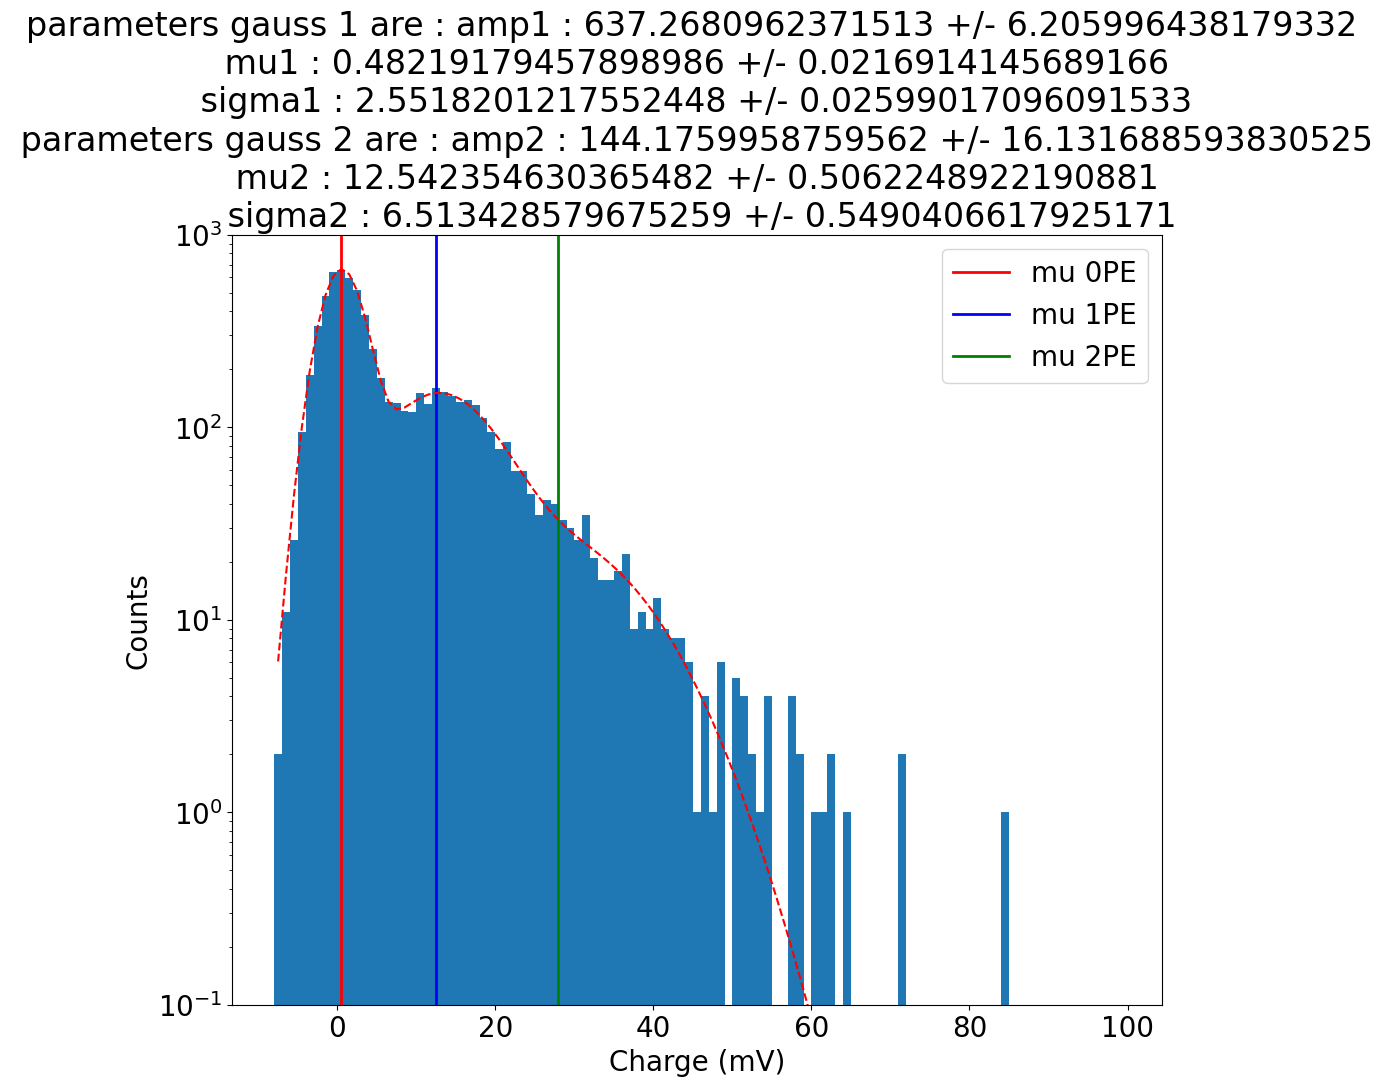

In [157]:
# to do gaussian fittings

data_path = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/"

pmts = [0,1,2,3,4,5,6]
#LED_V = [ 1.30, 1.24, 1.23, 1.22, 1.21, 1.20, 1.19]
#run_nb = [ 2453, 2454, 2455, 2456, 2457, 2458, 2459]
#LED_V = [1.32, 1.30, 1.28, 1.26, 1.24, 1.22, 1.20, 1.18]
#run_nb = [2436, 2437, 2438, 2438, 2440, 2441, 2442, 2443]

i = 6
j = 6 #pmt nb
print(f'{LED_V[i]}')
data_file = data_path + "R"+str(run_nb[i])+"_PMT"+str(pmts[j])+"_"+str(inf)+"_"+str(sup)+".txt"
print(data_file)
integral_charge = np.loadtxt(data_file)
#pmt = 0

bins_ = np.arange(-8, 100, 1)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def two_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2))

def three_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2) +
            gauss(x, amp3, mu3, sigma3))

def four_gauss(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3, amp4, mu4, sigma4):
    return (gauss(x, amp1, mu1, sigma1) + 
            gauss(x, amp2, mu2, sigma2) +
            gauss(x, amp3, mu3, sigma3) +
            gauss(x, amp4, mu4, sigma4) )



n, bins, patches = plt.hist(integral_charge, bins=bins_, range=(-5, 60))
print(f'val max is : {np.mean(integral_charge)}')
#plt.axvline(np.mean(integral_charge), color='green', linestyle='-', linewidth=2, label='mean data')
y = n

nb_gauss = 3

if nb_gauss == 1:
    
    #p0 = (200, 0, 5) #2gauss
    p0 = (400, 250, 200)
    popt, pcov = curve_fit(gauss, bin_centers, y, p0=p0)
    y_fit = gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')


if nb_gauss == 2:
    
    p0 = (4000, 0, 5, 2000, 100, 50) #2gauss
    popt, pcov = curve_fit(two_gauss, bin_centers, y, p0=p0)
    y_fit = two_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')

    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='blue', linestyle='-', linewidth=2, label='mu 1PE')
    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')

    
if nb_gauss == 3:
    
    p0 = (10000, 0, 5, 1000, 16, 5, 100, 50, 5) #3gauss
    popt, pcov = curve_fit(three_gauss, bin_centers, y, p0=p0)
    y_fit = three_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 0PE')
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='blue', linestyle='-', linewidth=2, label='mu 1PE')

    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    amp3 = popt[6]
    mu3 = popt[7]
    sigma3 = popt[8]
    
    plt.axvline(mu3, color='green', linestyle='-', linewidth=2, label='mu 2PE')

    
    amp3_err = err[6]
    mu3_err = err[7]
    sigma3_err = err[8]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')
    print(f'parameters gauss 3 are : amp3 : {amp3} +/- {amp3_err} \n mu3 : {mu3} +/- {mu3_err} \n sigma3 : {sigma3} +/- {sigma3_err} ')
                     
if nb_gauss == 4:
                           
    p0 = (5000, 0, 5, 1000, 16, 5, 500, 27, 5, 200, 45, 5) #4gauss 
    popt, pcov = curve_fit(four_gauss, bin_centers, y, p0=p0)
    y_fit = four_gauss(bin_centers, *popt)
    err = np.sqrt(np.diag(pcov))
    
    err = np.sqrt(np.diag(pcov))
    
    amp1 = popt[0]
    mu1 = popt[1]
    sigma1 = popt[2]
    
    plt.axvline(mu1, color='red', linestyle='-', linewidth=2, label='mu 1PE')
    
    amp1_err = err[0]
    mu1_err = err[1]
    sigma1_err = err[2]
    
    amp2 = popt[3]
    mu2 = popt[4]
    sigma2 = popt[5]
    
    plt.axvline(mu2, color='red', linestyle='-', linewidth=2, label='mu 2PE')

    
    amp2_err = err[3]
    mu2_err = err[4]
    sigma2_err = err[5]
    
    amp3 = popt[6]
    mu3 = popt[7]
    sigma3 = popt[8]
    
    plt.axvline(mu3, color='red', linestyle='-', linewidth=2, label='mu 3PE')

    
    amp3_err = err[6]
    mu3_err = err[7]
    sigma3_err = err[8]
    
    amp4 = popt[9]
    mu4 = popt[10]
    sigma4 = popt[11]
    
    plt.axvline(mu4, color='red', linestyle='-', linewidth=2, label='mu 4PE')

    
    amp4_err = err[9]
    mu4_err = err[10]
    sigma4_err = err[11]
    
    print(f'parameters gauss 1 are : amp1 : {amp1} +/- {amp1_err} \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n')
    print(f'parameters gauss 2 are : amp2 : {amp2} +/- {amp2_err} \n mu2 : {mu2} +/- {mu2_err} \n sigma2 : {sigma2} +/- {sigma2_err} ')
    print(f'parameters gauss 3 are : amp3 : {amp3} +/- {amp3_err} \n mu3 : {mu3} +/- {mu3_err} \n sigma3 : {sigma3} +/- {sigma3_err} ')
    print(f'parameters gauss 4 are : amp3 : {amp4} +/- {amp4_err} \n mu4 : {mu4} +/- {mu4_err} \n sigma4 : {sigma4} +/- {sigma4_err} ')
                 

plt.plot(bin_centers, y_fit, color='r', linestyle='dashed')

plt.xlabel('Charge (mV)')
#plt.xlabel('Nb of AP')

plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, 1e3)
plt.title('parameters gauss 1 are : amp1 : '+str(amp1)+' +/- '+str(amp1_err)+' \n mu1 : '+str(mu1)+' +/- '+str(mu1_err)+' \n sigma1 : '+str(sigma1)+' +/- '+str(sigma1_err)+' \n parameters gauss 2 are : amp2 : '+str(amp2)+' +/- '+str(amp2_err)+' \n mu2 : '+str(mu2)+' +/- '+str(mu2_err)+' \n sigma2 : '+str(sigma2)+' +/- '+str(sigma2_err))
#plt.figtext(0.5, -0.05, 'parameters gauss 1 are : amp1 : '+str(amp1)+' +/- '+str(amp1_err)+' \n mu1 : {mu1} +/- {mu1_err} \n sigma1 : {sigma1} +/- {sigma1_err} \n', ha='center', fontsize=12)
plt.legend()
plt.savefig(data_path + 'Fit_R'+str(run_nb[i])+'_PMT'+str(pmts[j])+'_'+str(inf)+'_'+str(sup)+'.png', bbox_inches='tight')
plt.show()







1.175
len data is : 69
len fit is : 69
The ratio A1/A0 is : 0.014310187465703382
The ratio A1/A0 is : 0.014310187465703382
Quality (R2) is : 0.9977883472885589
parameters gauss 1 are :
 amp1   : 1702.5 ± 21.9
 mu1    : 1.28 ± 0.03
 sigma1 : 1.71 ± 0.03

parameters gauss 2 are :
 amp2   : 24.4 ± 7.0
 mu2    : 7.65 ± 1.84
 sigma2 : 2.29 ± 1.08



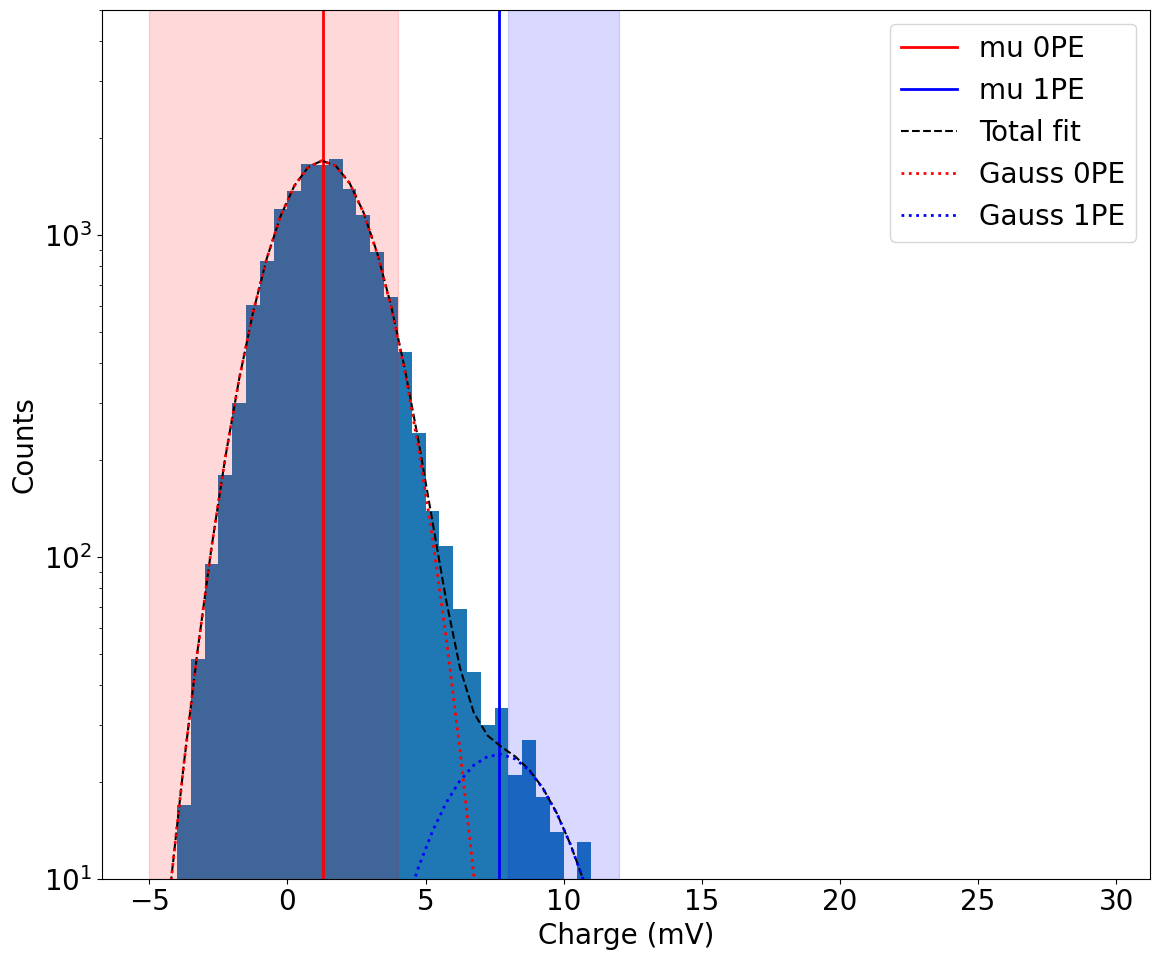

In [1618]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------
# Chargement
# -----------------------

print(LED_V[i])
data_file = data_path + f"R{run_nb[i]}_PMT{pmts[j]}_{int(inf)}_{int(sup)}.txt" 
integral_charge = np.loadtxt(data_file)

bins_ = np.arange(-5, 30, 0.5)
bin_centers = (bins_[1:] + bins_[:-1]) / 2

# -----------------------
# Modèles
# -----------------------
def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2*sigma**2))

def multi_gauss(x, *params):
    y = np.zeros_like(x)
    for k in range(len(params)//3):
        y += gauss(x,
                   params[3*k],
                   params[3*k+1],
                   params[3*k+2])
    return y

# -----------------------
# Histogramme
# -----------------------
y, _, _ = plt.hist(integral_charge, bins=bins_, range=(-5, 60))

# -----------------------
# Choix
# -----------------------
nb_gauss = 2

# guess initial standardisé
p0 = []
for k in range(nb_gauss):
    p0 += [max(y)/(k+1), 12*k, 5]

# -----------------------
# WINDOWS
# -----------------------
fit_windows = [
    (-5, 4),    # 0PE
    (8, 12)     # 1PE
]

# -----------------------
# Fit indépendants
# -----------------------
popt = []
err = []

y_fit = np.zeros_like(bin_centers)

for k in range(nb_gauss):
    
    mask = (bin_centers > fit_windows[k][0]) & (bin_centers < fit_windows[k][1])
    xw = bin_centers[mask]
    yw = y[mask]
    
    p0_k = p0[3*k:3*k+3]
    
    popt_k, pcov_k = curve_fit(gauss, xw, yw, p0=p0_k, maxfev=5000)
    err_k = np.sqrt(np.diag(pcov_k))
    
    popt += list(popt_k)
    err  += list(err_k)
    
    y_fit += gauss(bin_centers, *popt_k)

popt = np.array(popt)
err  = np.array(err)

print('len data is :', len(y))
print('len fit is :', len(y_fit))
quality = 1 - np.sum((y - y_fit)**2)/np.sum((y-np.mean(y))**2)

# -----------------------
# Extraction (NOMS CONSERVÉS)
# -----------------------
colors = ["red", "blue", "green", "orange"]

for k in range(nb_gauss):
    
    locals()[f"amp{k+1}"]      = popt[3*k]
    locals()[f"mu{k+1}"]       = popt[3*k+1]
    locals()[f"sigma{k+1}"]    = popt[3*k+2]

    locals()[f"amp{k+1}_err"]   = err[3*k]
    locals()[f"mu{k+1}_err"]    = err[3*k+1]
    locals()[f"sigma{k+1}_err"] = err[3*k+2]
    
    print(f'The ratio A1/A0 is : {popt[3]/popt[0]}')

    plt.axvline(locals()[f"mu{k+1}"],
                color=colors[k],
                lw=2,
                label=f"mu {k}PE")

# -----------------------
# Print clean
# -----------------------
print(f'Quality (R2) is : {quality}')
for k in range(nb_gauss):
    print(
        f"parameters gauss {k+1} are :\n"
        f" amp{k+1}   : {locals()[f'amp{k+1}']:.1f} ± {locals()[f'amp{k+1}_err']:.1f}\n"
        f" mu{k+1}    : {locals()[f'mu{k+1}']:.2f} ± {locals()[f'mu{k+1}_err']:.2f}\n"
        f" sigma{k+1} : {locals()[f'sigma{k+1}']:.2f} ± {locals()[f'sigma{k+1}_err']:.2f}\n"
    )

# -----------------------
# Plot final
# -----------------------

# somme
plt.plot(bin_centers, y_fit, "k--", label="Total fit")

# gaussiennes séparées (NOUVEAU)
plt.plot(bin_centers,
         gauss(bin_centers, amp1, mu1, sigma1),
         "r:", lw=2, label="Gauss 0PE")

plt.plot(bin_centers,
         gauss(bin_centers, amp2, mu2, sigma2),
         "b:", lw=2, label="Gauss 1PE")

# fenêtres
for k in range(nb_gauss):
    plt.axvspan(fit_windows[k][0],
                fit_windows[k][1],
                color=colors[k],
                alpha=0.15)

plt.xlabel("Charge (mV)")
plt.ylabel("Counts")
plt.yscale("log")
plt.ylim(10, 5e3)

plt.legend()
plt.tight_layout()
plt.savefig(data_path + f"Fit_R{run_nb[i]}_PMT{pmts[j]}_{int(inf)}_{int(sup)}.png", dpi=150)
plt.show()


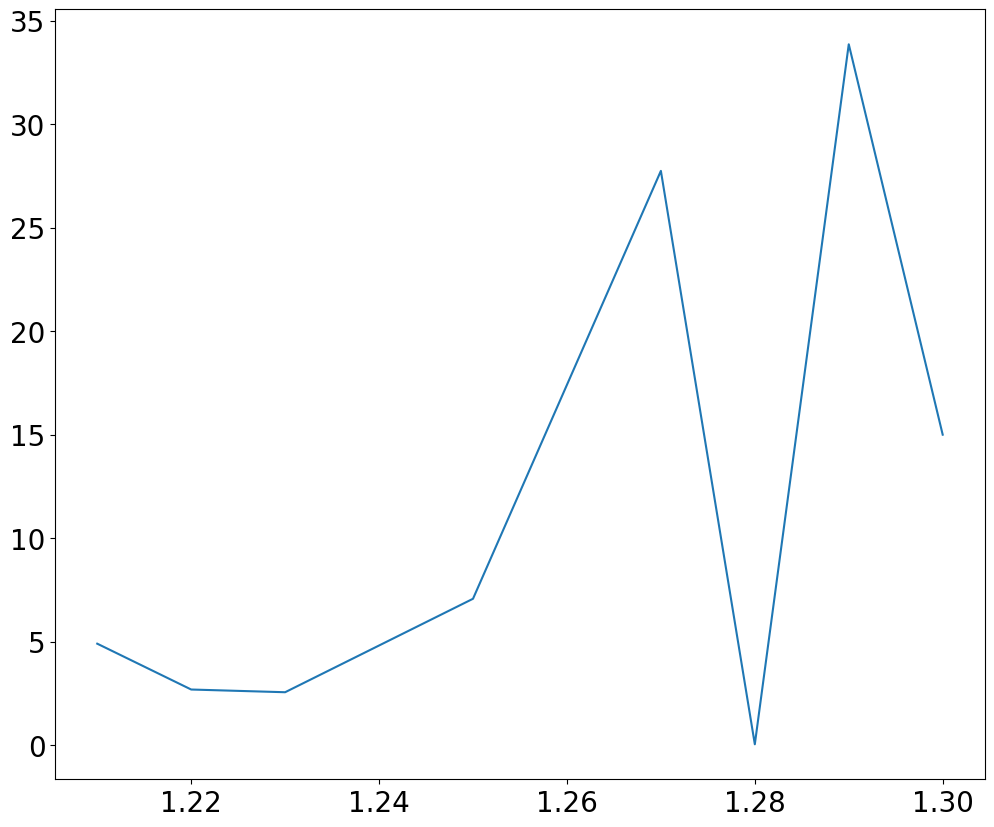

In [105]:
pmt0 = df[df['pmt'] == 3]
mu1 = pmt0['mu1']
mu0 = pmt0['mu0']
plt.plot(LED_V, mu1-mu0)

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os

# -----------------------
# Paramètres globaux
# -----------------------
data_path = "/Users/ldonneger/Desktop/PhD_Thesis2/GanEss/analyse/calib/store_data/"+str(date_folder)+"/"
pmts = [0,1,2,3,4,5,6]

nb_peaks = 3
use_constrained = False   # switch ici

bins_ = np.arange(-8, 40, 1)

# -----------------------
# Modèles
# -----------------------
def gauss(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def n_gauss(x, *params):
    n = len(params)//3
    y = np.zeros_like(x)
    for i in range(n):
        y += gauss(x,
                   params[3*i],
                   params[3*i+1],
                   params[3*i+2])
    return y

def constrained_n_gauss(x, A0, mu0, sigma0, gain, *amps):
    y = gauss(x, A0, mu0, sigma0)
    for i, A in enumerate(amps):
        y += gauss(x, A, mu0 + (i+1)*gain, sigma0)
    return y

# -----------------------
# Fit d'un couple (run, PMT)
# -----------------------
def fit_one(run, pmt, make_plot=True):
    
    file = data_path + f"R{run}_PMT{pmt}_{inf}_{sup}.txt"
    
    if not os.path.exists(file):
        return None
    
    try:
        data = np.loadtxt(file)
        y, bins = np.histogram(data, bins=bins_)
        x = (bins[1:] + bins[:-1]) / 2
        
        # guess initial
        if not use_constrained:
            p0 = []
            for k in range(nb_peaks):
                p0 += [max(y)/(k+1), 15*k, 5]
            model = n_gauss
        else:
            p0 = [max(y), 0, 5, 15]
            for k in range(nb_peaks-1):
                p0 += [max(y)/(k+2)]
            model = constrained_n_gauss
        
        popt, pcov = curve_fit(model, x, y, p0=p0, maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        y_fit = model(x, *popt)
        
        # ---------- Plot optionnel ----------
        if make_plot:
            print('enter')
            plt.figure(figsize=(7,5))
            plt.hist(data, bins=bins_, alpha=0.6, label="Data")
            plt.plot(x, y_fit, "r--", lw=2)
            plt.yscale("log")
            plt.ylim(0.1, 1e4)
            plt.xlabel("Charge (mV)")
            plt.ylabel("Counts")
            plt.title(f"Run {run} - PMT {pmt}")
            plt.tight_layout()
            plt.show()
        #plt.savefig(data_path + f"Fit_R{run}_PMT{pmt}_{inf}_{sup}.png", dpi=120)
        #plt.close()
        
        # ---------- Stockage ----------
        result = {
            "run": run,
            "pmt": pmt
        }
        
        if not use_constrained:
            for k in range(nb_peaks):
                result[f"A{k}"]  = popt[3*k]
                result[f"mu{k}"] = popt[3*k+1]
                result[f"s{k}"]  = popt[3*k+2]
                
                result[f"dA{k}"]  = perr[3*k]
                result[f"dmu{k}"] = perr[3*k+1]
                result[f"ds{k}"]  = perr[3*k+2]
        
        else:
            result["A0"]     = popt[0]
            result["mu0"]    = popt[1]
            result["sigma"]  = popt[2]
            result["gain"]   = popt[3]
            
            result["dA0"]    = perr[0]
            result["dmu0"]   = perr[1]
            result["dsigma"] = perr[2]
            result["dgain"]  = perr[3]
            
            for i in range(nb_peaks-1):
                result[f"A{i+1}"]  = popt[4+i]
                result[f"dA{i+1}"] = perr[4+i]
        
        return result
    
    except Exception as e:
        print(f"Fit failed for Run {run} PMT {pmt}")
        return None

# -----------------------
# Boucle globale
# -----------------------
results = []

for run in run_nb:
    for pmt in pmts:
        res = fit_one(run, pmt, make_plot=False)
        if res is not None:
            results.append(res)

# -----------------------
# Sauvegarde finale
# -----------------------
df = pd.DataFrame(results)
#df.to_csv(data_path + "fit_results.csv", index=False)

print("===================================")
print("FITS RÉUSSIS :", len(df))
print(df.head(50))
print("Sauvegardé dans fit_results.csv")


/opt/anaconda3/envs/IC-3.8-2024-06-08/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/var/folders/7q/bbp3jg1j5zl4p9rh_lhk7rzh0000gn/T/ipykernel_31903/3040766769.py:68: RuntimeWarning: invalid value encountered in sqrt
  perr = np.sqrt(np.diag(pcov))


Fit failed for Run 2923 PMT 5
Fit failed for Run 2923 PMT 6
Fit failed for Run 2924 PMT 1
Fit failed for Run 2926 PMT 1
Fit failed for Run 2927 PMT 2
FITS RÉUSSIS : 51
     run  pmt           A0        mu0         s0           dA0          dmu0  \
0   2922    0     0.000000   0.000000   5.000000           inf           inf   
1   2922    1     0.000000   0.000000   5.000000           inf           inf   
2   2922    2    -0.856095  15.614649   4.205992  1.523833e+00  9.028359e+00   
3   2922    3     0.000000   0.000000   5.000000           inf           inf   
4   2922    4     0.000000   0.000000   5.000000           inf           inf   
5   2922    5     0.000002  -0.650177   5.708302  2.361930e-01  7.356998e+04   
6   2922    6     0.000000   0.000000   5.000000           inf           inf   
7   2923    0     1.904613  10.500019   0.117724  1.109952e+08  4.504410e+10   
8   2923    1     0.000000   0.000000   5.000000           inf           inf   
9   2923    2  -235.250382  18.8

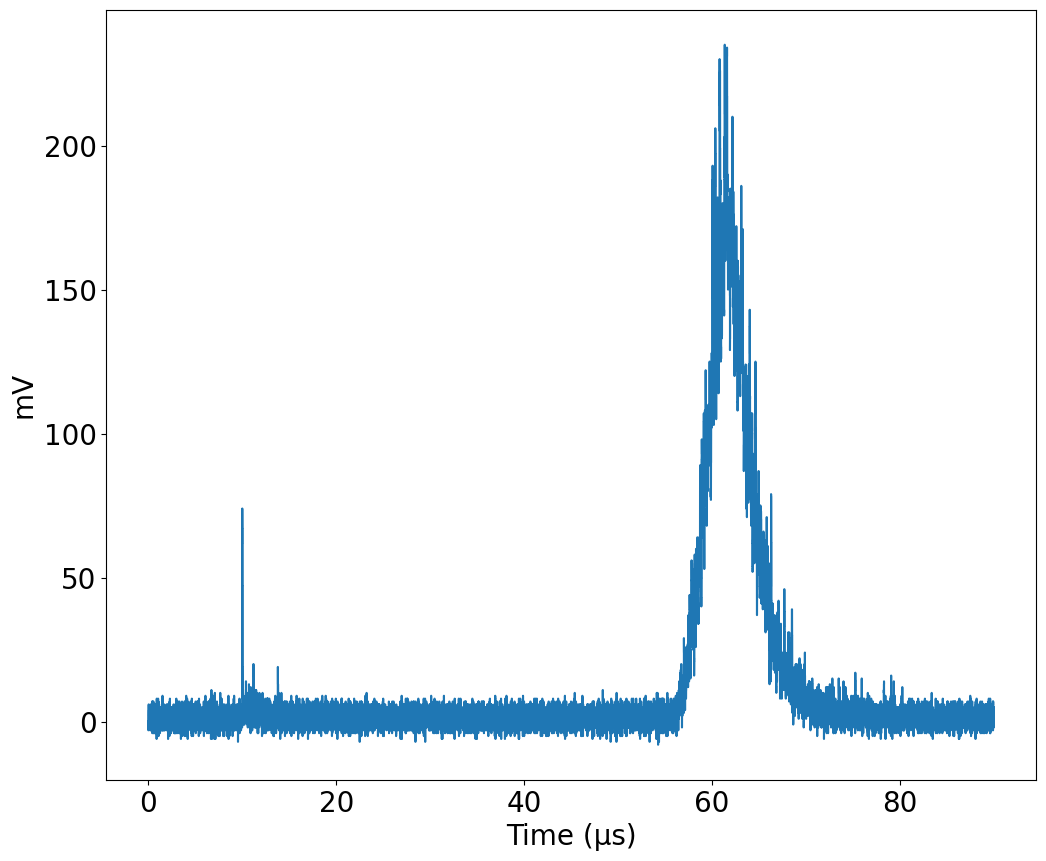

In [25]:


wf_file = '/Users/ldonneger/Desktop/PhD_Thesis2/GapData/R1688/raw/Run_1688_file_0_raw.h5'

with tb.open_file(wf_file, 'r') as h5in:
    wvfs       =  h5in.root.RD.pmtrwf[16] # Gets all pmt waveforms for the second event in the file
    pmt_rwf    = -wvfs.sum(axis=0)       # Sums and inverts the signal of all PMTs
    t = np.linspace(0, len(pmt_rwf)*8/1000, len(pmt_rwf))
    plt.plot(t, pmt_rwf, drawstyle='steps', lw=1.5, zorder=0)
    plt.xlabel('Time (µs)')
    plt.ylabel('mV')

